In [90]:
import sys
import ast
import os
# sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('/bigdata/saleslab/psadh003/tng50/dwarf_formation'))

import pandas as pd 
import matplotlib.pyplot as plt
import IPython
import numpy as np 
# from Pradyumna_plot import plot_tng_subhalos #This is to plot the subhalos from TNG
import matplotlib
import illustris_python as il
from populating_stars import *
from subhalo_profiles import NFWProfile
from colossus.cosmology import cosmology
from colossus.halo import concentration
from plot_sachi import plot_sachi
from scipy.optimize import fsolve
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.collections as mc
from matplotlib.legend_handler import HandlerTuple
import matplotlib.ticker as ticker
from errani_plus_tng_subhalo import Subhalo
import re


In [91]:
cosmology.setCosmology('planck18')

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size' : 14}

plt.figure()
plt.close()
matplotlib.rc('font', **font)

In [92]:
label_font = 20

In [93]:
import illustris_python as il

def convert_to_float(value):
    try:
        if isinstance(value, float) or isinstance(value, int):
            return value

        if value == '[inf, inf, inf]' or value == '[inf inf inf]':
            return np.array([np.inf, np.inf, np.inf])

        if value == '[inf]':
            return np.inf

        if value == '[-inf]':
            return -np.inf

        

        blah = ast.literal_eval(value)
        if isinstance(blah, list):
            if len(blah) == 1:
                blah2 = float(blah[0])   
            elif len(blah) == 3:
                blah2 = np.array([float(blah[0]), float(blah[1]), float(blah[2])])
        else:
            blah2 = float(blah)        
        return blah2
    except Exception as e:
        try:
            value_fixed = re.sub(r'(?<=\d)\s+(?=-?\d)', ', ', value)  # Handle spaces between numbers
            value_fixed = re.sub(r'(?<=\d)\s+(?=\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=-\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=\d)', ', ', value_fixed)
            # Now use ast.literal_eval
            # print(value_fixed)
            result = ast.literal_eval(value_fixed)
            return result
        except Exception as e:
            print(value)
            return value
    # except ValueError:
    #     return value


def get_med_values(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.median(np.reshape(arr, (cuts, -1)), axis = 0)

def get_quantiles(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.quantile(np.reshape(arr, (cuts, -1)), axis = 0, q = [0.05, 0.95])


basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'
outpath  = '/rhome/psadh003/bigdata/tng50/output_files/'
plotpath = '/bigdata/saleslab/psadh003/tng50/output_plots/'
misc_path = '/bigdata/saleslab/psadh003/misc_files/'
ferrarese_data_path = '/bigdata/saleslab/psadh003/misc_files/Ferrarese_virgo_smf.csv'
venhola_data_path = '/bigdata/saleslab/psadh003/misc_files/Venhola_fornax_smf.csv'

'''
This part is to plot the NGVS data of virgo core set of satellites
'''
fdata = pd.read_csv(ferrarese_data_path, delimiter = ',')
fmstar = fdata['mstar']
fngal = fdata['ngal']
fngal_cum = np.cumsum(fngal)

'''
This part is to plot the Fornax mass function (everything inside virial radius)
'''
vdata = pd.read_csv(venhola_data_path, delimiter = ',')
vmstar = vdata['mstar']
vngal = vdata['ngal']
vngal_cum = np.cumsum(vngal)



fof_no = 210
fof_str = 'fof210'

this_fof0 = il.groupcat.loadSingle(basePath, 99, haloID = 0)
central_sfid_99_0 = this_fof0['GroupFirstSub']
rvir_fof0 = this_fof0['Group_R_Crit200']/0.6744
mvir_fof0 = this_fof0['Group_M_Crit200']*1e10/0.6744

this_fof1 = il.groupcat.loadSingle(basePath, 99, haloID = 1)
central_sfid_99_1 = this_fof1['GroupFirstSub']
rvir_fof1 = this_fof1['Group_R_Crit200']/0.6744
mvir_fof1 = this_fof1['Group_M_Crit200']*1e10/0.6744

this_fof2 = il.groupcat.loadSingle(basePath, 99, haloID = 2)
central_sfid_99_2 = this_fof2['GroupFirstSub']
rvir_fof2 = this_fof2['Group_R_Crit200']/0.6744
mvir_fof2 = this_fof2['Group_M_Crit200']*1e10/0.6744

this_fof_plotppath = '/bigdata/saleslab/psadh003/tng50/final_plots/' + fof_str + '/'
if not os.path.exists(this_fof_plotppath): #If the directory does not exist, then just create it!
    os.makedirs(this_fof_plotppath)



'''
In the following lines, 
(i) ps stands for power law values of surviving subhalos
(ii) pm stands for power law values of merged subhalos
(iii) cs stands for cutoff values of surviving subhalos
(iv) cm stands for cutoff values of merged subhalos
'''

mcutoff = 1e2


if True: #This is a section for getting power law values of survived subhalos
    pdfs = pd.read_csv(outpath + fof_str + '_surviving_evolved_everything.csv', delimiter = ',', low_memory=False)
    pdfs = pdfs.applymap(convert_to_float)


    # subset1 = pdfs[(pdfs['dist_f_ar']<rvir_fof0) & (pdfs['fof'] == 0)]
    # subset2 = pdfs[(pdfs['dist_f_ar']<rvir_fof1) & (pdfs['fof'] == 1)]
    # subset3 = pdfs[(pdfs['dist_f_ar']<rvir_fof2) & (pdfs['fof'] == 2)]

    # pdfs = pd.concat([subset1, subset2, subset3], axis=0)
    pdfs1 = pdfs
    # if porc == 'p':
        # print(len(pdfs[pdfs['mstar_f_ar_tng'].values>5e6]))
    columns_to_max = ['mstar_max_ar', 'mstar_max_pl_ar']
    max_values = pdfs[columns_to_max].max(axis=1)
    pdfs = pdfs[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar_tng', 'mstar_f_pl_ar']
    max_values = pdfs[columns_to_max].max(axis=1)
    cutoff = 10

    pdfs = pdfs[(max_values > cutoff)]
    # pdfs = pdfs[pdfs[]]


    psdist_f_ar = pdfs['dist_f_ar'].values
    pspos_f_ar = np.stack(np.array(pdfs['pos_f_ar'].values))
    psvel_f_ar = np.stack(np.array(pdfs['vel_f_ar'].values))

    psspeed_f = np.linalg.norm(psvel_f_ar, axis = 1)
    psvel_f_r = np.einsum('ij, ij->i', pspos_f_ar, psvel_f_ar)*(1/np.linalg.norm(pspos_f_ar, axis = 1)) # This is the radial component
    psvel_f_t = np.sqrt(psspeed_f**2 - psvel_f_r**2)
    psbeta_f_ar = 1 - (psvel_f_t**2/ (2 * psvel_f_r**2))

    pspos_if_ar = np.stack(np.array(pdfs['pos_if_ar'].values))
    psdist_if_ar = np.linalg.norm(pspos_if_ar, axis = 1)
    psvel_if_ar = np.stack(np.array(pdfs['vel_if_ar'].values))
    # print(pspos_f_ar)
    # print(pspos_f_ar.shape)
    psxydist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, :2]), axis = 1))
    psyzdist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, 1:]), axis = 1))
    psxzdist_f_ar = np.sqrt(np.sum(np.square(pspos_f_ar[:, [0, 2]]), axis = 1))


    psvd_f_ar_tng = pdfs['vd_f_ar_tng'].values
    psrh_f_ar_tng = pdfs['rh_f_ar_tng'].values
    psmstar_f_ar_tng = pdfs['mstar_f_ar_tng'].values
    psmmx_f_ar_tng = pdfs['mmx_f_ar_tng'].values
    psrmx_f_ar_tng = pdfs['rmx_f_ar_tng'].values
    psvmx_f_ar_tng = pdfs['vmx_f_ar_tng'].values

    pstinf_ar = pdfs['tinf_ar'].values
    pstorb_ar = pdfs['torb_ar'].values
    psrapo_ar = pdfs['rapo_ar'].values
    psrperi_ar = pdfs['rperi_ar'].values

    psvd_f_ar = pdfs['vd_f_ar'].values
    psrh_f_ar = pdfs['rh_f_ar'].values
    psmstar_f_ar = pdfs['mstar_f_ar'].values

    psvd_max_ar = pdfs['vd_max_ar'].values
    psrh_max_ar = pdfs['rh_max_ar'].values
    psmstar_max_ar = pdfs['mstar_max_ar'].values

    pssnap_if_ar = pdfs['snap_if_ar'].values
    pssf_id_if_ar = pdfs['sfid_if_ar'].values

    psmmx_f_ar = pdfs['mmx_f_ar'].values
    psrmx_f_ar = pdfs['rmx_f_ar'].values
    psvmx_f_ar = pdfs['vmx_f_ar'].values

    psmmx_if_ar = pdfs['mmx_if_ar'].values
    psrmx_if_ar = pdfs['rmx_if_ar'].values
    psvmx_if_ar = pdfs['vmx_if_ar'].values

    psvd_f_pl_ar = pdfs['vd_f_pl_ar'].values
    psrh_f_pl_ar = pdfs['rh_f_pl_ar'].values
    psmstar_f_pl_ar = pdfs['mstar_f_pl_ar'].values
    psvd_f_co_ar = pdfs['vd_f_co_ar'].values
    psrh_f_co_ar = pdfs['rh_f_co_ar'].values
    psmstar_f_co_ar = pdfs['mstar_f_co_ar'].values
    psrh_max_pl_ar = pdfs['rh_max_pl_ar'].values
    psrh_max_co_ar = pdfs['rh_max_co_ar'].values
    psmstar_max_pl_ar = pdfs['mstar_max_pl_ar'].values
    psmstar_max_co_ar = pdfs['mstar_max_co_ar'].values
    psfof = pdfs['fof'].values
    psmstar_if_ar = pdfs['mstar_if_ar'].values
    psvmax_if_ar = pdfs['vmax_if_ar'].values
    
    psmbp_pos_f_ar = pdfs['mbp_pos_f_ar'].values
    psmbp_vel_f_ar = pdfs['mbp_vel_f_ar'].values
    psmbp_dist_f_ar = pdfs['mbp_dist_f_ar'].values



    psgr_sat = pdfs['grp_status'].values

    pspot_f_ar = pdfs['pot_f_ar'].values
    pspot_if_ar = pdfs['pot_if_ar'].values
    psmpeak_ar = pdfs['mpeak_ar'].values
    psmdm_f_ar = pdfs['mdm_f_ar'].values

    pstcross = pdfs['t_cross'].values 
    pssnap_cross =  pdfs['snap_cross'].values 
    pssfid_cross = pdfs['sfid_cross'].values 
    pspos_cross = np.stack(np.array(pdfs['pos_cross'].values)) 
    pspot_cross_ar = pdfs['pot_cross'].values 
    psvel_cross = np.stack(np.array(pdfs['vel_cross'].values)) 
    psspeed_cross = np.linalg.norm(psvel_cross, axis = 1)
    psvel_cross_r = np.einsum('ij, ij->i', pspos_cross, psvel_cross)*(1/np.linalg.norm(pspos_cross, axis = 1)) # This is the radial component
    psvel_cross_t = np.sqrt(psspeed_cross**2 - psvel_cross_r**2)
    psbeta_ar = 1 - (psvel_cross_t**2/ (2 * psvel_cross_r**2))

    

    psmstar_all = np.zeros(len(psmmx_f_ar))
    psrh_all = np.zeros(len(psmmx_f_ar))
    psvd_all = np.zeros(len(psmmx_f_ar))
    res_ixs = np.where(psmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(psmstar_max_ar < 5e6)[0] #These are the unresolved indices

    psmstar_max_all = np.zeros(len(psmmx_f_ar))
    psrh_max_all = np.zeros(len(psmmx_f_ar))

    psmstar_max_all[res_ixs] = psmstar_max_ar[res_ixs]
    psmstar_max_all[unres_ixs] = psmstar_max_pl_ar[unres_ixs]

    psrh_max_all[res_ixs] = psrh_max_ar[res_ixs]
    psrh_max_all[unres_ixs] = psrh_max_pl_ar[unres_ixs]

    psmstar_all[res_ixs] = psmstar_f_ar[res_ixs]
    psmstar_all[unres_ixs] = psmstar_f_pl_ar[unres_ixs]
    psrh_all[res_ixs] = psrh_f_ar[res_ixs]
    psrh_all[unres_ixs] = psrh_f_pl_ar[unres_ixs]
    psvd_all[res_ixs] = psvd_f_ar[res_ixs]
    psvd_all[unres_ixs] = psvd_f_pl_ar[unres_ixs]


    pssigma_all = 4.83 +21.57 -2.5 * np.log10(psmstar_all / (np.pi * (psrh_all*1e3) ** 2)) #This will be in mag/arcsec^2





if True: #This is a section for getting power law values of merged subhalos
    pdfm = pd.read_csv(outpath + fof_str + '_merged_evolved_wmbp_everything.csv', delimiter = ',')
    # print(pdfm.head(20))
    # print(f'Length before is: {len(pdfm)}')
    # pdfm = pdfm[pdfm['dist_f_ar'] != '']
    # print(f'Length after is: {len(pdfm)}')

    # pdfm = pdfm.dropna(subset = ['dist_f_ar'])
    # print(pdfm['pos_f_ar'])
    pdfm = pdfm.applymap(convert_to_float)
    # pdfm = pdfm[pdfm['dist_f_ar']<rvir_fof]

    # subset1 = pdfm[(pdfm['dist_f_ar']<rvir_fof0) & (pdfm['fof'] == 0)]
    # subset2 = pdfm[(pdfm['dist_f_ar']<rvir_fof1) & (pdfm['fof'] == 1)]
    # subset3 = pdfm[(pdfm['dist_f_ar']<rvir_fof2) & (pdfm['fof'] == 2)]

    # pdfm = pd.concat([subset1, subset2, subset3], axis=0)
    pdfm1 = pdfm 

    columns_to_max = ['mstar_max_ar', 'mstar_max_pl_ar']
    max_values = pdfm[columns_to_max].max(axis=1)
    pdfm = pdfm[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar', 'mstar_f_pl_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = pdfm[columns_to_max].max(axis=1)

    # Sample cutoff value
    cutoff = 10

    # print(len(pdfm))
    pdfm = pdfm[max_values > cutoff]
    # print(len(pdfm))

    pmdist_f_ar_fofonly = pdfm['dist_f_ar'].values
    pmpos_list_fofonly = pdfm['pos_f_ar'].values
    pmvel_list_fofonly = pdfm['vel_f_ar'].values


    for idx, arr in enumerate(pmpos_list_fofonly):
        if np.array(arr).size != 3:  # Check if the array is empty
            pmpos_list_fofonly[idx] = [np.inf, np.inf, np.inf]
            pmvel_list_fofonly[idx] = [np.inf, np.inf, np.inf]
            pmdist_f_ar_fofonly[idx] = np.inf
    pmpos_ar = np.stack(np.array(pmpos_list_fofonly))
    pmvel_f_ar = np.stack(np.array(pmvel_list_fofonly))

    # Following are the distances which have been taken from the FoF particle data which is within 3 rvir
    #  ===================================================================
    # pos_f_ar_3rvir	dist_f_ar_3rvir	vel_f_ar_3rvir

    pmdist_f_ar = pdfm['dist_f_ar_3rvir'].values
    pmpos_list = pdfm['pos_f_ar_3rvir'].values
    pmvel_list = pdfm['vel_f_ar_3rvir'].values

    for idx, arr in enumerate(pmpos_list):
        if np.array(arr).size != 3:  # Check if the array is empty
            pmpos_list[idx] = [np.inf, np.inf, np.inf]
            pmvel_list[idx] = [np.inf, np.inf, np.inf]
            pmdist_f_ar[idx] = np.inf
    pmpos_ar = np.stack(np.array(pmpos_list))
    pmvel_f_ar = np.stack(np.array(pmvel_list))

    #  ===================================================================


    pmpos_if_ar = np.stack(np.array(pdfm['pos_if_ar'].values))
    pmdist_if_ar = np.linalg.norm(pmpos_if_ar, axis = 1)
    pmvel_if_ar = np.stack(np.array(pdfm['vel_if_ar'].values))
    # pmpos_ar
    # print(pmpos_ar)
    pmxydist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, :2]), axis = 1))
    pmyzdist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, 1:]), axis = 1))
    pmxzdist_f_ar = np.sqrt(np.sum(np.square(pmpos_ar[:, [0, 2]]), axis = 1))
    pmmbpid_ar = pdfm['mbpid_ar'].values

    pmtinf_ar = pdfm['tinf_ar'].values
    pmtorb_ar = pdfm['torb_ar'].values
    pmrapo_ar = pdfm['rapo_ar'].values
    pmrperi_ar = pdfm['rperi_ar'].values

    pmvd_f_ar = pdfm['vd_f_ar'].values
    pmrh_f_ar = pdfm['rh_f_ar'].values
    pmmstar_f_ar = pdfm['mstar_f_ar'].values

    pmvd_max_ar = pdfm['vd_max_ar'].values
    pmrh_max_ar = pdfm['rh_max_ar'].values
    pmmstar_max_ar = pdfm['mstar_max_ar'].values

    pmsnap_if_ar = pdfm['snap_if_ar'].values
    pmsfid_if_ar = pdfm['sfid_if_ar'].values

    pmmmx_f_ar = pdfm['mmx_f_ar'].values
    pmrmx_f_ar = pdfm['rmx_f_ar'].values
    pmvmx_f_ar = pdfm['vmx_f_ar'].values

    pmmmx_if_ar = pdfm['mmx_if_ar'].values
    pmrmx_if_ar = pdfm['rmx_if_ar'].values
    pmvmx_if_ar = pdfm['vmx_if_ar'].values

    pmvd_f_pl_ar = pdfm['vd_f_pl_ar'].values
    pmrh_f_pl_ar = pdfm['rh_f_pl_ar'].values
    pmmstar_f_pl_ar = pdfm['mstar_f_pl_ar'].values
    pmvd_f_co_ar = pdfm['vd_f_co_ar'].values
    pmrh_f_co_ar = pdfm['rh_f_co_ar'].values
    pmmstar_f_co_ar = pdfm['mstar_f_co_ar'].values
    pmrh_max_pl_ar = pdfm['rh_max_pl_ar'].values
    pmrh_max_co_ar = pdfm['rh_max_co_ar'].values
    pmmstar_max_pl_ar = pdfm['mstar_max_pl_ar'].values
    pmmstar_max_co_ar = pdfm['mstar_max_co_ar'].values
    pmpot_f_ar = pdfm['pot_f_ar'].values
    pmpot_if_ar = pdfm['pot_if_ar'].values
    pmmpeak_ar = pdfm['mpeak_ar'].values
    pmvpeak_ar = pdfm['vpeak_ar'].values


    
    pmfof = pdfm['fof'].values

    pmgp_pos_f_ar = pdfm['gp_pos_f_ar'].values
    pmgp_vel_f_ar = pdfm['gp_vel_f_ar'].values
    pmgp_dist_f_ar = pdfm['gp_dist_f_ar'].values

    pmgr_sat = pdfm['grp_status'].values
    

    pmmstar_max_all = np.zeros(len(pmmmx_f_ar))
    pmrh_max_all = np.zeros(len(pmmmx_f_ar))

    pmmstar_all = np.zeros(len(pmmmx_f_ar))
    pmrh_all = np.zeros(len(pmmmx_f_ar))
    pmvd_all = np.zeros(len(pmmmx_f_ar))
    res_ixs = np.where(pmmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(pmmstar_max_ar < 5e6)[0] #These are the unresolved indices
    pmmstar_all[res_ixs] = pmmstar_f_ar[res_ixs]
    pmmstar_all[unres_ixs] = pmmstar_f_pl_ar[unres_ixs]

    pmmstar_max_all[res_ixs] = pmmstar_max_ar[res_ixs]
    pmmstar_max_all[unres_ixs] = pmmstar_max_pl_ar[unres_ixs]


    pmrh_max_all[res_ixs] = pmrh_max_ar[res_ixs]
    pmrh_max_all[unres_ixs] = pmrh_max_pl_ar[unres_ixs]



    pmrh_all[res_ixs] = pmrh_f_ar[res_ixs]
    pmrh_all[unres_ixs] = pmrh_f_pl_ar[unres_ixs]
    pmvd_all[res_ixs] = pmvd_f_ar[res_ixs]
    pmvd_all[unres_ixs] = pmvd_f_pl_ar[unres_ixs]

    pmsigma_all = 4.83 +21.57 -2.5 * np.log10(pmmstar_all / (np.pi * (pmrh_all*1e3) ** 2)) #This will be in mag/arcsec^2


#Once we have the power law data for surviving and merged subhalos, we should obtain their respective stellar masses etc checking if they are resolved




if True: #This is a section for getting cutoff values of survived subhalos
    cdfs = pd.read_csv(outpath + fof_str + '_surviving_evolved_everything.csv', delimiter = ',', low_memory=False)
    cdfs = cdfs.applymap(convert_to_float)


    # cdfs = cdfs[cdfs['dist_f_ar']<rvir_fof]
    # subset1 = cdfs[(cdfs['dist_f_ar']<rvir_fof0) & (cdfs['fof'] == 0)]
    # subset2 = cdfs[(cdfs['dist_f_ar']<rvir_fof1) & (cdfs['fof'] == 1)]
    # subset3 = cdfs[(cdfs['dist_f_ar']<rvir_fof2) & (cdfs['fof'] == 2)]

    # cdfs = pd.concat([subset1, subset2, subset3], axis=0)
    cdfs1 = cdfs

    # elif porc == 'c':
    columns_to_max = ['mstar_max_ar', 'mstar_max_co_ar']
    max_values = cdfs[columns_to_max].max(axis=1)
    cdfs = cdfs[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar_tng', 'mstar_f_co_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = cdfs[columns_to_max].max(axis=1)

    cutoff = 10
    # print(max_values > cutoff)

    cdfs = cdfs[(max_values > cutoff)]

    csdist_f_ar = cdfs['dist_f_ar'].values
    cspos_f_ar = np.stack(np.array(cdfs['pos_f_ar'].values))
    csvel_f_ar = np.stack(np.array(cdfs['vel_f_ar'].values))

    csxydist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, :2]), axis = 1))
    csyzdist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, 1:]), axis = 1))
    csxzdist_f_ar = np.sqrt(np.sum(np.square(cspos_f_ar[:, [0, 2]]), axis = 1))

    csvd_f_ar_tng = cdfs['vd_f_ar_tng'].values
    csrh_f_ar_tng = cdfs['rh_f_ar_tng'].values
    csmstar_f_ar_tng = cdfs['mstar_f_ar_tng'].values
    csmmx_f_ar_tng = cdfs['mmx_f_ar_tng'].values
    csrmx_f_ar_tng = cdfs['rmx_f_ar_tng'].values
    csvmx_f_ar_tng = cdfs['vmx_f_ar_tng'].values

    cstinf_ar = cdfs['tinf_ar'].values
    cstorb_ar = cdfs['torb_ar'].values
    csrapo_ar = cdfs['rapo_ar'].values
    csrperi_ar = cdfs['rperi_ar'].values

    csvd_f_ar = cdfs['vd_f_ar'].values
    csrh_f_ar = cdfs['rh_f_ar'].values
    csmstar_f_ar = cdfs['mstar_f_ar'].values

    csvd_max_ar = cdfs['vd_max_ar'].values
    csrh_max_ar = cdfs['rh_max_ar'].values
    csmstar_max_ar = cdfs['mstar_max_ar'].values

    cssnap_if_ar = cdfs['snap_if_ar'].values
    cssf_id_if_ar = cdfs['sfid_if_ar'].values

    csmmx_f_ar = cdfs['mmx_f_ar'].values
    csrmx_f_ar = cdfs['rmx_f_ar'].values
    csvmx_f_ar = cdfs['vmx_f_ar'].values

    csmmx_if_ar = cdfs['mmx_if_ar'].values
    csrmx_if_ar = cdfs['rmx_if_ar'].values
    csvmx_if_ar = cdfs['vmx_if_ar'].values

    csvd_f_pl_ar = cdfs['vd_f_pl_ar'].values
    csrh_f_pl_ar = cdfs['rh_f_pl_ar'].values
    csmstar_f_pl_ar = cdfs['mstar_f_pl_ar'].values
    csvd_f_co_ar = cdfs['vd_f_co_ar'].values
    csrh_f_co_ar = cdfs['rh_f_co_ar'].values
    csmstar_f_co_ar = cdfs['mstar_f_co_ar'].values
    csrh_max_pl_ar = cdfs['rh_max_pl_ar'].values
    csrh_max_co_ar = cdfs['rh_max_co_ar'].values
    csmstar_max_pl_ar = cdfs['mstar_max_pl_ar'].values
    csmstar_max_co_ar = cdfs['mstar_max_co_ar'].values
    csfof = cdfs['fof'].values

    csmbp_pos_f_ar = cdfs['mbp_pos_f_ar'].values
    csmbp_vel_f_ar = cdfs['mbp_vel_f_ar'].values
    csmbp_dist_f_ar = cdfs['mbp_dist_f_ar'].values

    csmstar_all = np.zeros(len(csmmx_f_ar))
    csrh_all = np.zeros(len(csmmx_f_ar))
    csvd_all = np.zeros(len(csmmx_f_ar))
    res_ixs = np.where(csmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(csmstar_max_ar < 5e6)[0] #These are the unresolved indices

    csmstar_max_all = np.zeros(len(csmmx_f_ar))
    csrh_max_all = np.zeros(len(csmmx_f_ar))

    csmstar_max_all[res_ixs] = csmstar_max_ar[res_ixs]
    csmstar_max_all[unres_ixs] = csmstar_max_co_ar[unres_ixs]

    csrh_max_all[res_ixs] = csrh_max_ar[res_ixs]
    csrh_max_all[unres_ixs] = csrh_max_co_ar[unres_ixs]

    csmstar_all[res_ixs] = csmstar_f_ar[res_ixs]
    csmstar_all[unres_ixs] = csmstar_f_co_ar[unres_ixs]
    csrh_all[res_ixs] = csrh_f_ar[res_ixs]
    csrh_all[unres_ixs] = csrh_f_co_ar[unres_ixs]
    csvd_all[res_ixs] = csvd_f_ar[res_ixs]
    csvd_all[unres_ixs] = csvd_f_co_ar[unres_ixs]

    cssigma_all = 4.83 +21.57 -2.5 * np.log10(csmstar_all / (np.pi * (csrh_all*1e3) ** 2)) #This will be in mag/arcsec^2


if True: #This is a section for getting cutoff values of merged subhalos
    cdfm = pd.read_csv(outpath + fof_str + '_merged_evolved_wmbp_everything.csv', delimiter = ',')
    # cdfm = cdfm.dropna(subset = ['dist_f_ar'])
    cdfm = cdfm.applymap(convert_to_float)


    # cdfm = cdfm[cdfm['dist_f_ar']<rvir_fof]
    
    # subset1 = cdfm[(cdfm['dist_f_ar']<rvir_fof0) & (cdfm['fof'] == 0)]
    # subset2 = cdfm[(cdfm['dist_f_ar']<rvir_fof1) & (cdfm['fof'] == 1)]
    # subset3 = cdfm[(cdfm['dist_f_ar']<rvir_fof2) & (cdfm['fof'] == 2)]

    # cdfm = pd.concat([subset1, subset2, subset3], axis=0)

    cdfm1 = cdfm 

    columns_to_max = ['mstar_max_ar', 'mstar_max_co_ar']
    max_values = cdfm[columns_to_max].max(axis=1)
    cdfm = cdfm[(max_values > mcutoff)]

    columns_to_max = ['mstar_f_ar', 'mstar_f_co_ar']

    # Compute the maximum along the specified axis (axis=1 for row-wise)
    max_values = cdfm[columns_to_max].max(axis=1)

    # Sample cutoff value
    cutoff = 10
    cdfm = cdfm[max_values > cutoff]
    # print(len(cdfm))


    # cmdist_f_ar = cdfm['dist_f_ar'].values
    # cmpos_ar = np.stack(np.array(cdfm['pos_f_ar'].values))
    # cmvel_f_ar = np.stack(np.array(cdfm['vel_f_ar'].values))

    cmdist_f_ar_fofonly = cdfm['dist_f_ar'].values
    cmpos_list_fofonly = cdfm['pos_f_ar'].values
    cmvel_list_fofonly = cdfm['vel_f_ar'].values
    
    for idx, arr in enumerate(cmpos_list_fofonly):
        if np.array(arr).size != 3:  # Check if the array is empty
            cmpos_list_fofonly[idx] = [np.inf, np.inf, np.inf]
            cmvel_list_fofonly[idx] = [np.inf, np.inf, np.inf]
            cmdist_f_ar_fofonly[idx] = np.inf
    cmpos_ar = np.stack(np.array(cmpos_list_fofonly))
    cmvel_f_ar = np.stack(np.array(cmvel_list_fofonly))



    cmdist_f_ar = cdfm['dist_f_ar_3rvir'].values
    cmpos_list = cdfm['pos_f_ar_3rvir'].values
    cmvel_list = cdfm['vel_f_ar_3rvir'].values

    for idx, arr in enumerate(cmpos_list):
        if np.array(arr).size != 3:  # Check if the array is empty
            cmpos_list[idx] = [np.inf, np.inf, np.inf]
            cmvel_list[idx] = [np.inf, np.inf, np.inf]
            cmdist_f_ar[idx] = np.inf
    cmpos_ar = np.stack(np.array(cmpos_list))
    cmvel_f_ar = np.stack(np.array(cmvel_list))



    cmxydist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, :2]), axis = 1))
    cmyzdist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, 1:]), axis = 1))
    cmxzdist_f_ar = np.sqrt(np.sum(np.square(cmpos_ar[:, [0, 2]]), axis = 1))


    cmmbpid_ar = cdfm['mbpid_ar'].values

    cmtinf_ar = cdfm['tinf_ar'].values
    cmtorb_ar = cdfm['torb_ar'].values
    cmrapo_ar = cdfm['rapo_ar'].values
    cmrperi_ar = cdfm['rperi_ar'].values

    cmvd_f_ar = cdfm['vd_f_ar'].values
    cmrh_f_ar = cdfm['rh_f_ar'].values
    cmmstar_f_ar = cdfm['mstar_f_ar'].values

    cmvd_max_ar = cdfm['vd_max_ar'].values
    cmrh_max_ar = cdfm['rh_max_ar'].values
    cmmstar_max_ar = cdfm['mstar_max_ar'].values

    cmsnap_if_ar = cdfm['snap_if_ar'].values
    cmsfid_if_ar = cdfm['sfid_if_ar'].values

    cmmmx_f_ar = cdfm['mmx_f_ar'].values
    cmrmx_f_ar = cdfm['rmx_f_ar'].values
    cmvmx_f_ar = cdfm['vmx_f_ar'].values

    cmmmx_if_ar = cdfm['mmx_if_ar'].values
    cmrmx_if_ar = cdfm['rmx_if_ar'].values
    cmvmx_if_ar = cdfm['vmx_if_ar'].values

    cmvd_f_pl_ar = cdfm['vd_f_pl_ar'].values
    cmrh_f_pl_ar = cdfm['rh_f_pl_ar'].values
    cmmstar_f_pl_ar = cdfm['mstar_f_pl_ar'].values
    cmvd_f_co_ar = cdfm['vd_f_co_ar'].values
    cmrh_f_co_ar = cdfm['rh_f_co_ar'].values
    cmmstar_f_co_ar = cdfm['mstar_f_co_ar'].values
    cmrh_max_pl_ar = cdfm['rh_max_pl_ar'].values
    cmrh_max_co_ar = cdfm['rh_max_co_ar'].values
    cmmstar_max_pl_ar = cdfm['mstar_max_pl_ar'].values
    cmmstar_max_co_ar = cdfm['mstar_max_co_ar'].values
    cmfof = cdfm['fof'].values
    cmvpeak_ar = cdfm['vpeak_ar'].values

    cmmstar_max_all = np.zeros(len(cmmmx_f_ar))
    cmrh_max_all = np.zeros(len(cmmmx_f_ar))

    cmmstar_all = np.zeros(len(cmmmx_f_ar))
    cmrh_all = np.zeros(len(cmmmx_f_ar))
    cmvd_all = np.zeros(len(cmmmx_f_ar))
    res_ixs = np.where(cmmstar_max_ar >= 5e6)[0] #These are the resolved indices
    unres_ixs = np.where(cmmstar_max_ar < 5e6)[0] #These are the unresolved indices
    cmmstar_all[res_ixs] = cmmstar_f_ar[res_ixs]
    cmmstar_all[unres_ixs] = cmmstar_f_co_ar[unres_ixs]

    cmmstar_max_all[res_ixs] = cmmstar_max_ar[res_ixs]
    cmmstar_max_all[unres_ixs] = cmmstar_max_co_ar[unres_ixs]

    cmrh_max_all[res_ixs] = cmrh_max_ar[res_ixs]
    cmrh_max_all[unres_ixs] = cmrh_max_co_ar[unres_ixs]

    cmrh_all[res_ixs] = cmrh_f_ar[res_ixs]
    cmrh_all[unres_ixs] = cmrh_f_co_ar[unres_ixs]
    cmvd_all[res_ixs] = cmvd_f_ar[res_ixs]
    cmvd_all[unres_ixs] = cmvd_f_co_ar[unres_ixs]

    
    cmsigma_all = 4.83 +21.57 -2.5 * np.log10(cmmstar_all / (np.pi * (cmrh_all*1e3) ** 2)) #This will be in mag/arcsec^2



/tmp/ipykernel_3207213/3507731804.py:256: RuntimeWarning: invalid value encountered in divide
  pssigma_all = 4.83 +21.57 -2.5 * np.log10(psmstar_all / (np.pi * (psrh_all*1e3) ** 2)) #This will be in mag/arcsec^2

/tmp/ipykernel_3207213/3507731804.py:527: RuntimeWarning: invalid value encountered in divide
  cssigma_all = 4.83 +21.57 -2.5 * np.log10(csmstar_all / (np.pi * (csrh_all*1e3) ** 2)) #This will be in mag/arcsec^2



In [94]:
# This cell is to import the data for TNG50-1-Dark Type1

t50dbasePath = '/rhome/psadh003/bigdata/TNG50-1-Dark/output'
t50dfilepath = '/rhome/psadh003/bigdata/tng50dark/tng_files/'

t5ddf = pd.read_csv(t50dfilepath + 'master_tng50d.csv')
t5ddf = t5ddf.applymap(convert_to_float)

# Let us print the headers of the dataframe
print(t5ddf.head())

posxd5_ar = t5ddf['posx_ar'].values
posyd5_ar = t5ddf['posy_ar'].values
poszd5_ar = t5ddf['posz_ar'].values

posd5_ar = np.stack((posxd5_ar, posyd5_ar, poszd5_ar), axis = 1)

velxd5_ar = t5ddf['velx_ar'].values
velyd5_ar = t5ddf['vely_ar'].values
velzd5_ar = t5ddf['velz_ar'].values

veld5_ar = np.stack((velxd5_ar, velyd5_ar, velzd5_ar), axis = 1)

veld5_f_r = np.einsum('ij, ij->i', posd5_ar, veld5_ar)*(1/np.linalg.norm(posd5_ar, axis = 1)) # This is the radial component
veld5_f_t = np.sqrt(np.linalg.norm(veld5_ar, axis = 1)**2 - veld5_f_r**2)

vmaxd5_ar = t5ddf['vmax_ar'].values
lend5_ar = t5ddf['len_ar'].values
fofno5_ar = t5ddf['fof'].values
vmax_ifd5_ar = t5ddf['vmax_if_ar'].values
massd5_ar = t5ddf['mass_ar'].values
mass_ifd5_ar = t5ddf['mdm_if_ar'].values
sfid_ifd5_ar = t5ddf['sfid_if_ar']
snap_ifd5_ar = t5ddf['snap_if_ar']
distd5_ar = np.sqrt((posxd5_ar)**2 + (posyd5_ar )**2 + (poszd5_ar )**2)
vpeakd5_ar = t5ddf['vpeak'].values


       posx_ar      posy_ar      posz_ar       cmx_ar       cmy_ar  \
0  -705.757707  -958.572633  -235.825440  -694.012589  -951.885133   
1  1159.951278  -265.205445  -658.225830  1155.384871  -265.705445   
2   302.629012  1188.083617  -641.817627   302.726668  1188.189086   
3   137.912215  1134.509398   128.578857   138.286239  1135.587523   
4   570.475692  1070.724242  1596.184326   569.896590  1070.896117   

        cmz_ar     vmax_ar       mass_ar     len_ar  sfid_ar  ...  \
0  -237.309815  236.975998  2.482886e+12  4611051.0      1.0  ...   
1  -661.053955  126.394867  4.393200e+11   815876.0      2.0  ...   
2  -642.311768  167.931595  3.719775e+11   690812.0      3.0  ...   
3   127.412842  158.029831  3.357426e+11   623519.0      4.0  ...   
4  1595.680420  154.263214  3.352742e+11   622649.0      5.0  ...   

      mdm_if_ar  inf1_snap_ar  inf1_sfid_ar       vpeak     velx_ar  \
0  3.242556e+12          88.0      610944.0  284.157928  309.980560   
1  5.476692e+11       

In [6]:
# This cell is to import the data for TNG100-1-Dark Type1

t100dbasePath = '/rhome/psadh003/bigdata/TNG100-1-Dark/output'
t100dfilepath = '/rhome/psadh003/bigdata/tng100dark/tng_files/'

t1ddf = pd.read_csv(t100dfilepath + 'master_tng100d.csv')
t1ddf = t1ddf.applymap(convert_to_float)

posxd1_ar = t1ddf['posx_ar'].values
posyd1_ar = t1ddf['posy_ar'].values
poszd1_ar = t1ddf['posz_ar'].values

posd1_ar = np.stack((posxd1_ar, posyd1_ar, poszd1_ar), axis = 1)

velxd1_ar = t1ddf['velx_ar'].values
velyd1_ar = t1ddf['vely_ar'].values
velzd1_ar = t1ddf['velz_ar'].values

veld1_ar = np.stack((velxd1_ar, velyd1_ar, velzd1_ar), axis = 1)

vel_f_r = np.einsum('ij, ij->i', posd1_ar, veld1_ar)*(1/np.linalg.norm(posd1_ar, axis = 1)) # This is the radial component
vel_f_t = np.sqrt(np.linalg.norm(veld1_ar, axis = 1)**2 - vel_f_r**2)

vmaxd1_ar = t1ddf['vmax_ar'].values
lend1_ar = t1ddf['len_ar'].values
fofno1_ar = t1ddf['fof'].values
vmax_ifd1_ar = t1ddf['vmax_if_ar'].values
massd1_ar = t1ddf['mass_ar'].values
sfid_ifd1_ar = t1ddf['sfid_if_ar']
snap_ifd1_ar = t1ddf['snap_if_ar']
distd1_ar = np.sqrt((posxd1_ar)**2 + (posyd1_ar )**2 + (poszd1_ar )**2)


In [7]:
# This cell is to import the data of the Ludlow

dm_dist_ldf = pd.read_csv(misc_path + 'dm_dist_ludlow.csv', header = None)
dm_einasto_ldf = pd.read_csv(misc_path + 'dm_einasto_ludlow.csv', header = None)
m1_ldf = pd.read_csv(misc_path + 'm1_ludlow.csv', header = None)
m2_ldf = pd.read_csv(misc_path + 'm2_ludlow.csv', header = None)
m3_ldf = pd.read_csv(misc_path + 'm3_ludlow.csv', header = None)
m4_ldf = pd.read_csv(misc_path + 'm4_ludlow.csv', header = None)
m5_ldf = pd.read_csv(misc_path + 'm5_ludlow.csv', header = None)

v1_ldf = pd.read_csv(misc_path + 'v1_ludlow.csv', header = None)
v2_ldf = pd.read_csv(misc_path + 'v2_ludlow.csv', header = None)
v3_ldf = pd.read_csv(misc_path + 'v3_ludlow.csv', header = None)
v4_ldf = pd.read_csv(misc_path + 'v4_ludlow.csv', header = None)
v5_ldf = pd.read_csv(misc_path + 'v5_ludlow.csv', header = None)

h = 0.6774
G = 4.3e-6

In [86]:
from scipy.optimize import curve_fit

def einasto_density(lr, lrhos, lrs, lalpha):
    '''
    This gives the Einasto density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    r = 10**lr
    rhos = 10**lrhos
    rs = lrs
    alpha = lalpha
    dens = rhos * np.exp((-2/alpha) * ((r/rs) ** alpha - 1))
    return np.log10(dens)


def fit_einasto(r, density):
    """
    Fit the Einasto profile to the given density data.

    Parameters
    ----------
    r : array-like
        Radial distances.
    density : array-like
        Observed density values.

    Returns
    -------
    params : tuple
        Best-fit parameters (rho_s, r_s, alpha).
    cov : 2D array
        Covariance matrix of the fit.
    """
    # Initial guesses for parameters (can be adjusted based on data)
    rho_s_guess = density.max()
    r_s_guess = r[np.argmax(density)]
    alpha_guess = 1.5
    
    # print(rho_s_guess, r_s_guess, alpha_guess)
    # p0 = [np.log10(rho_s_guess), np.log10(r_s_guess), alpha_guess]
    p0 = [np.log10(rho_s_guess), 0.1, alpha_guess]
    
    # Perform the curve fitting
    try:
        params, cov = curve_fit(einasto_density, np.log10(r), np.log10(density), p0=p0, bounds=((-1, 0.1, 0.1), (10, 10**-0.23, 2)))
        return params, cov
    except RuntimeError as e:
        print("Fit did not converge:", e)
        return None, None


In [22]:
h = 0.6774 # Hubble constant / 100

def nfw_mass(r, lrhos, lrs):
    '''
    This gives the NFW mass profile at a given radius r, we do not care much about the units here, since we normalize the density profile later
    '''
    rhos = 10**lrhos
    rs = 10**lrs
    mass =  4 * np.pi * rhos * rs ** 3 * (np.log(1 + (r/rs))  -  r / (r + rs))
    return mass


def nfw_dens(r, rhos, rs):
    '''
    This gives the NFW density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    dens = rhos / ((r/rs) * (1 + (r / rs)) ** 2)
    return dens



# Following calculations are for the best-fit NFW profiles


# ================== For the FoF-0 ==================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_0 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_0 = this_fof['Group_R_Crit200'] / h
v200_0 = np.sqrt(G * m200_0 / r200_0)


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_0 = 10**lrhos
rs_0 = 10**lrs

# ======================= For the FoF-1 =======================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 1)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_1 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_1 = this_fof['Group_R_Crit200'] / h
v200_1 = np.sqrt(G * m200_1 / r200_1)


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_1 = 10**lrhos
rs_1 = 10**lrs


# ============== For the FoF-2 =================


this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 2)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_2 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_2 = this_fof['Group_R_Crit200'] / h
v200_2 = np.sqrt(G * m200_2 / r200_2)


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_2 = 10**lrhos
rs_2 = 10**lrs


# We now have the best-fit NFW parameters for the FoF-0, FoF-1 and FoF-2 halos, we can now use these to get the density profiles for the subhalos

0.015336077187700116
0.02351952635070959
0.036069727153262905
0.05531681197617227
0.08483428982440722
0.13010252169108316
0.19952623149688797
0.30599496872071963
0.4692762459348838
0.7196856730011522
1.1037155032027568
1.6926666150378762
2.595886586126396
3.9810717055349722
/tmp/ipykernel_3355332/1311658848.py:60: RuntimeWarning: divide by zero encountered in log10
  d1n1_ar = np.log10(norm_d1Ns2 * d1n1_ar)

/tmp/ipykernel_3355332/1311658848.py:61: RuntimeWarning: divide by zero encountered in log10
  d1n2_ar = np.log10(norm_d1Ns2 * d1n2_ar)

/tmp/ipykernel_3355332/1311658848.py:62: RuntimeWarning: divide by zero encountered in log10
  d1n3_ar = np.log10(norm_d1Ns2 * d1n3_ar)

/tmp/ipykernel_3355332/1311658848.py:63: RuntimeWarning: divide by zero encountered in log10
  d1n4_ar = np.log10(norm_d1Ns2 * d1n4_ar)

/tmp/ipykernel_3355332/1311658848.py:64: RuntimeWarning: divide by zero encountered in log10
  d1n5_ar = np.log10(norm_d1Ns2 * d1n5_ar)

/tmp/ipykernel_3355332/1311658848.py:65:

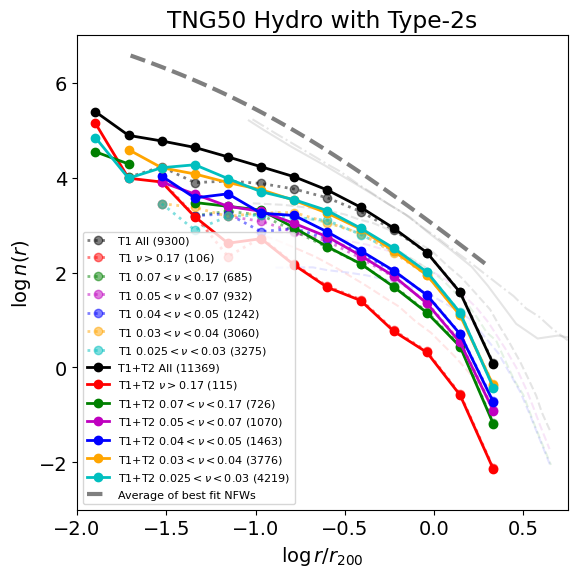

In [30]:
# This is with right stacking and no interpolation - TNG50-hydro

fig, (ax) = plt.subplots(figsize = (6, 6), ncols = 1, sharey = True)

alpha2 = 0.1
ax.plot(np.array(dm_dist_ldf[0]), np.array(dm_dist_ldf[1]), 'k-', alpha = alpha2)
ax.plot(np.array(dm_einasto_ldf[0]), np.array(dm_einasto_ldf[1]), 'k-.', alpha = alpha2)

ax.plot(np.array(v1_ldf[0]), np.array(v1_ldf[1]), 'k--', alpha = alpha2)
ax.plot(np.array(v2_ldf[0]), np.array(v2_ldf[1]), 'r--', alpha = alpha2)
ax.plot(np.array(v3_ldf[0]), np.array(v3_ldf[1]), 'g--', alpha = alpha2)
ax.plot(np.array(v4_ldf[0]), np.array(v4_ldf[1]), 'm--', alpha = alpha2)
ax.plot(np.array(v5_ldf[0]), np.array(v5_ldf[1]), 'b--', alpha = alpha2)


psvrel = np.zeros(len(psvmx_if_ar))
psrrel = np.zeros(len(psvmx_if_ar))
pmvrel = np.zeros(len(pmvmx_if_ar))
pmrrel = np.zeros(len(pmvmx_if_ar))

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    fofd_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd_rvir)

    psvrel[psfof == fofno] = psvmx_if_ar[psfof == fofno] / v200
    psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / fofd_rvir
    pmvrel[pmfof == fofno] = pmvmx_if_ar[pmfof == fofno] / v200
    pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / fofd_rvir

rpl2d1 = np.logspace(-2, 0.6, 15) # rpl2 for TNG100-1-Dark FoF11
rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])

d1n1_ar = np.zeros(0) # These are the arrays which store the densities in each bin
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    print(rpl2d1[ix + 1])
    d1n1_ar = np.append(d1n1_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1])  & (psvrel > 0.025)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n2_ar = np.append(d1n2_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1])  & (psvrel > 0.17)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # print(rpl2d1[ix], rpl2d1[ix + 1])
    # print(len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]))
    d1n6_ar = np.append(d1n6_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.025)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))


norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])


d1n1_ar = np.log10(norm_d1Ns2 * d1n1_ar)
d1n2_ar = np.log10(norm_d1Ns2 * d1n2_ar)
d1n3_ar = np.log10(norm_d1Ns2 * d1n3_ar)
d1n4_ar = np.log10(norm_d1Ns2 * d1n4_ar)
d1n5_ar = np.log10(norm_d1Ns2 * d1n5_ar)
d1n6_ar = np.log10(norm_d1Ns2 * d1n6_ar)
d1n7_ar = np.log10(norm_d1Ns2 * d1n7_ar)
lrpl_interp = np.log10(rpl_interp)

alpha1 = 0.5
ax.plot(lrpl_interp , d1n1_ar, 'ko:',  label = r'T1 All (' + str(len(psdist_f_ar[(psvrel > 0.025)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n2_ar, 'ro:',  label = r'T1 $\nu > 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.17)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n3_ar, 'go:',  label = r'T1 $0.07 < \nu < 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.07) & (psvrel < 0.17)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n4_ar, 'mo:',  label = r'T1 $0.05 < \nu < 0.07$ (' + str(len(psdist_f_ar[(psvrel > 0.05) & (psvrel < 0.07)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n5_ar, 'bo:',  label = r'T1 $0.04 < \nu < 0.05$ (' + str(len(psdist_f_ar[(psvrel > 0.04) & (psvrel < 0.05)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n6_ar, 'o:', color = 'orange',  label = r'T1 $0.03 < \nu < 0.04$ (' + str(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)])) + ')', lw  = 2, alpha = alpha1)
ax.plot(lrpl_interp , d1n7_ar, 'co:',  label = r'T1 $0.025 < \nu < 0.03$ (' + str(len(psdist_f_ar[(psvrel > 0.025) & (psvrel < 0.03)])) + ')', lw  = 2, alpha = alpha1)



# The following part will now be to include the Type-2s as well

d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.025)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel > 0.025)])) 
                        / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # print(len(psdist_f_ar[(psdist_f_ar > rpl2d1[ix]) & (psdist_f_ar < rpl2d1[ix + 1]) & (psfof == fofno) & (psvrel > 0.04) ]))
    d1n2_ar = np.append(d1n2_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel > 0.17)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.17) & (pmvrel > 0.07)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.07) & (pmvrel > 0.05)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.05) & (pmvrel > 0.04)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.04) & (pmvrel > 0.03)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.025)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.03) & (pmvrel > 0.025)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
# print(len(psdist_f_ar[(psfof == fofno)]))

norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])


d1n1_ar = np.log10(norm_d1Ns2 * d1n1_ar)
d1n2_ar = np.log10(norm_d1Ns2 * d1n2_ar)
d1n3_ar = np.log10(norm_d1Ns2 * d1n3_ar)
d1n4_ar = np.log10(norm_d1Ns2 * d1n4_ar)
d1n5_ar = np.log10(norm_d1Ns2 * d1n5_ar)
d1n6_ar = np.log10(norm_d1Ns2 * d1n6_ar)
d1n7_ar = np.log10(norm_d1Ns2 * d1n7_ar)

alpha2 = 1
ax.plot(lrpl_interp , d1n1_ar, 'ko-',  label = r'T1+T2 All (' + str(len(psdist_f_ar[(psvrel > 0.025)]) + len(pmdist_f_ar[(pmvrel > 0.025)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n2_ar, 'ro-',  label = r'T1+T2 $\nu > 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.17)]) + len(pmdist_f_ar[(pmvrel > 0.17)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n3_ar, 'go-',  label = r'T1+T2 $0.07 < \nu < 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.07) & (psvrel < 0.17)]) + len(pmdist_f_ar[(pmvrel > 0.07) & (pmvrel < 0.17)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n4_ar, 'mo-',  label = r'T1+T2 $0.05 < \nu < 0.07$ (' + str(len(psdist_f_ar[(psvrel > 0.05) & (psvrel < 0.07)]) + len(pmdist_f_ar[(pmvrel > 0.05) & (pmvrel < 0.07)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n5_ar, 'bo-',  label = r'T1+T2 $0.04 < \nu < 0.05$ (' + str(len(psdist_f_ar[(psvrel > 0.04) & (psvrel < 0.05)]) + len(pmdist_f_ar[(pmvrel > 0.04) & (pmvrel < 0.05)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n6_ar, 'o-', color = 'orange',  label = r'T1+T2 $0.03 < \nu < 0.04$ (' + str(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)]) + len(pmdist_f_ar[(pmvrel > 0.03) & (pmvrel < 0.04)])) + ')', lw  = 2, alpha = alpha2)

cond_cut = (d1n6_ar != 0) & (d1n6_ar != -np.inf)
print('alpha for nu in (0.03, 0.04)', fit_einasto(10**(lrpl_interp[cond_cut]), 10**(d1n6_ar[cond_cut]))[0][2])
lrho, lrs, alpha = fit_einasto(10**(lrpl_interp[cond_cut]), 10**(d1n6_ar[cond_cut]))[0]
# ax.plot(lrpl_interp[cond_cut], einasto_density(lrpl_interp[cond_cut], lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto with alpha = ' + str(round(alpha, 2)), lw = 3)


ax.plot(lrpl_interp , d1n7_ar, 'co-',  label = r'T1+T2 $0.025 < \nu < 0.03$ (' + str(len(psdist_f_ar[(psvrel > 0.025) & (psvrel < 0.03)]) + len(pmdist_f_ar[(pmvrel > 0.025) & (pmvrel < 0.03)])) + ')', lw  = 2, alpha = alpha2)

norm_rad = 1
rdm_pl = np.logspace(-1.7, np.log10(2), 100)
ax.plot(np.log10(rdm_pl) , np.log10(1000*(nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) + 
                           nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                           nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.)
                 ,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)


ax.legend(fontsize = 8)
# ax.axhline( np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))
ax.set_xlabel(r'$\log r/r_{200}$')
ax.set_ylabel(r'$\log n(r)$')
ax.set_ylim(-3, 7)
ax.set_xlim(-2, 0.75)


ax.set_title('TNG50 Hydro with Type-2s')
plt.tight_layout()
plt.show()

This is for plotting in bins of 
u
811.4848897634926
649.5195962176479
573.0785028184382
0.01 0.013894954943731374
0.013894954943731374 0.019306977288832496
0.019306977288832496 0.02682695795279726
0.02682695795279726 0.0372759372031494
0.0372759372031494 0.0517947467923121
0.0517947467923121 0.07196856730011521
0.07196856730011521 0.1
0.1 0.13894954943731375
0.13894954943731375 0.19306977288832497
0.19306977288832497 0.2682695795279725
0.2682695795279725 0.372759372031494
0.372759372031494 0.517947467923121
0.517947467923121 0.7196856730011517
0.7196856730011517 1.0
106 This is the number of surviving subhalos
9 This is the number of merged subhalos
pNm_ar [2. 2. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
pNs_ar [ 0.  0.  1.  2.  1.  1.  2.  9.  7.  9. 11. 15. 15. 17.]
43854.043768411146 0.013894954943731374 1.5
43854.043768411146 0.013894954943731374 1.5
0.01 0.013894954943731374
0.013894954943731374 0.019306977288832496
0.019306977288832496 0.02682695795279726
0.02682695795279726 0.037275

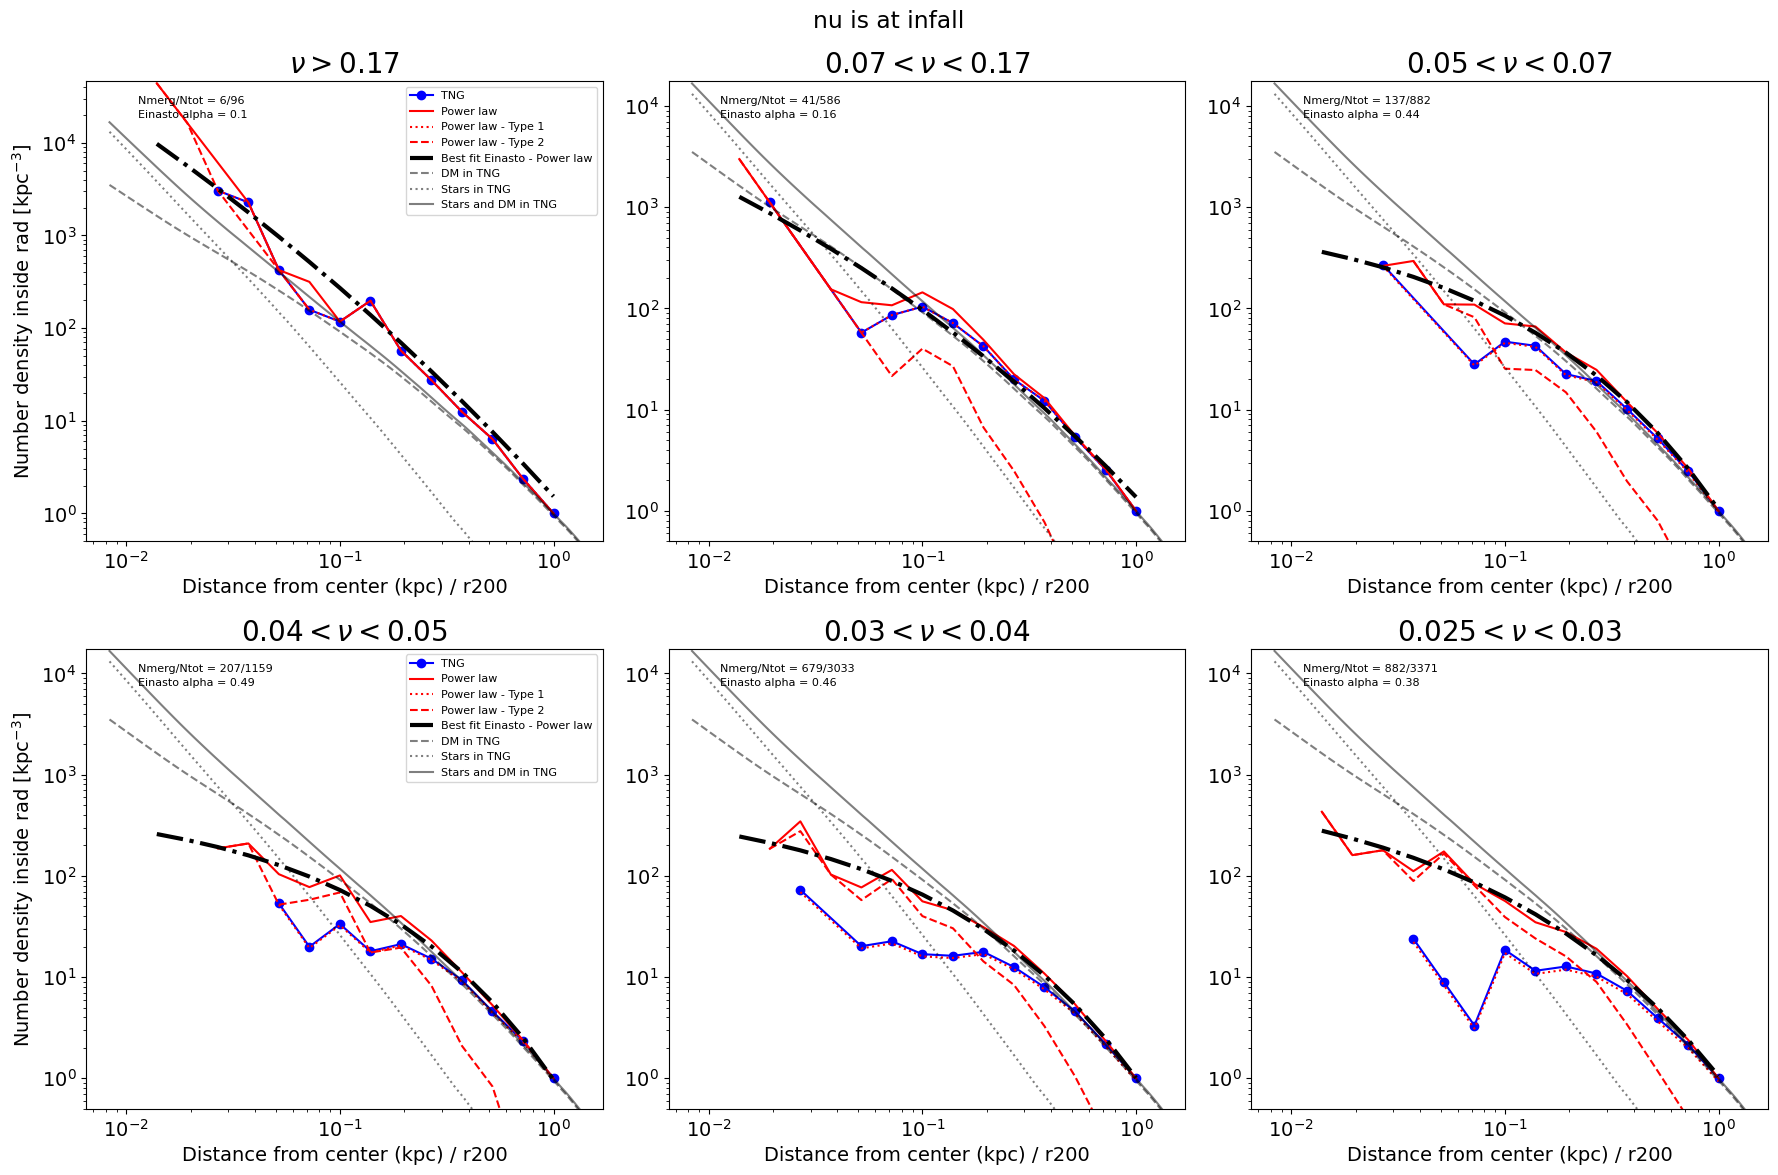

In [75]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately

# This is for checking in bins of \nu
print('This is for plotting in bins of \nu')


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(2, 3, figsize = (18, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    psvrel = np.zeros(len(psvmx_f_ar))
    pmvrel = np.zeros(len(pmvmx_f_ar))
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    for fofno in range(3):
        this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
        
        central_sfid_99 = this_fof['GroupFirstSub']
        cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
        m200 = this_fof['Group_M_Crit200'] * 1e10 / h
        r200 = this_fof['Group_R_Crit200'] / h
        if fofno == 0:
            r200_0 = r200
            # print(r200_0)
        v200 = np.sqrt(G * m200 / r200)
        print(v200)
        
        psvrel[psfof == fofno] = psvmx_if_ar[psfof == fofno] / v200
        pmvrel[pmfof == fofno] = pmvmx_if_ar[pmfof == fofno] / v200
        psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / r200
        pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / r200

    

    for jx in range(6):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        i = int(jx/3)
        j = jx % 3

        if jx == 0:
            nucutoff = 0.17
            numaxcutoff = np.inf
            axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
        elif jx == 1:
            nucutoff = 0.07
            numaxcutoff = 0.17
            axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
        elif jx ==2:
            nucutoff = 0.05
            numaxcutoff = 0.07
            axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
        elif jx ==3:
            nucutoff = 0.04
            numaxcutoff = 0.05
            axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
        elif jx ==4:
            nucutoff = 0.03
            numaxcutoff = 0.04
            axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
        elif jx ==5:
            nucutoff = 0.025
            numaxcutoff = 0.03
            axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
        # s = 1
        # alpha = 0.5
        # ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        # if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(-2, 0, 15)
        norm_rad = 1
        # print(nucutoff, numaxcutoff)
        for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff) & (pmrrel < rs) & (pmrrel > rpl2[ix])]))
            # pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            print(rpl2[ix], rs)
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))
            # print(pNm_ar, pNs_ar)
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))

        
        # print(len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]), 'This is the number of surviving subhalos')
        # print(len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]), 'This is the number of merged subhalos')
        Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
        Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
        
        pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
        
        rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
        rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
        rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)
        # print(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)]))
        # print(len(psdist_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]) + len(pmdist_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]))
        # print('pNm_ar', pNm_ar) 
        # print('pNs_ar', pNs_ar)

        axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
        axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 1.5)
        axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')

        lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
        axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Power law', lw = 3)
        axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[i][j].plot(rpl / r200_0, Ndm_ar / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[i][j].plot(rpl / r200_0, Mstar_ar / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[i][j].plot(rpl / r200_0, Nstar_and_dm / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0 or jx == 3:
            axs[i][j].legend(fontsize = 8)
            axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
        axs[i][j].set_xlabel('Distance from center (kpc) / r200')
        axs[i][j].set_ylim(bottom = 0.5)
        
        axs[i][j].set_xscale('log')
        axs[i][j].set_yscale('log')
    plt.suptitle('nu is at infall')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



This is for plotting in bins of 
u
811.4848897634926
649.5195962176479
573.0785028184382
0.01 0.013894954943731374
0.013894954943731374 0.019306977288832496
0.019306977288832496 0.02682695795279726
0.02682695795279726 0.0372759372031494
0.0372759372031494 0.0517947467923121
0.0517947467923121 0.07196856730011521
0.07196856730011521 0.1
0.1 0.13894954943731375
0.13894954943731375 0.19306977288832497
0.19306977288832497 0.2682695795279725
0.2682695795279725 0.372759372031494
0.372759372031494 0.517947467923121
0.517947467923121 0.7196856730011517
0.7196856730011517 1.0
43854.043768411146 0.013894954943731374 1.5
43854.043768411146 0.013894954943731374 1.5
0.01 0.013894954943731374
0.013894954943731374 0.019306977288832496
0.019306977288832496 0.02682695795279726
0.02682695795279726 0.0372759372031494
0.0372759372031494 0.0517947467923121
0.0517947467923121 0.07196856730011521
0.07196856730011521 0.1
0.1 0.13894954943731375
0.13894954943731375 0.19306977288832497
0.19306977288832497 0.268

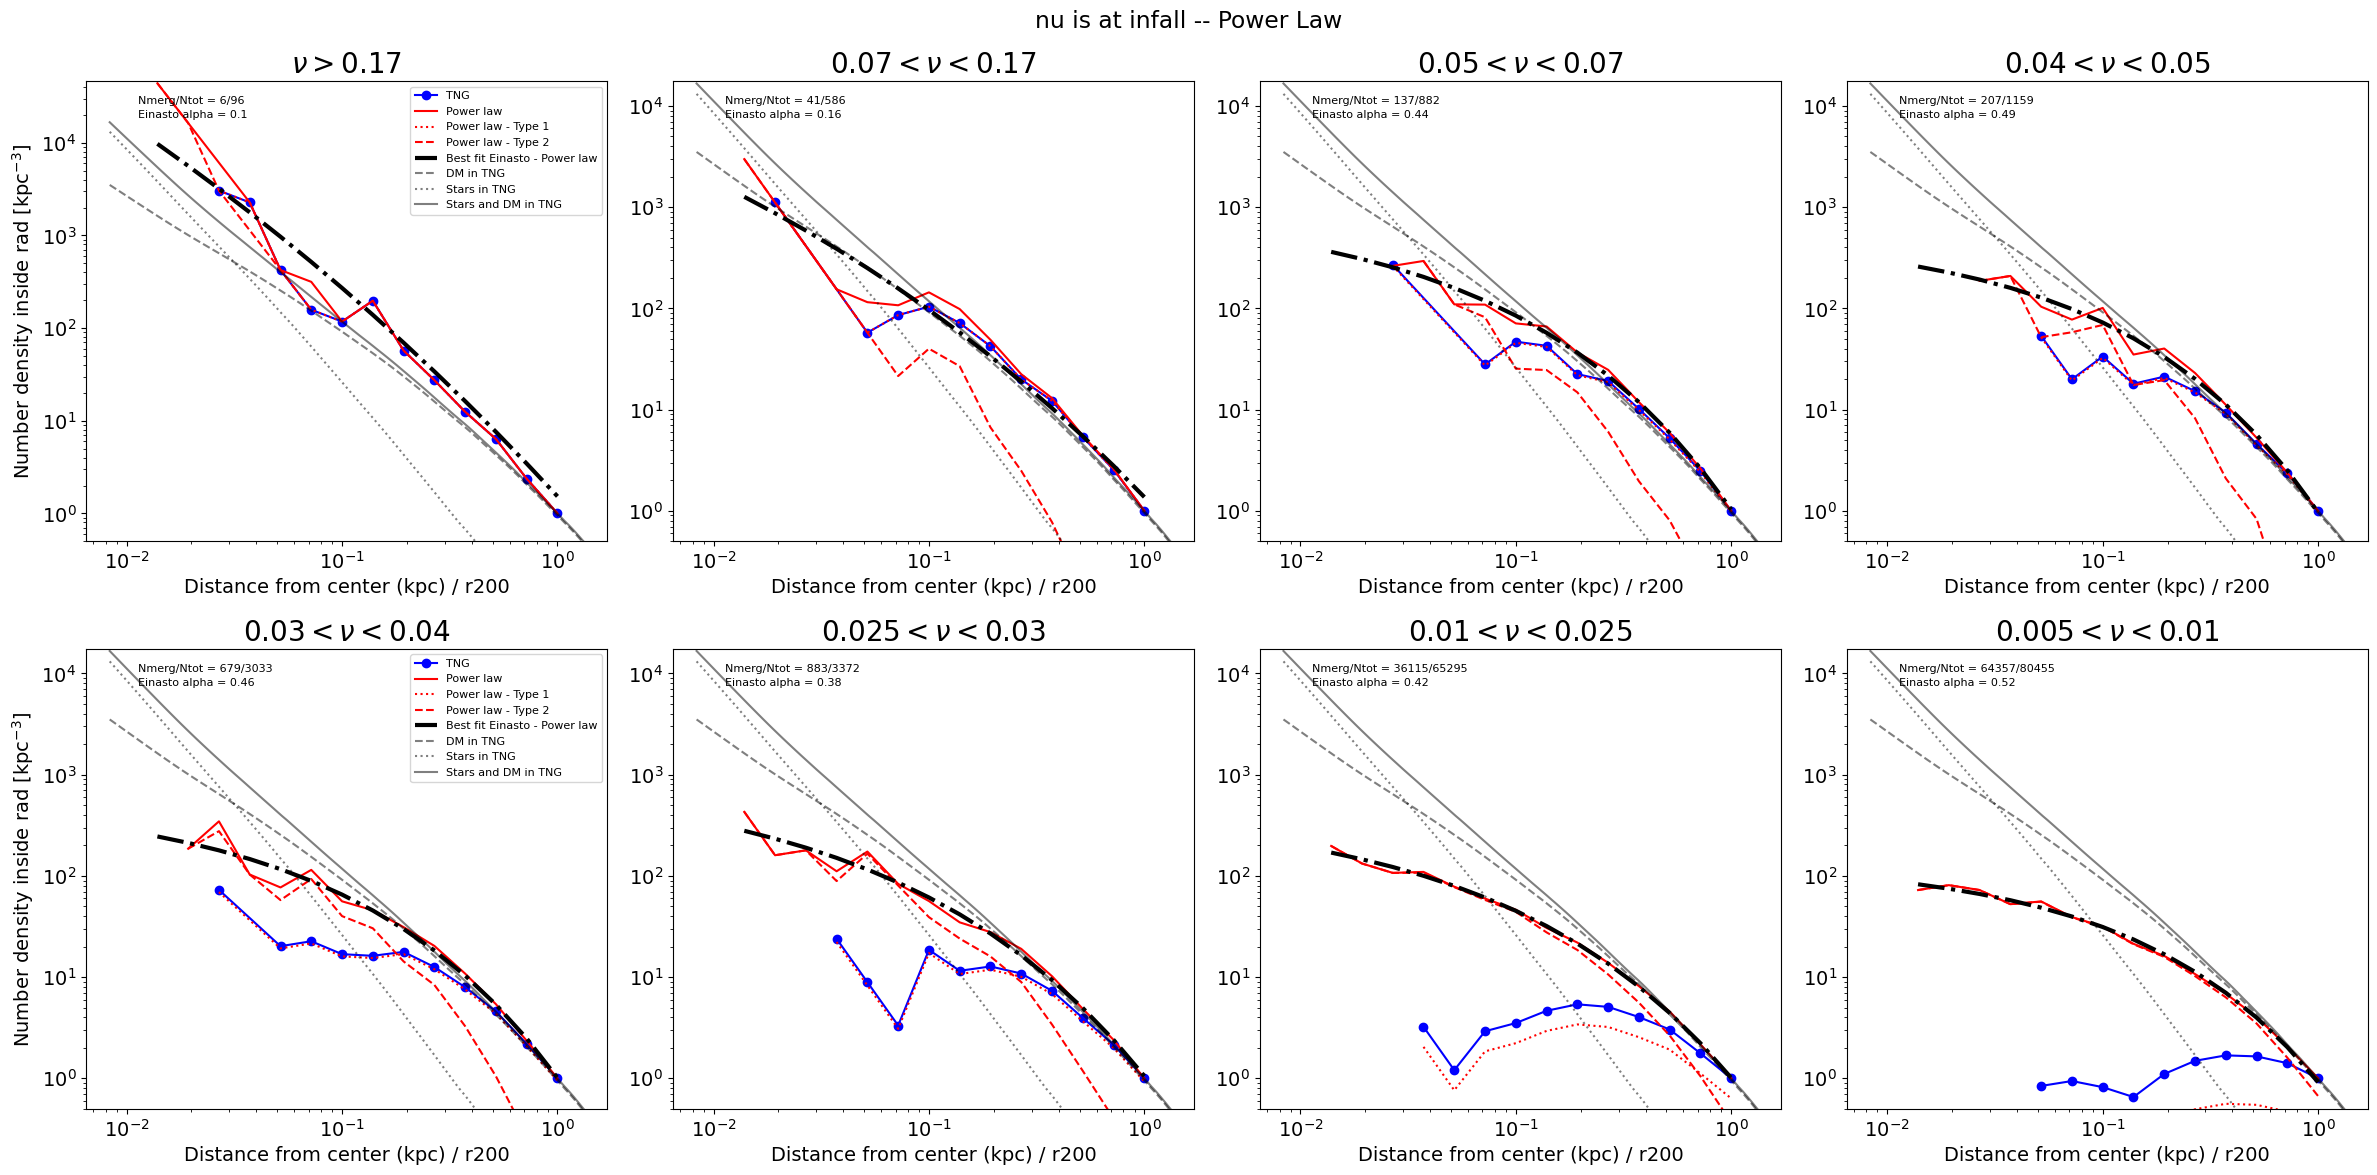

In [79]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately

# This is for checking in bins of \nu
print('This is for plotting in bins of \nu')


def plot_radial_density_dist_3panel():
    '''
    This is to plot the radial density of subhalos in 3 panels for FoF0 in three mass ranges
    '''
    fig, axs = plt.subplots(2, 4, figsize = (24, 12))
    Ndm_ar =[721148, 778322, 839804, 905710, 976898, 1054137, 1137501, 1227676, 1325214, 1430877, 1545758, 1669730, 1805234, 1953330, 2114837, 2291374, 2484727, 2697632, 2929798, 3184435, 3461447, 3763454, 4093457, 4451911, 4839639, 5261067, 5717234, 6218030, 6759960, 7335930, 7958128, 8628601, 9351223, 10124871, 10954252, 11843815, 12803150, 13852694, 14955612, 16130128, 17390800, 18724037, 20147057, 21672913, 23303629, 25059909, 26945144, 28965678, 31153056, 33453105, 35883715, 38490363, 41284274, 44311781, 47556207, 50917974, 54416144, 58216056, 62174887, 66291888, 70515423, 74848372, 79404305, 84157527, 89209147, 94471028, 99857920, 105317116, 111028328, 116939549, 123289439, 130030026, 137275327, 145069112, 153548719, 161907244, 169905804, 177886839, 185830162, 194592334, 203383663, 212695914, 222350306, 232159462, 242040951, 251514511, 260202731, 268769952, 278511000, 289919552, 300273807, 309815832, 319892274, 331241231, 342176869, 352467656, 365061316, 375410309, 383675808, 390894527]
    Mstar_ar = [1215764100000.0, 1254275500000.0, 1293225400000.0, 1332839300000.0, 1373199400000.0, 1414346300000.0, 1456465800000.0, 1499649100000.0, 1543340700000.0, 1587188200000.0, 1631277400000.0, 1676285400000.0, 1723836500000.0, 1770465500000.0, 1818711300000.0, 1868407000000.0, 1921189400000.0, 1975527500000.0, 2031582000000.0, 2091765200000.0, 2152079200000.0, 2214667500000.0, 2279144400000.0, 2346879800000.0, 2415670000000.0, 2483960200000.0, 2560993300000.0, 2639518500000.0, 2717090000000.0, 2789425800000.0, 2865190000000.0, 2938990200000.0, 3014576300000.0, 3088882300000.0, 3166544000000.0, 3234522200000.0, 3303603000000.0, 3403499700000.0, 3475743700000.0, 3541706200000.0, 3611283200000.0, 3671716800000.0, 3740037800000.0, 3803736700000.0, 3863171600000.0, 3924207300000.0, 3984920700000.0, 4047178600000.0, 4116152300000.0, 4179430200000.0, 4235346300000.0, 4302655000000.0, 4361331100000.0, 4432361700000.0, 4508296400000.0, 4587731300000.0, 4649099700000.0, 4724291500000.0, 4775264400000.0, 4826232000000.0, 4874225000000.0, 4915582000000.0, 4958145500000.0, 4994681500000.0, 5043397300000.0, 5096712000000.0, 5136737400000.0, 5176501500000.0, 5222220400000.0, 5250391500000.0, 5282301000000.0, 5315951000000.0, 5351944000000.0, 5401151000000.0, 5537075300000.0, 5626221000000.0, 5672295500000.0, 5750817000000.0, 5774166000000.0, 5900201400000.0, 5929926000000.0, 5960066700000.0, 5986782300000.0, 6014626000000.0, 6088623000000.0, 6145640500000.0, 6163691000000.0, 6178112000000.0, 6282066000000.0, 6651228000000.0, 6749657000000.0, 6765084700000.0, 6809034700000.0, 6949706000000.0, 6986958000000.0, 7002995600000.0, 7282621400000.0, 7327393000000.0, 7357744000000.0, 7428319000000.0]

    rpl = np.logspace(1, 3.2, 100)
    rho_dm = Ndm_ar = np.array(Ndm_ar)*4.5e5 #This would be the density in Msun/kpc^3
        # Ndm_ar = Ndm_ar/Ndm_ar[-1]
    rho_star = Mstar_ar = np.array(Mstar_ar) #This would be the density in Msun/kpc^3
    rho_dm = Ndm_ar/((4/3.) * np.pi * rpl**3)
    rho_star = Mstar_ar/((4/3.) * np.pi * rpl**3)  
    Nstar_and_dm = (rho_dm + rho_star) / (rho_dm[-1] + rho_star[-1])

    Ndm_ar = Ndm_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)
    Mstar_ar = Mstar_ar / (rho_dm[-1] + rho_star[-1]) /((4/3.) * np.pi * rpl**3)

    psvrel = np.zeros(len(psvmx_f_ar))
    pmvrel = np.zeros(len(pmvmx_f_ar))
    # Nstar_ar = Nstar_ar/Nstar_ar[-1]
    for fofno in range(3):
        this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
        
        central_sfid_99 = this_fof['GroupFirstSub']
        cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
        m200 = this_fof['Group_M_Crit200'] * 1e10 / h
        r200 = this_fof['Group_R_Crit200'] / h
        if fofno == 0:
            r200_0 = r200
            # print(r200_0)
        v200 = np.sqrt(G * m200 / r200)
        print(v200)
        
        psvrel[psfof == fofno] = psvmx_if_ar[psfof == fofno] / v200
        pmvrel[pmfof == fofno] = pmvmx_if_ar[pmfof == fofno] / v200
        psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / r200
        pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / r200

    

    for jx in range(8):
        pNm_ar = np.zeros(0) #shmf for merged subhalos
        pNm_ar_gp = np.zeros(0)
        pNs_ar = np.zeros(0) #shmf for surviving subhalos 
        cNm_ar = np.zeros(0) #shmf for merged subhalos
        cNs_ar = np.zeros(0) #shmf for surviving subhalos

        N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
        Ntng_ar = np.zeros(0)
              
        i = int(jx/4)
        j = jx % 4

        if jx == 0:
            nucutoff = 0.17
            numaxcutoff = np.inf
            axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
        elif jx == 1:
            nucutoff = 0.07
            numaxcutoff = 0.17
            axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
        elif jx ==2:
            nucutoff = 0.05
            numaxcutoff = 0.07
            axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
        elif jx ==3:
            nucutoff = 0.04
            numaxcutoff = 0.05
            axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
        elif jx ==4:
            nucutoff = 0.03
            numaxcutoff = 0.04
            axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
        elif jx ==5:
            nucutoff = 0.025
            numaxcutoff = 0.03
            axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
        elif jx ==6:
            nucutoff = 0.01
            numaxcutoff = 0.025
            axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
        elif jx ==7:
            nucutoff = 0.005
            numaxcutoff = 0.01
            axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
        # s = 1
        # alpha = 0.5
        # ax2[jx].scatter(pmdist_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], pmpot_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff)& (pmfof == 0)], s=s, alpha = alpha, color = 'orange', label = 'Type - 2')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff)& (psfof == 0)], pspot_f_ar[(psmstar_all > mplcutoff) & (psmstar_all < mmaxcutoff) & (psfof == 0)], s=s, alpha = alpha, color = 'skyblue', label = 'Type - 1')
        # ax2[jx].scatter(psdist_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15)& (psfof == 0)], pspot_f_ar[(psmstar_all > 10**8) & (psmstar_all < 10**15) & (psfof == 0)], s=s, alpha = 1, color = 'black', label = '>1e8')
        # if jx == 0: ax2[jx].legend(fontsize = 8)
        rpl2 = np.logspace(-2, 0, 15)
        norm_rad = 1
        # print(nucutoff, numaxcutoff)
        for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
            pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff) & (pmrrel < rs) & (pmrrel > rpl2[ix])]))
            # pNm_ar_gp = np.append(pNm_ar_gp, len(pmmstar_f_ar[(pmmstar_all > mplcutoff) & (pmmstar_all < mmaxcutoff) & (pmgp_dist_f_ar < rs) & (pmfof == 0)]))
            print(rpl2[ix], rs)
            pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))
            # print(pNm_ar, pNs_ar)
            # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
            # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
            Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))

        
        # print(len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]), 'This is the number of surviving subhalos')
        # print(len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]), 'This is the number of merged subhalos')
        Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
        Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
        
        pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
        
        rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
        rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
        rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
        
        axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)
        # print(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)]))
        # print(len(psdist_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]) + len(pmdist_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]))
        # print('pNm_ar', pNm_ar) 
        # print('pNs_ar', pNs_ar)

        axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
        axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 1.5)
        axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
        axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')

        lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
        axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Power law', lw = 3)
        axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
        
        # axs[jx].plot(rpl2, pN_ar_gp, '^-', color = 'maroon', label = r'Power law - Galpy for Type 2', lw = 1.5)

        axs[i][j].plot(rpl / r200_0, Ndm_ar / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
        axs[i][j].plot(rpl / r200_0, Mstar_ar / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = ':', label = 'Stars in TNG', alpha = 0.5)
        axs[i][j].plot(rpl / r200_0, Nstar_and_dm / np.interp(r200_0, rpl, Nstar_and_dm), color = 'black', ls = '-', label = 'Stars and DM in TNG', alpha = 0.5)
        if jx == 0 or jx == 4:
            axs[i][j].legend(fontsize = 8)
            axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
        axs[i][j].set_xlabel('Distance from center (kpc) / r200')
        axs[i][j].set_ylim(bottom = 0.5)
        
        axs[i][j].set_xscale('log')
        axs[i][j].set_yscale('log')
    plt.suptitle('nu is at infall -- Power Law')
    plt.tight_layout()
    # plt.savefig(this_fof_plotppath + 'radial_density_dist_3panel.png')
    plt.show()
        


    return

plot_radial_density_dist_3panel()



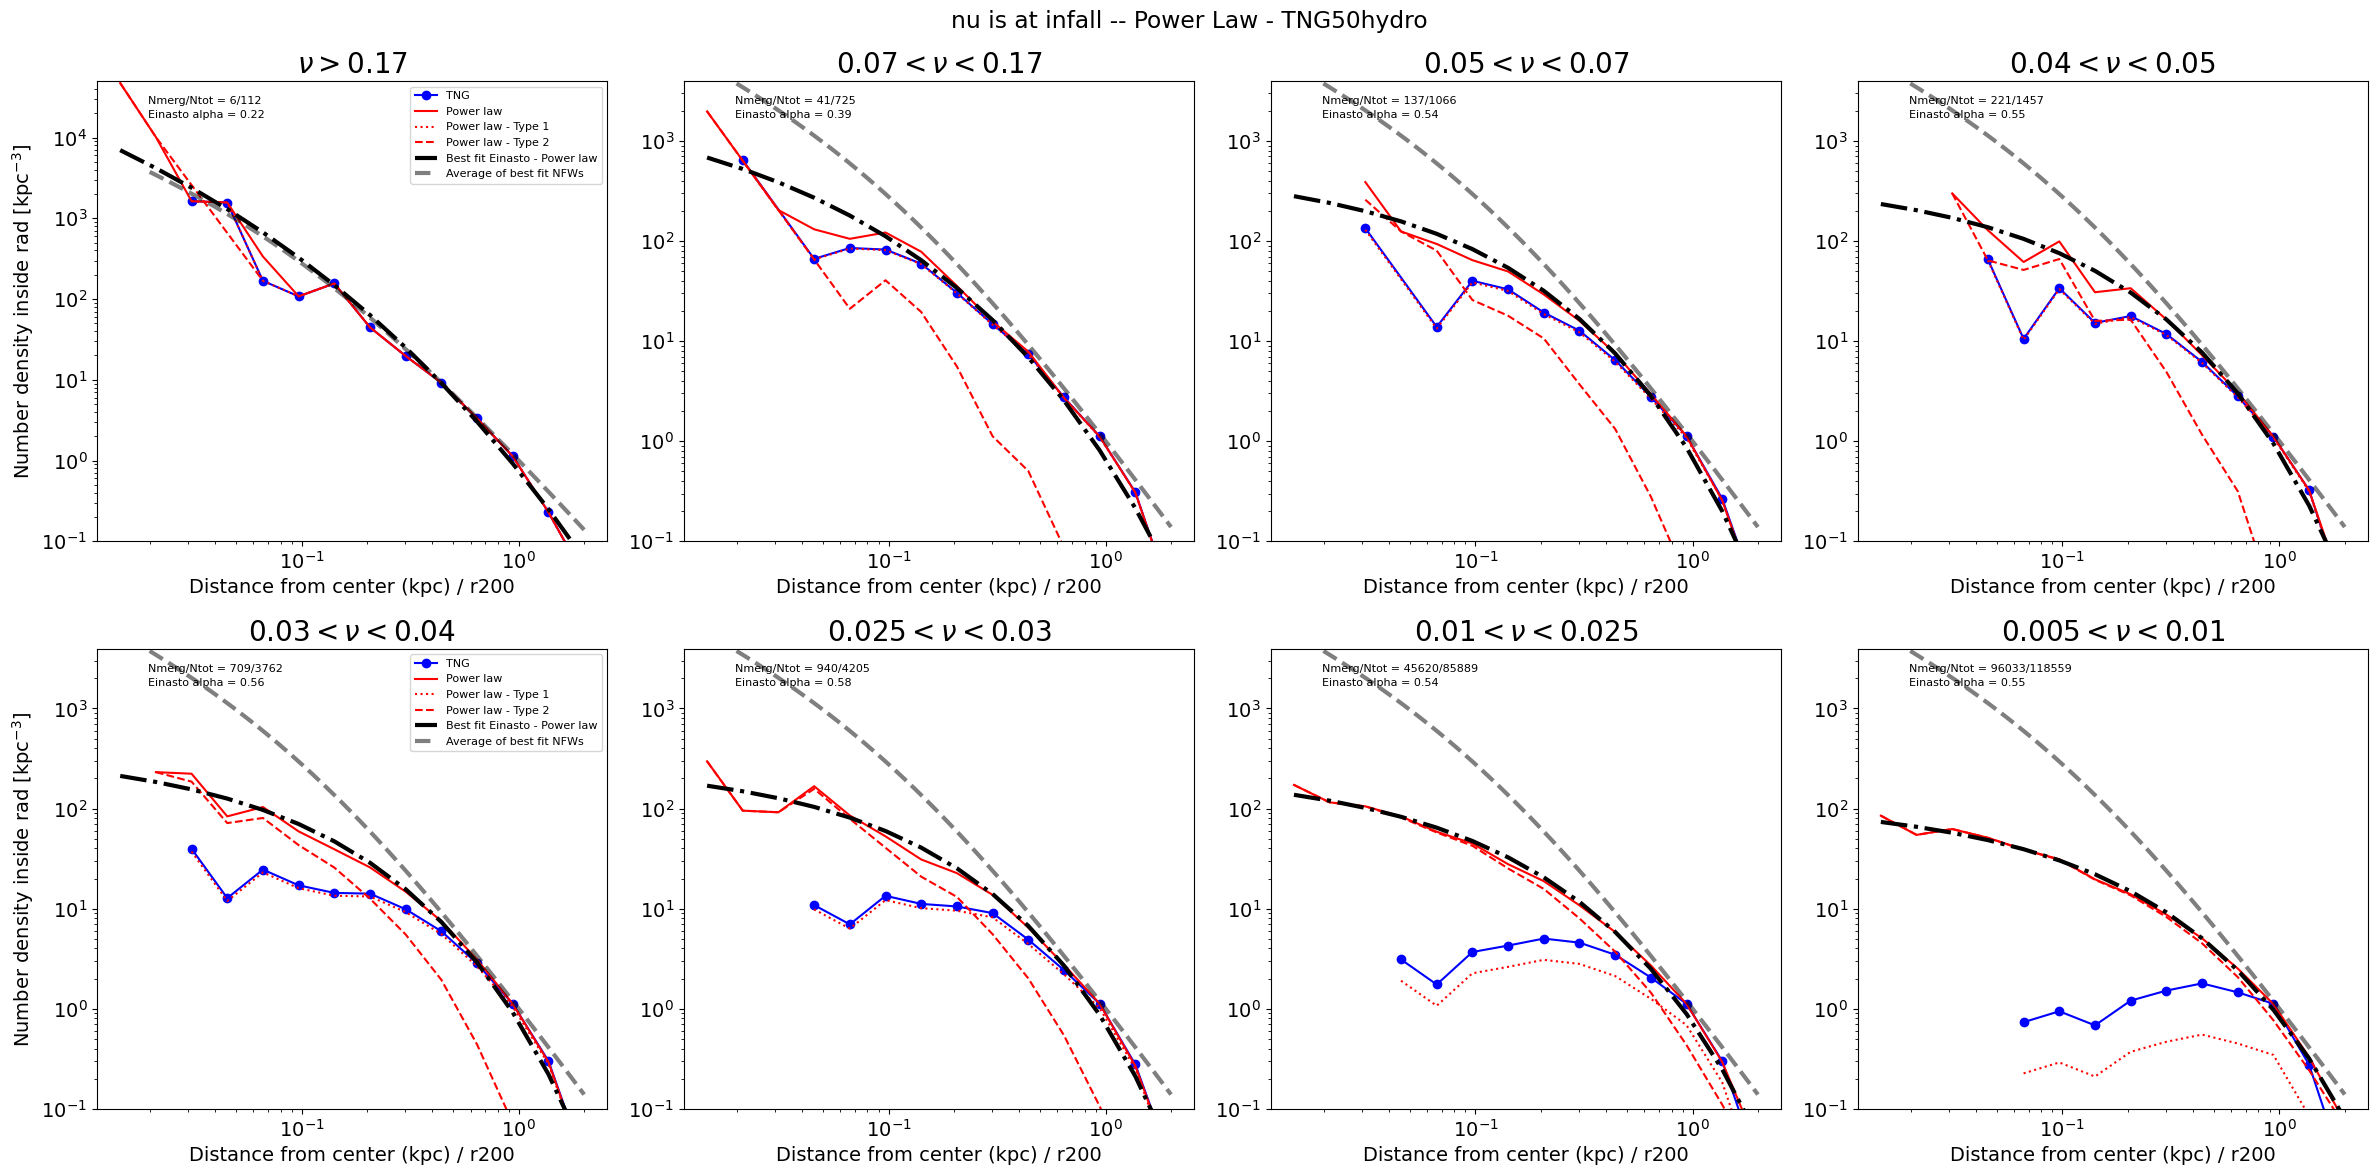

In [117]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately
fig, axs = plt.subplots(2, 4, figsize = (24, 12))


psvrel = np.zeros(len(psvmx_f_ar))
pmvrel = np.zeros(len(pmvmx_f_ar))
psrrel = np.zeros(len(psvmx_f_ar))
pmrrel = np.zeros(len(pmvmx_f_ar))
# Nstar_ar = Nstar_ar/Nstar_ar[-1]
for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    
    central_sfid_99 = this_fof['GroupFirstSub']
    cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    r200 = this_fof['Group_R_Crit200'] / h
    if fofno == 0:
        r200_0 = r200
        # print(r200_0)
    v200 = np.sqrt(G * m200 / r200)
    # print(v200)
    
    psvrel[psfof == fofno] = psvmx_if_ar[psfof == fofno] / v200
    pmvrel[pmfof == fofno] = pmvmx_if_ar[pmfof == fofno] / v200
    psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / r200
    pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / r200

    

for jx in range(8):
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNm_ar_gp = np.zeros(0)
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos

    N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
    Ntng_ar = np.zeros(0)
            
    i = int(jx/4)
    j = jx % 4

    if jx == 0:
        nucutoff = 0.17
        numaxcutoff = np.inf
        axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
    elif jx == 1:
        nucutoff = 0.07
        numaxcutoff = 0.17
        axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
    elif jx ==2:
        nucutoff = 0.05
        numaxcutoff = 0.07
        axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
    elif jx ==3:
        nucutoff = 0.04
        numaxcutoff = 0.05
        axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
    elif jx ==4:
        nucutoff = 0.03
        numaxcutoff = 0.04
        axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
    elif jx ==5:
        nucutoff = 0.025
        numaxcutoff = 0.03
        axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
    elif jx ==6:
        nucutoff = 0.01
        numaxcutoff = 0.025
        axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
    elif jx ==7:
        nucutoff = 0.005
        numaxcutoff = 0.01
        axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
    rpl2 = np.logspace(-2, np.log10(2), 15)
    norm_rad = 1
    for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
        pNm_ar = np.append(pNm_ar, len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff) & (pmrrel < rs) & (pmrrel > rpl2[ix])]))
        pNs_ar = np.append(pNs_ar, len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))
        # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
        # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
        Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))

    
    # print(len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]), 'This is the number of surviving subhalos')
    # print(len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]), 'This is the number of merged subhalos')
    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    
    pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    
    rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)

    axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
    axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 1.5)
    axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
    axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')

    lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
    axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Power law', lw = 3)
    axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
    
    norm_rad = 1
    rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    axs[i][j].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) +  nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                            nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)
    if jx == 0 or jx == 4:
        axs[i][j].legend(fontsize = 8)
        axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
    axs[i][j].set_xlabel('Distance from center (kpc) / r200')
    axs[i][j].set_ylim(bottom = 0.1)
    
    axs[i][j].set_xscale('log')
    axs[i][j].set_yscale('log')
plt.suptitle('nu is at infall -- Power Law - TNG50hydro')
plt.tight_layout()
plt.show()

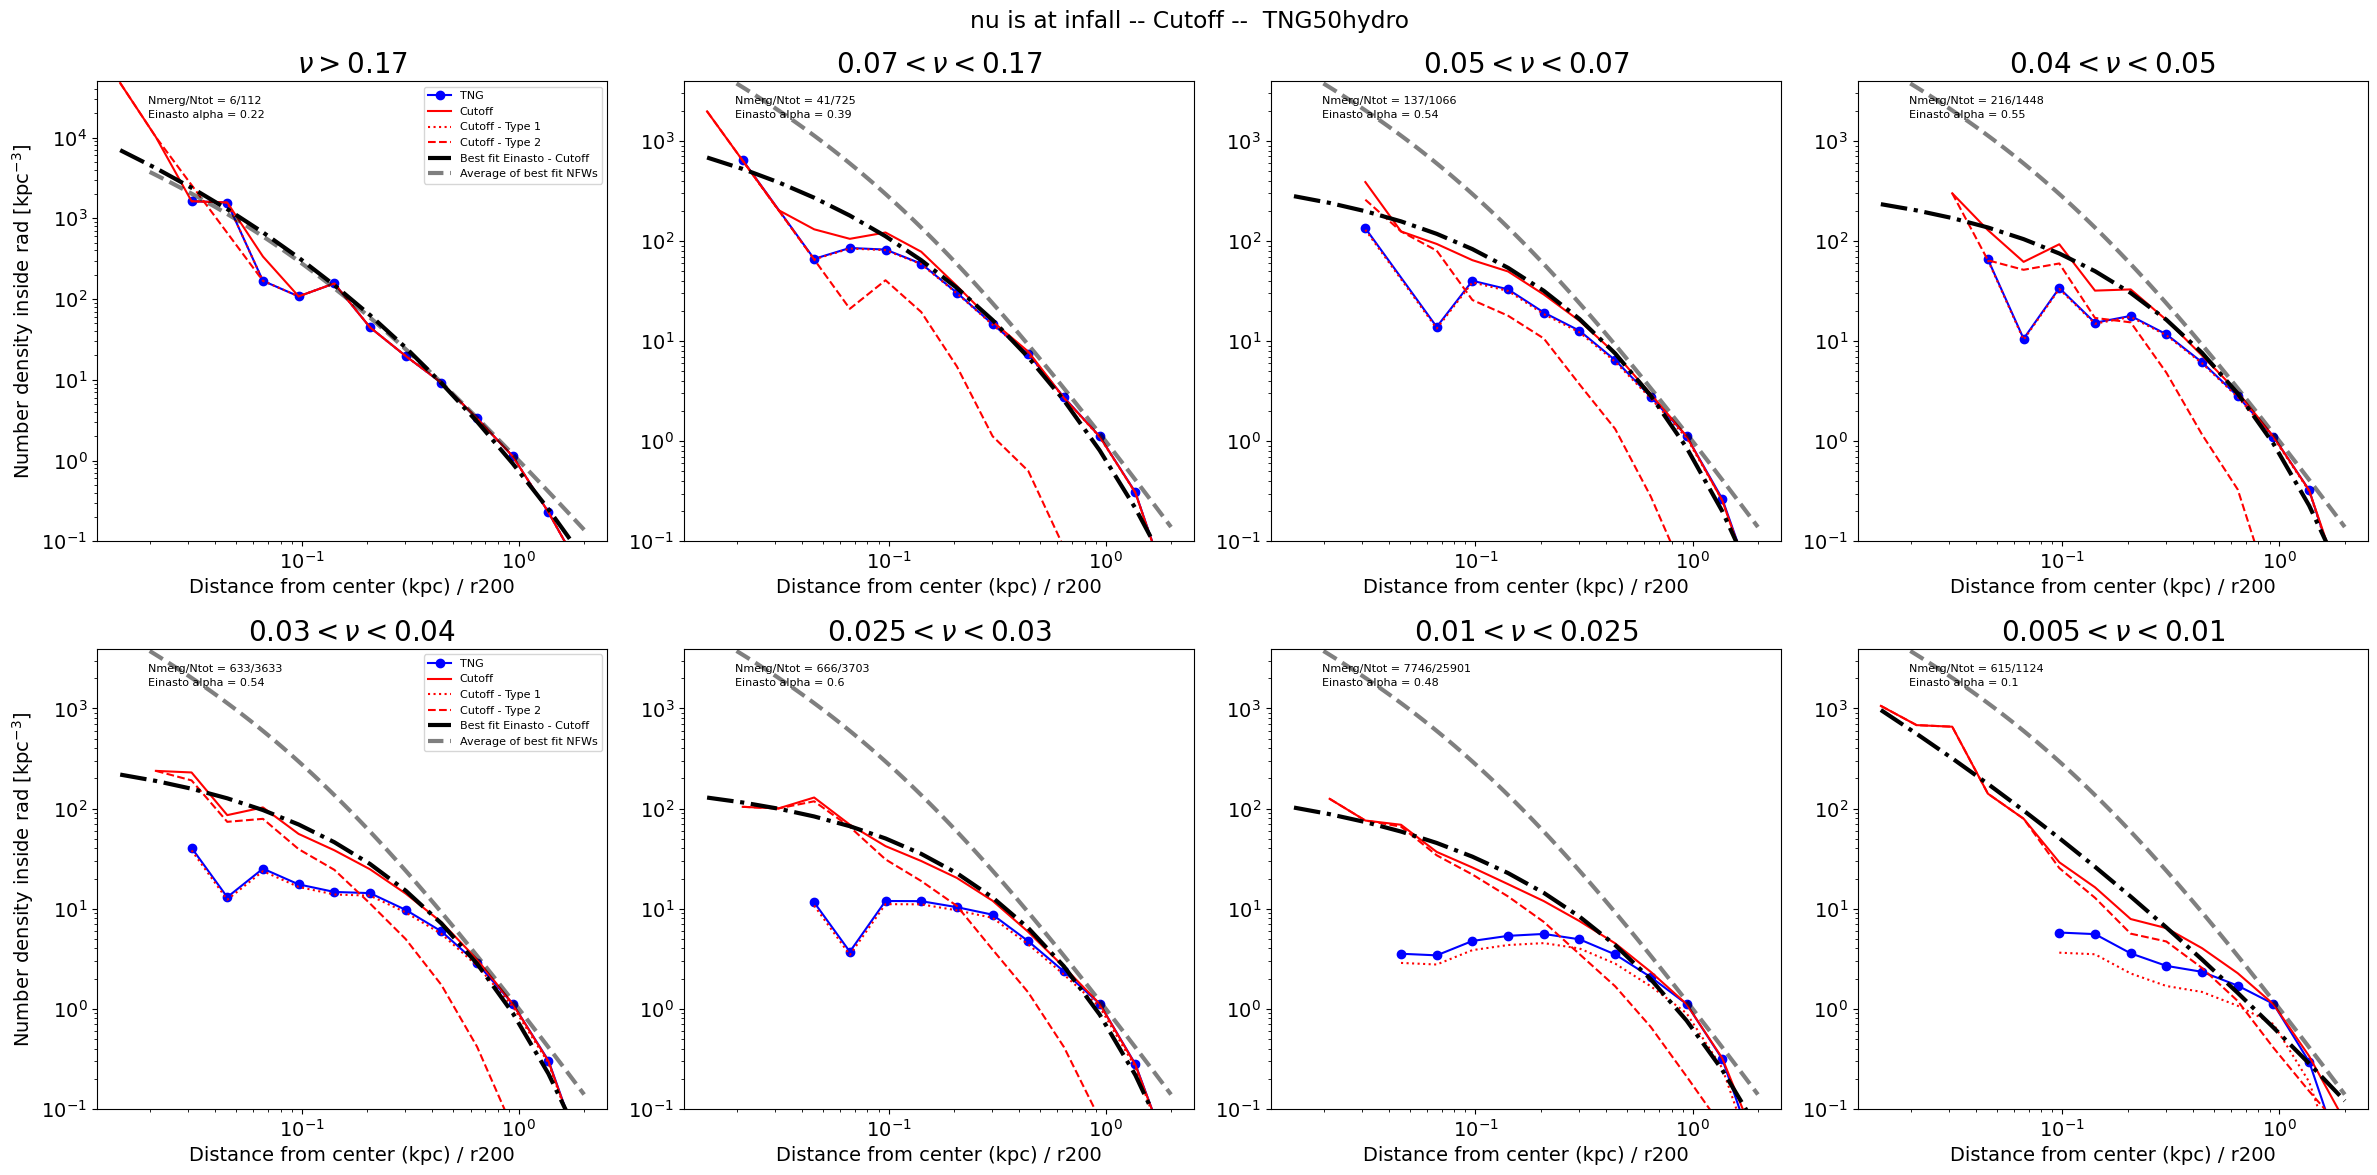

In [116]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately
fig, axs = plt.subplots(2, 4, figsize = (24, 12))


csvrel = np.zeros(len(csvmx_f_ar))
cmvrel = np.zeros(len(cmvmx_f_ar))
csrrel = np.zeros(len(csdist_f_ar))
cmrrel = np.zeros(len(cmdist_f_ar))
# Nstar_ar = Nstar_ar/Nstar_ar[-1]
for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    
    central_sfid_99 = this_fof['GroupFirstSub']
    cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    r200 = this_fof['Group_R_Crit200'] / h
    if fofno == 0:
        r200_0 = r200
        # print(r200_0)
    v200 = np.sqrt(G * m200 / r200)
    # print(v200)
    
    csvrel[csfof == fofno] = csvmx_if_ar[csfof == fofno] / v200
    cmvrel[cmfof == fofno] = cmvmx_if_ar[cmfof == fofno] / v200
    csrrel[csfof == fofno] = csdist_f_ar[csfof == fofno] / r200
    cmrrel[cmfof == fofno] = cmdist_f_ar[cmfof == fofno] / r200

    

for jx in range(8):
    cN_ar = np.zeros(0) #shmf for merged subhalos
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos

    N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
    Ntng_ar = np.zeros(0)
            
    i = int(jx/4)
    j = jx % 4

    if jx == 0:
        nucutoff = 0.17
        numaxcutoff = np.inf
        axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
    elif jx == 1:
        nucutoff = 0.07
        numaxcutoff = 0.17
        axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
    elif jx ==2:
        nucutoff = 0.05
        numaxcutoff = 0.07
        axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
    elif jx ==3:
        nucutoff = 0.04
        numaxcutoff = 0.05
        axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
    elif jx ==4:
        nucutoff = 0.03
        numaxcutoff = 0.04
        axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
    elif jx ==5:
        nucutoff = 0.025
        numaxcutoff = 0.03
        axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
    elif jx ==6:
        nucutoff = 0.01
        numaxcutoff = 0.025
        axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
    elif jx ==7:
        nucutoff = 0.005
        numaxcutoff = 0.01
        axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
    rpl2 = np.logspace(-2, np.log10(2), 15)
    norm_rad = 1
    for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
        cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmvrel > nucutoff) & (cmvrel < numaxcutoff) & (cmrrel < rs) & (cmrrel > rpl2[ix])]))
        cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csvrel > nucutoff) & (csvrel < numaxcutoff) & (csrrel < rs) & (csrrel > rpl2[ix])]))
        # cNm_ar = np.append(cNm_ar, len(cmmstar_f_ar[(cmmstar_all > mplcutoff) & (cmmstar_all < mmaxcutoff) & (cmdist_f_ar < rs) & (cmfof == 0)]))
        # cNs_ar = np.append(cNs_ar, len(csmstar_f_ar[(csmstar_all > mplcutoff) & (csmstar_all < mmaxcutoff) & (csdist_f_ar < rs) & (csfof == 0)]))
        Ntng_ar = np.append(Ntng_ar, len(csmstar_f_ar_tng[(csvrel > nucutoff) & (csvrel < numaxcutoff) & (csrrel < rs) & (csrrel > rpl2[ix])]))

    
    # print(len(psmstar_f_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff)]), 'This is the number of surviving subhalos')
    # print(len(pmmstar_f_ar[(pmvrel > nucutoff) & (pmvrel < numaxcutoff)]), 'This is the number of merged subhalos')
    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    
    cN_ar = (cNs_ar + cNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    
    rhos_ar = cNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], cN_ar)
    
    rhom_ar = cNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], cN_ar)
    
    cN_ar = cN_ar / np.interp(norm_rad, rpl2[1:], cN_ar)
    
    axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(cNm_ar))) + '/' + str(int(np.sum(cNs_ar) + np.sum(cNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)

    axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
    axs[i][j].plot(rpl2[1:][cN_ar != 0], cN_ar[cN_ar != 0], color = 'red', label = r'Cutoff', lw  = 1.5)
    axs[i][j].plot(rpl2[1:][cNs_ar != 0], rhos_ar[cNs_ar != 0], color = 'red', label = r'Cutoff - Type 1', lw  = 1.5, ls = ':')
    axs[i][j].plot(rpl2[1:][cNm_ar != 0], rhom_ar[cNm_ar != 0], color = 'red', label = r'Cutoff - Type 2', lw  = 1.5, ls = '--')

    lrho, lrs, alpha = fit_einasto(rpl2[1:][cN_ar != 0], cN_ar[cN_ar != 0])[0]
    axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Cutoff', lw = 3)
    axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][cN_ar != 0], cN_ar[cN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
    
    norm_rad = 1
    rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    axs[i][j].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) +  nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                            nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)
    if jx == 0 or jx == 4:
        axs[i][j].legend(fontsize = 8)
        axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
    axs[i][j].set_xlabel('Distance from center (kpc) / r200')
    axs[i][j].set_ylim(bottom = 0.1)
    
    axs[i][j].set_xscale('log')
    axs[i][j].set_yscale('log')
plt.suptitle('nu is at infall -- Cutoff --  TNG50hydro')
plt.tight_layout()
plt.show()

In [18]:
# This is to import the Type-2 satellite data

t1ddf2 = pd.read_csv(t100dfilepath + 'master_t2_tng100d.csv')
t1ddf2 = t1ddf2.applymap(convert_to_float)

t1t2_posx = t1ddf2['posx_ar'].values
t1t2_posy = t1ddf2['posy_ar'].values
t1t2_posz = t1ddf2['posz_ar'].values

t1t2_dist = np.sqrt(t1t2_posx**2 + t1t2_posy**2 + t1t2_posz**2)

t1t2_vmax_if = t1ddf2['vmax_if_ar'].values
t1t2_fof = t1ddf2['fof'].values



# posxd1_ar2 = t1ddf2['posx_ar'].values
# posyd1_ar2 = t1ddf2['posy_ar'].values
# poszd1_ar2 = t1ddf2['posz_ar'].values

# posd1_ar = np.stack((posxd1_ar, posyd1_ar, poszd1_ar), axis = 1)

# velxd1_ar = t1ddf2['velx_ar'].values
# velyd1_ar = t1ddf2['vely_ar'].values
# velzd1_ar = t1ddf2['velz_ar'].values

# veld1_ar = np.stack((velxd1_ar, velyd1_ar, velzd1_ar), axis = 1)

# vel_f_r = np.einsum('ij, ij->i', posd1_ar, veld1_ar)*(1/np.linalg.norm(posd1_ar, axis = 1)) # This is the radial component
# vel_f_t = np.sqrt(np.linalg.norm(veld1_ar, axis = 1)**2 - vel_f_r**2)

# vmaxd1_ar = t1ddf2['vmax_ar'].values
# lend1_ar = t1ddf2['len_ar'].values
# fofno1_ar = t1ddf2['fof'].values
# vmax_ifd1_ar = t1ddf2['vmax_if_ar'].values
# massd1_ar = t1ddf2['mass_ar'].values
# sfid_ifd1_ar = t1ddf2['sfid_if_ar']
# snap_ifd1_ar = t1ddf2['snap_if_ar']
# distd1_ar = np.sqrt((posxd1_ar)**2 + (posyd1_ar )**2 + (poszd1_ar )**2)


In [96]:
# This is to import the Type-2 satellite data

t5ddf2 = pd.read_csv(t50dfilepath + 'master_t2_tng50d.csv')
t5ddf2 = t5ddf2.applymap(convert_to_float)
print(t5ddf2.columns)

t5t2_posx = t5ddf2['posx_ar'].values
t5t2_posy = t5ddf2['posy_ar'].values
t5t2_posz = t5ddf2['posz_ar'].values

t5t2_dist = np.sqrt(t5t2_posx**2 + t5t2_posy**2 + t5t2_posz**2)

t5t2_mdm_if = t5ddf2['mdm_if_ar'].values
t5t2_vmax_if = t5ddf2['vmax_if_ar'].values
t5t2_fof = t5ddf2['fof'].values
t5t2_vpeak = t5ddf2['vpeak'].values

Index(['posx_ar', 'posy_ar', 'posz_ar', 'vmax_merger_ar_merger',
       'mass_merger_ar', 'len_merger_ar', 'sfid_merger_ar', 'snap_merger_ar',
       'snap_if_ar', 'sfid_if_ar', 'vmax_if_ar', 'mdm_if_ar', 'inf1_snap_ar',
       'inf1_sfid_ar', 'vpeak', 'velx_ar', 'vely_ar', 'velz_ar', 'merged_into',
       'crossing_snap', 'crossing_sfid', 'fof'],
      dtype='object')


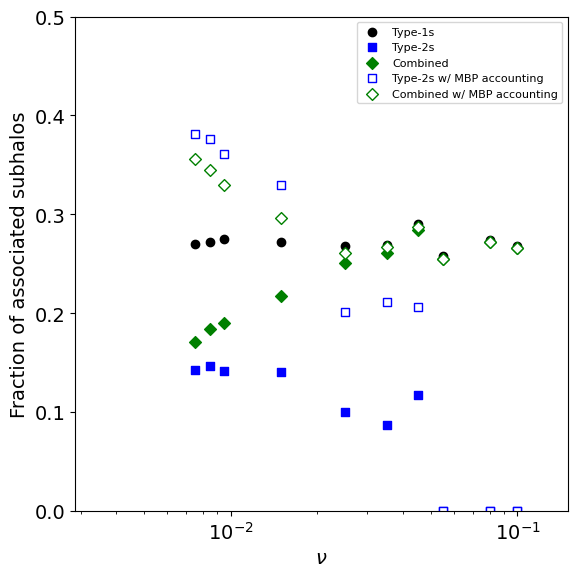

In [12]:
h = 0.6744
G = 4.3e-6

# The goal of this cell is to generate the fraction of associated subhalos (subhalos outside the virial radius) as a function of nu
psvrel = np.zeros(len(psvmx_f_ar))
psrrel = np.zeros(len(psvmx_f_ar)) # This is the distance at z = 0 wrt the virial radius

pmvrel = np.zeros(len(pmvmx_f_ar)) # 
pmrrel = np.zeros(len(pmvmx_f_ar)) # 
pmrrel2 = np.zeros(len(pmvmx_f_ar)) # This is for the merged subhalos without the MBP location in the FoF

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    
    central_sfid_99 = this_fof['GroupFirstSub']
    cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    r200 = this_fof['Group_R_Crit200'] / h
    v200 = np.sqrt(G * m200 / r200)
    
    psvrel[psfof == fofno] = psvmx_f_ar[psfof == fofno] / v200
    psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / r200
    
    pmvrel[pmfof == fofno] = pmvmx_f_ar[pmfof == fofno] / v200
    pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / r200
    pmrrel2[(pmfof == fofno)] = pmdist_f_ar[(pmfof == fofno)] / r200

pmrrel2[pmdist_f_ar == np.inf] = 2

# print(psvrel)
    
def plot_ass_frac(nu_min, nu_max, fofno = None):
    if fofno == None:
        fofcond = psfof > -1
    else:
        fofcond = psfof == fofno
    ass_frac = len( psvrel[fofcond & (psvrel > nu_min) & (psvrel < nu_max) & (psrrel > 1)]) / len( psvrel[fofcond & (psvrel > nu_min) & (psvrel < nu_max) ]) # number of subhalos in this bin outside the virial radius divided by the total number of subhalos in this bin
    return ass_frac

def plot_ass_frac2(nu_min, nu_max, fofno = None):
    '''
    This is for Type-2s, this function returns the fraction of subhalos outside the virial radius for a given nu range 
    '''
    if fofno == None:
        fofcond = pmfof > -1
    else:
        fofcond = pmfof == fofno
    ass_frac = len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel > 1) & (pmrrel != np.inf)]) / len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) ]) # number of subhalos in this bin outside the virial radius divided by the total number of subhalos in this bin
    # print(len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel > 1)]))
    return ass_frac


def plot_ass_frac3(nu_min, nu_max, fofno = None):
    '''
    This is for Type-2s, this function returns the fraction of subhalos outside the virial radius for a given nu range 
    '''
    if fofno == None:
        fofcondm = pmfof > -1
        fofconds = psfof > -1
    else:
        fofcondm = pmfof == fofno
        fofconds = psfof == fofno
    ass_frac = (len( pmvrel[fofcondm & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel > 1) & (pmrrel != np.inf)] )
                   + len( psvrel[fofconds & (psvrel > nu_min) & (psvrel < nu_max) & (psrrel > 1)] )) / (len( pmvrel[fofcondm & (pmvrel > nu_min) & (pmvrel < nu_max) ]) +  len( psvrel[fofconds & (psvrel > nu_min) & (psvrel < nu_max) ])) # number of subhalos in this bin outside the virial radius divided by the total number of subhalos in this bin
    return ass_frac



def plot_ass_frac4(nu_min, nu_max, fofno = None):
    '''
    This is for Type-2s, this function returns the fraction of subhalos outside the virial radius for a given nu range 
    '''
    if fofno == None:
        fofcond = pmfof > -1
    else:
        fofcond = pmfof == fofno
    ass_frac = len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel2 > 1)]) / len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) ]) # number of subhalos in this bin outside the virial radius divided by the total number of subhalos in this bin
    # print(len( pmvrel[fofcond & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel2 > 1)]))
    return ass_frac


def plot_ass_frac5(nu_min, nu_max, fofno = None):
    '''
    This is for Type-2s, this function returns the fraction of subhalos outside the virial radius for a given nu range 
    '''
    if fofno == None:
        fofcondm = pmfof > -1
        fofconds = psfof > -1
    else:
        fofcondm = pmfof == fofno
        fofconds = psfof == fofno
    ass_frac = (len( pmvrel[fofcondm & (pmvrel > nu_min) & (pmvrel < nu_max) & (pmrrel2 > 1)] )
                   + len( psvrel[fofconds & (psvrel > nu_min) & (psvrel < nu_max) & (psrrel > 1)] )) / (len( pmvrel[fofcondm & (pmvrel > nu_min) & (pmvrel < nu_max) ]) + 
                                                                                                       len( psvrel[fofconds & (psvrel > nu_min) & (psvrel < nu_max) ])) # number of subhalos in this bin outside the virial radius divided by the total number of subhalos in this bin
    return ass_frac



fig, ax = plt.subplots(figsize = (6, 6))

ax.scatter(0.1, plot_ass_frac(nu_min = 0.05, nu_max = np.inf), color = 'k', label = 'Type-1s')
ax.scatter(0.1, plot_ass_frac2(nu_min = 0.05, nu_max = np.inf), color = 'b', marker = 's', label = 'Type-2s')
ax.scatter(0.1, plot_ass_frac3(nu_min = 0.05, nu_max = np.inf), color = 'g', marker = 'D', label = 'Combined')
ax.scatter(0.1, plot_ass_frac4(nu_min = 0.05, nu_max = np.inf), color = 'b', marker = 's', facecolor = 'white', label = 'Type-2s w/ MBP accounting')
ax.scatter(0.1, plot_ass_frac5(nu_min = 0.05, nu_max = np.inf), color = 'g', marker = 'D', facecolor = 'white', label = 'Combined w/ MBP accounting')

# print(plot_ass_frac2(nu_min = 0.007, nu_max = 0.01), plot_ass_frac4(nu_min = 0.007, nu_max = 0.01))

nu_ar = [0.007, 0.008, 0.009, 0.010, 0.02, 0.03, 0.04, 0.05, 0.06, 0.1]


for ix in range(len(nu_ar) - 1):
    ax.scatter((nu_ar[ix] + nu_ar[ix + 1])/2., plot_ass_frac(nu_min = nu_ar[ix], nu_max = nu_ar[ix + 1]), color = 'k')
    ax.scatter((nu_ar[ix] + nu_ar[ix + 1])/2., plot_ass_frac2(nu_min = nu_ar[ix], nu_max = nu_ar[ix + 1]), color = 'b', marker = 's')
    ax.scatter((nu_ar[ix] + nu_ar[ix + 1])/2., plot_ass_frac3(nu_min = nu_ar[ix], nu_max = nu_ar[ix + 1]), color = 'g', marker = 'D')
    ax.scatter((nu_ar[ix] + nu_ar[ix + 1])/2., plot_ass_frac4(nu_min = nu_ar[ix], nu_max = nu_ar[ix + 1]), color = 'b', marker = 's', facecolor = 'white')
    ax.scatter((nu_ar[ix] + nu_ar[ix + 1])/2., plot_ass_frac5(nu_min = nu_ar[ix], nu_max = nu_ar[ix + 1]), color = 'g', marker = 'D', facecolor = 'white')
    
# ax.scatter(0.04, plot_ass_frac(nu_min = 0.03, nu_max = 0.05, fofno = 0), color = 'green')
# ax.scatter(0.04, plot_ass_frac2(nu_min = 0.03, nu_max = 0.05, fofno = 0), color = 'green', marker = 's')


# ax.scatter(0.02, plot_ass_frac(nu_min = 0.01, nu_max = 0.03, fofno = 0), color = 'blue')
# ax.scatter(0.02, plot_ass_frac2(nu_min = 0.01, nu_max = 0.03, fofno = 0), color = 'blue', marker = 's')

# ax.scatter(0.009, plot_ass_frac(nu_min = 0.008, nu_max = 0.01, fofno = 0), color = 'orange')
# ax.scatter(0.009, plot_ass_frac2(nu_min = 0.008, nu_max = 0.01, fofno = 0), color = 'orange', marker = 's')

# ax.scatter(0.007, plot_ass_frac(nu_min = 0.006, nu_max = 0.008, fofno = 0), color = 'magenta')
# ax.scatter(0.007, plot_ass_frac2(nu_min = 0.006, nu_max = 0.008, fofno = 0), color = 'magenta', marker = 's')


ax.set_ylim(0, 0.5)
ax.set_xlim(right = 0.15)
ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'Fraction of associated subhalos')
ax.legend(loc = 'upper right', fontsize = 8)
ax.set_xscale('log')
# ax.set_title('FoF-0')
plt.tight_layout()
plt.show()

This is to reproduce the Ludlow+09 plot trying with the radial bins
[0.49341829 0.49782031 0.29636714 ... 0.01400545 0.01018785 0.00834835]
7927474374.896722
/tmp/ipykernel_2353446/2898115184.py:57: RuntimeWarning: divide by zero encountered in log10
  ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n1_ar)))

/tmp/ipykernel_2353446/2898115184.py:58: RuntimeWarning: divide by zero encountered in log10
  ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n2_ar)))

/tmp/ipykernel_2353446/2898115184.py:59: RuntimeWarning: divide by zero encountered in log10
  ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n3_ar)))

/tmp/ipykernel_2353446/2898115184.py:60: RuntimeWarning: divide by zero encountered in log10
  ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1

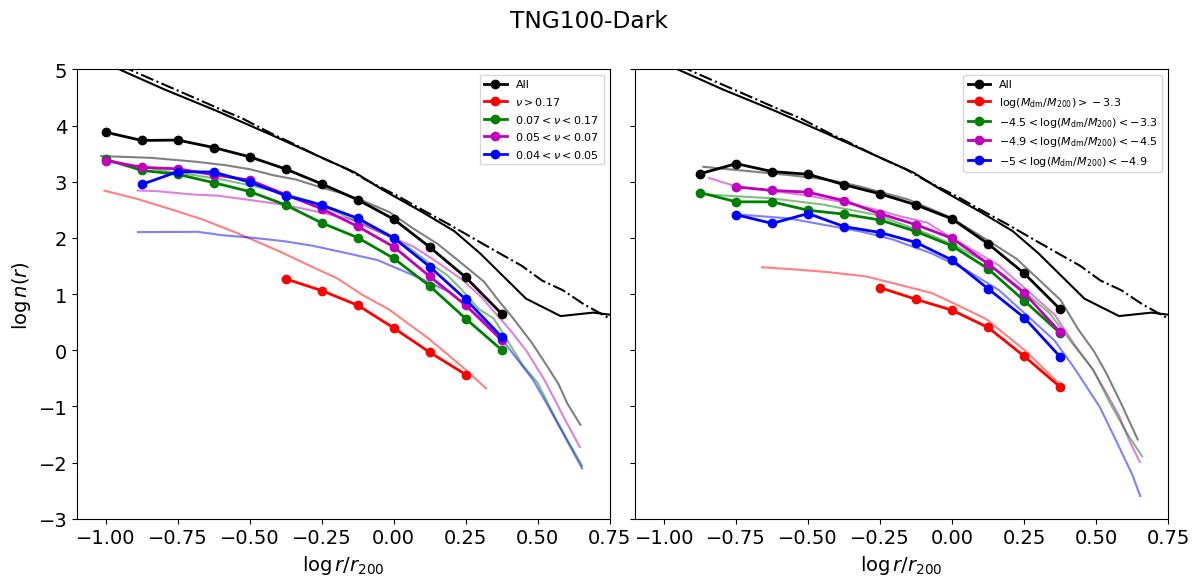

In [11]:
# This is to plot the radial distribution of the satellites without Type-2 satellites
print('This is to reproduce the Ludlow+09 plot trying with the radial bins')
h = 0.6744
G = 4.3e-6
fig, (ax, ax2) = plt.subplots(figsize = (12, 6), ncols = 2, sharey = True)

ax.plot(np.array(dm_dist_ldf[0]), np.array(dm_dist_ldf[1]), 'k-')
ax.plot(np.array(dm_einasto_ldf[0]), np.array(dm_einasto_ldf[1]), 'k-.')
ax.plot(np.array(v1_ldf[0]), np.array(v1_ldf[1]), 'k-', alpha = 0.5)
ax.plot(np.array(v2_ldf[0]), np.array(v2_ldf[1]), 'r-', alpha = 0.5)
ax.plot(np.array(v3_ldf[0]), np.array(v3_ldf[1]), 'g-', alpha = 0.5)
ax.plot(np.array(v4_ldf[0]), np.array(v4_ldf[1]), 'm-', alpha = 0.5)
ax.plot(np.array(v5_ldf[0]), np.array(v5_ldf[1]), 'b-', alpha = 0.5)

#That was just the plotting of digitized data. Let us now plot the stacked of TNG
rpl_stack = np.linspace(-1, 0.75, 15)
ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd1_rvir)

    psvrel = vmax_ifd1_ar / v200

    print(psvrel)

    rpl2d1 = np.logspace(1, np.log10(5 * fofd1_rvir), 50) # rpl2 for TNG100-1-Dark FoF11
    rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])
    d1n1_ar = np.zeros(0)
    d1n2_ar = np.zeros(0)
    d1n3_ar = np.zeros(0)
    d1n4_ar = np.zeros(0)
    d1n5_ar = np.zeros(0)
    d1n6_ar = np.zeros(0)
    

    for ix in range(len(rpl2d1) - 1):
        d1n1_ar = np.append(d1n1_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n2_ar = np.append(d1n2_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel > 0.17)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n3_ar = np.append(d1n3_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel < 0.17) & (psvrel > 0.07)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n4_ar = np.append(d1n4_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel < 0.07) & (psvrel > 0.05)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n5_ar = np.append(d1n5_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel < 0.05) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n6_ar = np.append(d1n6_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (psvrel < 0.04) & (psvrel > 0.03)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
    # print( rpl_interp[np.where(d1n1_ar != 0)[0]])
    norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(fofd1_rvir, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])

    print(norm_d1Ns2)
    ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n1_ar)))
    ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n2_ar)))
    ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n3_ar)))
    ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n4_ar)))
    ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n5_ar)))
    ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n6_ar)))
    # / len(lend1_ar[(vmax_ifd1_ar > 45) & (distd1_ar <  fofd1_rvir) & (lend1_ar > 100) & (fofno1_ar == fofno)])


ax.plot(rpl_stack , get_med_values(ndm_st1, 16), 'ko-',  label = r'All', lw  = 2)
ax.plot(rpl_stack , get_med_values(ndm_st2, 16), 'ro-',  label = r'$\nu > 0.17$', lw  = 2)
ax.plot(rpl_stack , get_med_values(ndm_st3, 16), 'go-',  label = r'$0.07 < \nu < 0.17$', lw  = 2)
ax.plot(rpl_stack , get_med_values(ndm_st4, 16), 'mo-',  label = r'$0.05 < \nu < 0.07$', lw  = 2)
ax.plot(rpl_stack , get_med_values(ndm_st5, 16), 'bo-',  label = r'$0.04 < \nu < 0.05$', lw  = 2)
# ax.plot(rpl_stack , get_med_values(ndm_st6, 16), 'o-', color = 'orange',  label = r'$0.04 < \nu < 0.05$', lw  = 2)
    
ax.legend(fontsize = 8)
# ax.axhline( np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))
ax.set_xlabel(r'$\log r/r_{200}$')
ax.set_ylabel(r'$\log n(r)$')
ax.set_ylim(-3, 5)
ax.set_xlim(-1.1, 0.75)


# ===========================================

ax2.plot(np.array(dm_dist_ldf[0]), np.array(dm_dist_ldf[1]), 'k-')
ax2.plot(np.array(dm_einasto_ldf[0]), np.array(dm_einasto_ldf[1]), 'k-.')
ax2.plot(np.array(m1_ldf[0]), np.array(m1_ldf[1]), 'k-', alpha = 0.5)
ax2.plot(np.array(m2_ldf[0]), np.array(m2_ldf[1]), 'm-', alpha = 0.5)
ax2.plot(np.array(m3_ldf[0]), np.array(m3_ldf[1]), 'g-', alpha = 0.5)
ax2.plot(np.array(m4_ldf[0]), np.array(m4_ldf[1]), 'b-', alpha = 0.5)
ax2.plot(np.array(m5_ldf[0]), np.array(m5_ldf[1]), 'r-', alpha = 0.5)

ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd1_rvir)

    lmrel = np.log10(massd1_ar / m200)

    rpl2d1 = np.logspace(1, np.log10(5 * fofd1_rvir), 50) # rpl2 for TNG100-1-Dark FoF11
    rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])
    d1n1_ar = np.zeros(0)
    d1n2_ar = np.zeros(0)
    d1n3_ar = np.zeros(0)
    d1n4_ar = np.zeros(0)
    d1n5_ar = np.zeros(0)
    d1n6_ar = np.zeros(0)
    

    for ix in range(len(rpl2d1) -1 ):
        d1n1_ar = np.append(d1n1_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel > -5)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n2_ar = np.append(d1n2_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel > -3.3)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3)/ 3.))
        d1n3_ar = np.append(d1n3_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel < -3.3) & (lmrel > -4.5)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n4_ar = np.append(d1n4_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel < -4.5) & (lmrel > -4.9)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n5_ar = np.append(d1n5_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel < -4.9) & (lmrel > -5)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        d1n6_ar = np.append(d1n6_ar, len(lend1_ar[(distd1_ar > rpl2d1[ix]) & (distd1_ar < rpl2d1[ix + 1]) & (fofno1_ar == fofno) & (lmrel < -5) & (lmrel > -5.5)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
        # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))

    norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(fofd1_rvir, rpl_interp, d1n1_ar)
    # * 4 * np.pi * fofd1_rvir ** 3 / (3  * len(lend1_ar[(distd1_ar < fofd1_rvir) & (fofno1_ar == fofno)]) )
    ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n1_ar)))
    ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n2_ar)))
    ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n3_ar)))
    ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n4_ar)))
    ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n5_ar)))
    ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp/fofd1_rvir), np.log10(norm_d1Ns2 *  d1n6_ar)))

ax2.plot(rpl_stack , get_med_values(ndm_st1, 16), 'ko-',  label = r'All', lw  = 2)
ax2.plot(rpl_stack , get_med_values(ndm_st2, 16), 'ro-',  label = r'$\log (M_{\rm{dm}} / M_{\rm{200}}) > -3.3$', lw  = 2)
ax2.plot(rpl_stack , get_med_values(ndm_st3, 16), 'go-',  label = r'$-4.5 < \log (M_{\rm{dm}} / M_{\rm{200}}) < -3.3$', lw  = 2)
ax2.plot(rpl_stack , get_med_values(ndm_st4, 16), 'mo-',  label = r'$-4.9 < \log (M_{\rm{dm}} / M_{\rm{200}}) < -4.5$', lw  = 2)
ax2.plot(rpl_stack , get_med_values(ndm_st5, 16), 'bo-',  label = r'$-5< \log (M_{\rm{dm}} / M_{\rm{200}}) < -4.9$', lw  = 2)
# ax2.plot(rpl_stack , get_med_values(ndm_st6, 16), 'o-', color = 'orange',  label = r'$-5.5< \log (M_{\rm{dm}} / M_{\rm{200}}) < -5$', lw  = 2)

ax2.legend(fontsize = 8)
ax2.set_xlabel(r'$\log r/r_{200}$')
# ax2.set_ylabel(r'$\log n(r)$')
ax2.set_ylim(-3, 5)
ax2.set_xlim(-1.1, 0.75)

plt.suptitle('TNG100-Dark')
plt.tight_layout()
plt.show()

In [108]:
def get_Ndm_t50d(fofno):
    '''
    This is to get the number of dark matter particles inside the radius np.logspace(1, np.log10(2 * fofd1_rvir), 100)
    '''
    if fofno == 0: Ndm = [486561, 547949, 617189, 695593, 784271, 882887, 991981, 1111128, 1241126, 1382035, 1534813, 1700998, 1882867, 2082258, 2300922, 2540983, 2805633, 3096997, 3416909, 3770116, 4155383, 4577231, 5037648, 5541264, 6084771, 6673446, 7314912, 8016754, 8768803, 9572741, 10435521, 11361528, 12365475, 13443467, 14606099, 15848378, 17174425, 18593620, 20083770, 21662073, 23358549, 25196167, 27183281, 29332062, 31644541, 34114049, 36728007, 39451137, 42262578, 45235623, 48437232, 51915782, 55668463, 59769143, 64107653, 68556520, 73086255, 77735963, 82475883, 87475277, 92772789, 98416931, 104439476, 110868640, 117663570, 124754035, 132129810, 139862712, 147594012, 155110622, 162880963, 171111763, 179758483, 188906353, 198672929, 208870229, 219665317, 230604563, 241005345, 250496948, 259567421, 268505116, 277988576, 288051818, 299325746, 311735773, 325017614, 339650845, 355089640, 370709959, 386338471, 401172374, 415374133, 428785970, 442196096, 456442839, 471166290, 485402955, 497696704, 509761382]
    elif fofno == 1: Ndm = [408737, 448579, 491981, 539187, 590733, 647527, 709723, 778002, 852108, 932868, 1021220, 1116873, 1221576, 1335744, 1458686, 1591158, 1733994, 1887970, 2053311, 2230387, 2421689, 2627007, 2846668, 3083089, 3336922, 3610652, 3903564, 4218298, 4555759, 4917265, 5305443, 5722597, 6171259, 6651846, 7168055, 7720654, 8310999, 8946628, 9626140, 10348913, 11117639, 11938405, 12816008, 13732120, 14697103, 15717932, 16799720, 17948026, 19183025, 20537371, 21957986, 23387586, 24878017, 26461385, 28154830, 29947158, 31825892, 33813433, 35988338, 38269006, 40661457, 43301954, 46076566, 49120778, 52583668, 56254949, 59940163, 63773138, 67831860, 72187011, 76681716, 81464561, 86465515, 91702727, 96994698, 102729322, 108828955, 115074531, 120975724, 127049636, 133370863, 139394399, 145496253, 151757554, 158461354, 165138625, 173003891, 180063513, 186151234, 192117866, 197631162, 202957764, 208267738, 213150519, 218005971, 222931198, 227575343, 231597093, 235068175, 237884591]
    elif fofno ==2: Ndm = [308289, 337556, 369318, 404299, 442780, 485386, 531341, 582473, 638610, 700000, 767376, 840876, 921797, 1010312, 1107502, 1213099, 1328032, 1453064, 1590359, 1739315, 1901123, 2077509, 2269537, 2477349, 2702028, 2945330, 3206909, 3488166, 3791975, 4118505, 4469209, 4845975, 5249421, 5679766, 6142637, 6637597, 7165307, 7726961, 8320910, 8956674, 9632879, 10354103, 11124678, 11953319, 12830862, 13764673, 14764652, 15819754, 16944029, 18119072, 19355087, 20670860, 22061516, 23511914, 24998527, 26531132, 28149639, 29854128, 31654212, 33538803, 35545841, 37716292, 39937010, 42189439, 44552217, 47003320, 49478027, 51967311, 54512336, 57238991, 60121929, 63090943, 66137068, 69417638, 72939016, 76596502, 80475205, 84221537, 88090995, 91911736, 95782609, 99614014, 103605537, 107812157, 112335196, 116531504, 120585512, 124831809, 129335255, 133941546, 137828621, 141808273, 145827449, 149587603, 153537188, 157575432, 161699327, 166548982, 172136072, 177690447]


    return Ndm

In [109]:
print('This is to create a stacked array of the DM profile')
# First, let us go over all the FoFs and at the same r/r200 values, let us create a massive array and then use 

rbr200_ar = np.logspace(np.log10(0.05), np.log10(2), 20) # Taking 20 points in between 0.05 and 1
Ndm_big_ar = np.zeros(0) #The plan is to use interpolation to get values for all the FoFs into this array

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(t50dbasePath, 99, haloID = fofno)
    fofd5_pos = this_fof['GroupPos']/h
    fofd5_rvir = this_fof['Group_R_Crit200']/h
    distd5_ar = np.sqrt((posxd5_ar)**2 + (posyd5_ar)**2 + (poszd5_ar)**2)


    rplndm = np.logspace(1, np.log10(2 * fofd1_rvir), 100)
    Ndm_ar = get_Ndm_t50d(fofno)
    Nvir = np.interp(0.4 * fofd1_rvir, rplndm, Ndm_ar)

    
        
    Ndm_big_ar = np.append(Ndm_big_ar, np.interp(rbr200_ar, rplndm/fofd1_rvir, (np.array(Ndm_ar)/(4 * np.pi * rplndm**3 / 3.)) / (Nvir / (4 * np.pi * 0.4 **3 * fofd1_rvir**3 / 3.))))

Ndm_stacked5 = get_med_values(Ndm_big_ar, 3) #This function will give us the stacked median array

This is to create a stacked array of the DM profile


In [110]:
print('This is to create a stacked array of the DM profile -- differential density')
# First, let us go over all the FoFs and at the same r/r200 values, let us create a massive array and then use 

rbr200_ar = np.logspace(np.log10(0.05), np.log10(2), 20) # Taking 20 points in between 0.05 and 1
ndm_big_ar = np.zeros(0) #The plan is to use interpolation to get values for all the FoFs into this array

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd5_pos = this_fof['GroupPos']/h
    fofd5_rvir = this_fof['Group_R_Crit200']/h
    distd5_ar = np.sqrt((posxd5_ar)**2 + (posyd5_ar)**2 + (poszd5_ar)**2)


    rplndm = np.logspace(1, np.log10(2 * fofd5_rvir), 100)
    rpl_diff = np.array([(rplndm[ix] + rplndm[ix + 1])/2. for ix in range(len(rplndm) - 1)]) #These are the radii corresponding to differential 
    vol_diff = np.array([(4/3.) * np.pi * (rplndm[ix + 1]**3 - rplndm[ix] ** 3) for ix in range(len(rplndm) - 1)]) #These are the valumes corresponding to differential 
    
    Ndm_ar5 = get_Ndm_t50d(fofno)
    ndm_ar5 = np.diff(Ndm_ar5) / vol_diff
    
    nvir = np.interp(fofd5_rvir, rpl_diff, ndm_ar5) #This will give the value of differential density at 0.4 rvir

    
        
    ndm_big_ar = np.append(ndm_big_ar, np.interp(rbr200_ar, rpl_diff/fofd1_rvir, ndm_ar5/nvir))

ndm_stacked5 = get_med_values(ndm_big_ar, 3) #This function will give us the stacked median array

This is to create a stacked array of the DM profile -- differential density


In [111]:
def get_Ndm(fofno):
    '''
    This is to get the number of DM particles inside the radius of np.logspace(1, np.log10(2 * fofd1_rvir), 100) based on the code that we have data_extractors/
    '''
    if fofno == 0: Ndm =  [22979, 25579, 28557, 31794, 35342, 39322, 43682, 48415, 53553, 59384, 65906, 73177, 81157, 89969, 99677, 110357, 121973, 134845, 149128, 164780, 182296, 201527, 223147, 247203, 274020, 304208, 337702, 374285, 414205, 457909, 505849, 559157, 617694, 681397, 750960, 826814, 910721, 1004120, 1106977, 1220323, 1344104, 1479875, 1628294, 1792357, 1969190, 2158636, 2364441, 2587001, 2829024, 3094268, 3387817, 3701854, 4026102, 4370830, 4741459, 5140878, 5568484, 6025913, 6517855, 7033541, 7591960, 8189135, 8832368, 9493373, 10189713, 10881339, 11605416, 12371214, 13163380, 14002785, 14905353, 15893436, 16909684, 17933823, 19004481, 20135795, 21335330, 22670417, 24140910, 25781586, 27469020, 29243944, 30845809, 32448222, 34128225, 36001874, 38355215, 40615479, 42552875, 44353654, 45928955, 47222919, 48571630, 50177646, 51646024, 52877857, 54040682, 54981199, 55803166, 56627756]
    if fofno == 1: Ndm =  [23616, 26263, 29058, 32288, 35855, 39615, 43952, 48709, 53883, 59610, 66028, 73112, 80656, 88988, 98066, 108233, 119391, 131652, 145162, 159898, 175987, 193835, 213074, 233655, 256739, 281537, 309050, 339178, 371826, 407638, 446699, 488739, 534130, 584522, 638534, 696096, 758279, 824898, 897286, 975732, 1060111, 1151645, 1249657, 1355373, 1468365, 1590306, 1720417, 1859456, 2010378, 2171278, 2345197, 2528060, 2724067, 2930257, 3146836, 3380055, 3630183, 3901668, 4203469, 4512055, 4842031, 5194157, 5572335, 5970783, 6392564, 6845368, 7335464, 7876080, 8460418, 9117857, 9849535, 10690325, 11565611, 12558106, 13724524, 15071385, 16541728, 18177526, 20053701, 21939096, 23947904, 25949257, 27966216, 30145386, 32507111, 34780857, 37018762, 39231526, 41505112, 43582106, 45613297, 47963365, 50353419, 52748920, 54903310, 56267740, 56933573, 57243272, 57364004, 57544601]
    if fofno == 2: Ndm =  [23448, 26153, 29002, 32218, 35813, 39680, 44112, 48910, 54224, 60057, 66540, 73717, 81580, 90223, 99963, 110537, 122234, 135223, 149639, 165318, 182834, 202394, 223597, 247339, 273768, 302670, 334335, 369304, 407622, 450359, 496966, 547679, 603198, 663753, 729522, 801826, 880008, 964832, 1055593, 1153483, 1258488, 1371340, 1493187, 1622941, 1761880, 1909595, 2066167, 2233261, 2413044, 2604784, 2812154, 3031883, 3262988, 3509547, 3774178, 4059322, 4364841, 4694726, 5051910, 5423957, 5805715, 6192916, 6595377, 7013032, 7453301, 7905659, 8381366, 8892729, 9424048, 9972984, 10529321, 11115736, 11779391, 12483974, 13197891, 13913519, 14627493, 15311901, 16015527, 16772803, 17611559, 18475741, 19384227, 20343303, 21311719, 22413516, 23748952, 25070104, 26155152, 26970398, 27506071, 27929766, 28342281, 28656701, 28995655, 29176838, 29312329, 29515475, 29586861, 29646094]
    if fofno == 3: Ndm =  [23190, 25777, 28594, 31634, 34996, 38813, 43069, 47591, 52574, 58240, 64693, 71753, 79642, 88507, 98495, 109473, 121575, 135166, 150330, 167056, 185679, 206119, 228879, 253922, 281789, 312383, 345988, 383338, 424566, 469706, 518895, 572626, 631170, 694396, 763646, 839622, 922127, 1011760, 1109060, 1213479, 1326254, 1447659, 1577465, 1714730, 1862238, 2016568, 2179830, 2354985, 2543890, 2745545, 2962672, 3196051, 3450569, 3717258, 4004125, 4312945, 4646531, 5000995, 5392022, 5826570, 6285034, 6765153, 7284857, 7856075, 8463128, 9133602, 9843749, 10628353, 11491482, 12367847, 13293335, 14240388, 15245768, 16360494, 17512094, 18689548, 20006155, 21384135, 22749785, 24127929, 25594329, 27275788, 28951987, 30480108, 31975275, 33501869, 35048469, 36694974, 38434318, 39911621, 41197476, 42044371, 42799223, 43371739, 43951683, 44364936, 44843571, 45238928, 45651824, 46016593]
    if fofno == 4: Ndm =  [25668, 28513, 31654, 35059, 38877, 43094, 47686, 52966, 58706, 65072, 72154, 79819, 88359, 97989, 108622, 120066, 133102, 147196, 162662, 179523, 198379, 218719, 240826, 264733, 290760, 319170, 350478, 384071, 420641, 460842, 504126, 550795, 601356, 655593, 713923, 776029, 842487, 915123, 993306, 1078118, 1168426, 1261887, 1359738, 1462321, 1570664, 1686562, 1811543, 1945705, 2091029, 2246412, 2412432, 2590252, 2778369, 2978127, 3188650, 3410664, 3645144, 3891742, 4146979, 4419395, 4708143, 5023609, 5358536, 5704828, 6070529, 6447833, 6840462, 7246876, 7681054, 8134981, 8606427, 9089260, 9568814, 10058468, 10568825, 11124365, 11743889, 12344286, 12928763, 13515519, 14132875, 14771908, 15421301, 16129524, 16861803, 17539233, 18176740, 18802920, 19442064, 20116066, 20790305, 21567527, 22377575, 23249918, 24488233, 25972559, 27370986, 28674016, 30061288, 32225454]
    if fofno == 5: Ndm =  [29707, 32748, 35978, 39634, 43594, 48050, 52780, 58047, 63720, 70059, 76959, 84491, 92786, 101734, 111465, 122090, 133809, 146686, 160588, 175657, 191909, 209725, 229316, 250401, 273076, 298116, 325106, 353991, 385623, 419845, 456746, 496310, 539292, 585091, 634421, 688038, 745650, 807308, 874457, 946775, 1025773, 1110969, 1202569, 1300082, 1405665, 1518942, 1639778, 1768387, 1904742, 2050969, 2207552, 2376574, 2557817, 2753946, 2966147, 3191906, 3438260, 3699380, 3978859, 4280485, 4603657, 4948884, 5322742, 5725930, 6169114, 6680384, 7225115, 7791008, 8408417, 9095481, 9758467, 10421323, 11089539, 11798526, 12588361, 13337833, 14059579, 14808006, 15611445, 16478473, 17364048, 18208929, 18993370, 19768449, 20511957, 21218661, 21952452, 22718989, 23396077, 24060220, 24689691, 25248322, 25781493, 26382503, 26857136, 27443331, 27879212, 28388996, 28878676, 29220818]
    if fofno == 6: Ndm =  [21201, 23699, 26488, 29581, 32982, 36594, 40706, 45127, 50227, 55789, 61950, 68711, 76103, 84304, 93342, 103266, 113923, 125811, 138707, 153127, 168495, 185307, 203687, 223464, 244803, 267848, 293081, 319829, 348573, 379493, 413036, 448901, 487617, 529233, 574041, 622347, 674699, 731806, 793572, 859955, 932103, 1010497, 1095635, 1188453, 1289536, 1399990, 1518908, 1646567, 1784411, 1935754, 2097606, 2271301, 2458811, 2661378, 2884286, 3121749, 3369797, 3636433, 3927861, 4251911, 4609556, 4984101, 5377783, 5809869, 6293058, 6857917, 7571252, 8275542, 8930844, 9573361, 10234171, 10907024, 11579151, 12220777, 12875287, 13512673, 14176006, 14873145, 15612979, 16312265, 17023657, 17801770, 18658057, 19718115, 20622679, 21327463, 21923163, 22457867, 22950054, 23328292, 23631116, 23837407, 24030738, 24135105, 24189728, 24225056, 24247735, 24249692, 24249696, 24249696]
    if fofno == 7: Ndm =  [27033, 30100, 33441, 37091, 41118, 45615, 50573, 56157, 62347, 69198, 76729, 85034, 94363, 104501, 115647, 128068, 141792, 156583, 173112, 191112, 211231, 232933, 256656, 282914, 311458, 342360, 376353, 413716, 454502, 498884, 547362, 599685, 656514, 717718, 783226, 853768, 930694, 1012570, 1100191, 1193665, 1293307, 1400090, 1513623, 1633983, 1763043, 1900991, 2049080, 2208530, 2379765, 2563114, 2758535, 2971666, 3198649, 3431560, 3674031, 3929965, 4202118, 4489452, 4796872, 5126471, 5481228, 5861441, 6263566, 6689627, 7137288, 7612718, 8117030, 8658280, 9267954, 9939036, 10604588, 11276291, 11952164, 12659243, 13428208, 14225609, 14968840, 15706565, 16437595, 17200285, 17919219, 18599020, 19279646, 19969493, 20743607, 21556329, 22445563, 23254412, 23977474, 24616089, 25224833, 25762367, 26217254, 26619836, 26998626, 27401221, 27942277, 28937974, 29983742, 30633566]
    if fofno == 8: Ndm =  [22357, 24837, 27605, 30587, 33795, 37456, 41288, 45605, 50171, 55345, 61141, 67211, 73987, 81347, 89442, 98171, 107785, 118193, 129466, 141832, 155314, 169859, 185738, 202678, 221224, 241165, 262462, 285240, 309753, 336242, 364237, 394223, 426287, 460784, 497861, 537758, 580315, 625951, 675160, 728913, 786678, 848751, 915877, 988104, 1064592, 1145804, 1232287, 1324377, 1421217, 1523681, 1630865, 1745227, 1863565, 1986253, 2113413, 2244639, 2379239, 2517247, 2656759, 2801422, 2952399, 3106580, 3262299, 3421638, 3585075, 3752968, 3935007, 4125434, 4318936, 4513387, 4717073, 4929187, 5152758, 5396958, 5655829, 5930642, 6234252, 6537265, 6813791, 7100554, 7409485, 7752179, 8131682, 8508062, 8863578, 9208459, 9604859, 9969570, 10295938, 10604143, 10926519, 11256820, 11603584, 12066129, 12604270, 13289737, 14012645, 14659332, 15307856, 16032442]
    if fofno == 9: Ndm =  [21295, 23688, 26395, 29294, 32578, 36221, 40372, 44993, 50151, 55682, 62020, 68959, 76494, 84939, 94397, 104681, 116166, 128691, 142420, 157404, 173821, 191602, 211457, 233067, 256487, 282342, 310655, 341233, 374874, 411469, 451439, 495574, 543437, 595204, 651361, 711863, 777528, 847860, 924212, 1006229, 1094653, 1190096, 1292850, 1403322, 1523488, 1652661, 1793803, 1944669, 2106620, 2280477, 2467614, 2666111, 2882665, 3113318, 3355383, 3609159, 3873647, 4146132, 4436007, 4740655, 5057847, 5401062, 5762270, 6147494, 6561101, 7000828, 7466181, 7953904, 8485376, 9061637, 9712130, 10476770, 11238059, 12006510, 12752489, 13443410, 14095655, 14750081, 15405231, 16095882, 16801475, 17599706, 18580742, 19745963, 20885718, 22024675, 23127007, 24144620, 25168931, 26082828, 26743982, 27293033, 27836515, 28381147, 28769029, 29176641, 29586976, 29934506, 30086349, 30252626]
    if fofno == 10: Ndm =  [26584, 29689, 33164, 36899, 41072, 45665, 50885, 56789, 63141, 70308, 78010, 86568, 96255, 106868, 118501, 130967, 144755, 159999, 176493, 194728, 214457, 235985, 259410, 284890, 312494, 342314, 375092, 410410, 449206, 491133, 536379, 585604, 638882, 695757, 756608, 822387, 892482, 966599, 1044637, 1126923, 1214172, 1306321, 1403007, 1505353, 1613264, 1728668, 1851442, 1983689, 2126247, 2281404, 2448004, 2624147, 2810062, 3004859, 3210161, 3423225, 3645184, 3880570, 4131053, 4396795, 4672456, 4959680, 5262013, 5579332, 5920816, 6278693, 6655058, 7077438, 7564511, 8040016, 8521307, 9002295, 9491366, 10003247, 10537838, 11077791, 11650847, 12226238, 12823585, 13459482, 14098780, 14714497, 15333814, 15896265, 16465873, 16982634, 17502285, 17992971, 18526959, 19020055, 19544316, 20032321, 20485319, 21030740, 21726542, 22287866, 22876025, 23578038, 24277818, 24654755]
    if fofno == 11: Ndm =  [19438, 21330, 23455, 25709, 28224, 30947, 33813, 37003, 40421, 44188, 48177, 52510, 57173, 62196, 67660, 73555, 79926, 86689, 94057, 101832, 110294, 119238, 128848, 139186, 150298, 162360, 175268, 189244, 204268, 220424, 237579, 255871, 275403, 296356, 318322, 341647, 365966, 392020, 419555, 448696, 479313, 511652, 545832, 582451, 621887, 663608, 707824, 755405, 806246, 859770, 915519, 974281, 1036088, 1100922, 1170126, 1243873, 1320299, 1402816, 1492258, 1589327, 1694959, 1809502, 1931290, 2065481, 2222213, 2396920, 2574837, 2759571, 2962085, 3175955, 3386896, 3609566, 3852578, 4117166, 4394713, 4689486, 5020522, 5413235, 5899324, 6370072, 6831925, 7289273, 7700617, 8091958, 8503931, 8930587, 9350102, 9801130, 10295940, 10916177, 11460829, 12049419, 12863383, 13868493, 14716984, 15513197, 16411965, 17462610, 18326694, 18925881]
    if fofno == 12: Ndm =  [15352, 16778, 18361, 20020, 21859, 23917, 26079, 28379, 30875, 33665, 36614, 39907, 43587, 47595, 51864, 56554, 61799, 67345, 73322, 79909, 86801, 94261, 102357, 111142, 120473, 130347, 141164, 152918, 165687, 179307, 194425, 210598, 228101, 247851, 269947, 294120, 321319, 351704, 385632, 423166, 462931, 504382, 547735, 593526, 641601, 692842, 747122, 804171, 864245, 928850, 996990, 1069480, 1145665, 1225297, 1307666, 1393084, 1481700, 1573309, 1669315, 1768598, 1873067, 1975535, 2078215, 2188094, 2306061, 2434461, 2568605, 2711906, 2871068, 3042289, 3236419, 3430300, 3641995, 3857212, 4082612, 4325464, 4572980, 4807368, 5039683, 5276994, 5490628, 5693562, 5874626, 6041880, 6212608, 6377296, 6535662, 6676415, 6822803, 6979455, 7097351, 7213223, 7328551, 7437115, 7522301, 7594702, 7692871, 7826215, 8087568, 8432873]
    if fofno == 13: Ndm =  [24489, 27071, 29922, 33091, 36645, 40544, 44795, 49453, 54356, 59878, 65881, 72512, 79640, 87402, 95892, 105066, 114927, 125335, 136980, 149473, 163187, 178131, 194205, 211206, 229702, 249352, 270586, 293631, 318776, 345807, 374623, 405377, 438748, 474934, 513754, 555297, 599790, 647674, 698656, 753680, 812298, 874612, 941062, 1011858, 1085774, 1162544, 1243238, 1328581, 1418762, 1512836, 1613731, 1723440, 1845877, 1981547, 2120287, 2261953, 2411296, 2571630, 2746344, 2934853, 3133161, 3343348, 3567936, 3803586, 4051163, 4308641, 4576960, 4864034, 5164270, 5466848, 5784775, 6117820, 6474446, 6826284, 7179259, 7547942, 7944198, 8330873, 8714956, 9118734, 9512729, 9952704, 10392556, 10805285, 11182347, 11546609, 11864430, 12140016, 12352824, 12543597, 12796948, 12950327, 13073469, 13207075, 13286804, 13350299, 13428320, 13478073, 13501921, 13517556]
    if fofno == 14: Ndm =  [18808, 20852, 22945, 25346, 27941, 30758, 33833, 37056, 40608, 44550, 48959, 53706, 58832, 64280, 70133, 76522, 83485, 90989, 98865, 107655, 117140, 127101, 138153, 149947, 162561, 176120, 190648, 206229, 223036, 240947, 259981, 280270, 301481, 324344, 348578, 374477, 402658, 432260, 462990, 495333, 529628, 566563, 606363, 648957, 694006, 742062, 792845, 846059, 902300, 961063, 1023096, 1088658, 1158353, 1229719, 1304534, 1381356, 1460200, 1541036, 1624773, 1712784, 1807216, 1905552, 2006797, 2111168, 2222894, 2344501, 2476947, 2612033, 2749885, 2892440, 3048449, 3233671, 3429010, 3655197, 3943845, 4213757, 4462285, 4703998, 4957839, 5227627, 5504115, 5768205, 6046399, 6347671, 6708436, 7018627, 7289278, 7532879, 7761361, 7958493, 8144353, 8308882, 8461155, 8593613, 8699094, 8792233, 8945001, 9039961, 9104861, 9151157]
    if fofno == 15: Ndm =  [35915, 39487, 43404, 47503, 52214, 57222, 62890, 68735, 75161, 82212, 89814, 98125, 107131, 116828, 127453, 138799, 151155, 164388, 178674, 194095, 210803, 228766, 248145, 269137, 291556, 315719, 341578, 369345, 399290, 430928, 465138, 501949, 541256, 583829, 628971, 677217, 728838, 784138, 842919, 906198, 974166, 1048423, 1128045, 1212139, 1301587, 1396368, 1496589, 1601574, 1712420, 1829406, 1953448, 2084398, 2222580, 2367827, 2522118, 2684042, 2854029, 3029348, 3211018, 3401039, 3601106, 3808747, 4021612, 4241668, 4467529, 4701918, 4946012, 5205962, 5474964, 5756254, 6047813, 6343862, 6665114, 6998426, 7338784, 7703682, 8060472, 8429117, 8815940, 9216866, 9628292, 10046667, 10463207, 10894994, 11376629, 11898463, 12391002, 12909498, 13392045, 13778584, 14107108, 14406798, 14673147, 14895747, 15089842, 15234741, 15351865, 15435884, 15514940, 15617179]
    return Ndm

In [112]:
print('This is to create a stacked array of the DM profile')
# First, let us go over all the FoFs and at the same r/r200 values, let us create a massive array and then use 

rbr200_ar = np.logspace(np.log10(0.05), np.log10(2), 20) # Taking 20 points in between 0.05 and 1
Ndm_big_ar = np.zeros(0) #The plan is to use interpolation to get values for all the FoFs into this array

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    distd1_ar = np.sqrt((posxd1_ar)**2 + (posyd1_ar)**2 + (poszd1_ar)**2)


    rplndm = np.logspace(1, np.log10(2 * fofd1_rvir), 100)
    Ndm_ar = get_Ndm(fofno)
    Nvir = np.interp(0.4 * fofd1_rvir, rplndm, Ndm_ar)

    
        
    Ndm_big_ar = np.append(Ndm_big_ar, np.interp(rbr200_ar, rplndm/fofd1_rvir, (np.array(Ndm_ar)/(4 * np.pi * rplndm**3 / 3.)) / (Nvir / (4 * np.pi * 0.4 **3 * fofd1_rvir**3 / 3.))))

Ndm_stacked = get_med_values(Ndm_big_ar, 16) #This function will give us the stacked median array

This is to create a stacked array of the DM profile


In [113]:
print('This is to create a stacked array of the DM profile -- differential density')
# First, let us go over all the FoFs and at the same r/r200 values, let us create a massive array and then use 

rbr200_ar = np.logspace(np.log10(0.05), np.log10(2), 20) # Taking 20 points in between 0.05 and 1
ndm_big_ar = np.zeros(0) #The plan is to use interpolation to get values for all the FoFs into this array

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    distd1_ar = np.sqrt((posxd1_ar)**2 + (posyd1_ar)**2 + (poszd1_ar)**2)


    rplndm = np.logspace(1, np.log10(2 * fofd1_rvir), 100)
    rpl_diff = np.array([(rplndm[ix] + rplndm[ix + 1])/2. for ix in range(len(rplndm) - 1)]) #These are the radii corresponding to differential 
    vol_diff = np.array([(4/3.) * np.pi * (rplndm[ix + 1]**3 - rplndm[ix] ** 3) for ix in range(len(rplndm) - 1)]) #These are the valumes corresponding to differential 
    
    Ndm_ar = get_Ndm(fofno)
    ndm_ar = np.diff(Ndm_ar) / vol_diff
    
    nvir = np.interp(0.4 * fofd1_rvir, rpl_diff, ndm_ar) #This will give the value of differential density at 0.4 rvir

    
        
    ndm_big_ar = np.append(ndm_big_ar, np.interp(rbr200_ar, rpl_diff/fofd1_rvir, ndm_ar/nvir))

ndm_stacked = get_med_values(ndm_big_ar, 16) #This function will give us the stacked median array

This is to create a stacked array of the DM profile -- differential density


This is to reproduce the Ludlow+09 plot trying with the radial bins -- with Type-2 satellites (only the left subplot)
/tmp/ipykernel_3355332/2534868419.py:65: RuntimeWarning: divide by zero encountered in log10
  ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))

/tmp/ipykernel_3355332/2534868419.py:66: RuntimeWarning: divide by zero encountered in log10
  ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))

/tmp/ipykernel_3355332/2534868419.py:67: RuntimeWarning: divide by zero encountered in log10
  ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))

/tmp/ipykernel_3355332/2534868419.py:68: RuntimeWarning: divide by zero encountered in log10
  ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))

/tmp/ipykernel_3355332/2534868419.py:69: RuntimeWarning: divide by zero en

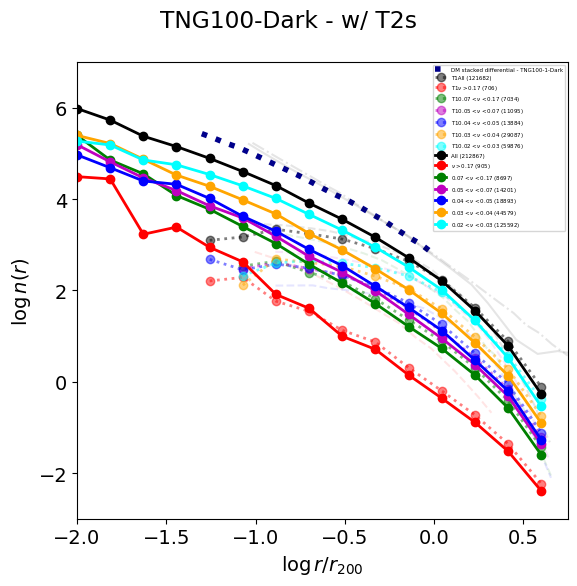

In [21]:
print('This is to reproduce the Ludlow+09 plot trying with the radial bins -- with Type-2 satellites (only the left subplot)')
fig, ax = plt.subplots(figsize = (6, 6), ncols = 1)


ax.plot(np.log10(rbr200_ar), np.log10(ndm_stacked * np.interp(1 , 10**np.array(dm_dist_ldf[0]), 10**np.array(dm_dist_ldf[1])) /  np.interp(1, rbr200_ar, ndm_stacked)  ) , color = 'darkblue', ls = ':', label = 'DM stacked differential - TNG100-1-Dark', lw = 4)
alpha = 0.1
ax.plot(np.array(dm_dist_ldf[0]), np.array(dm_dist_ldf[1]), 'k-', alpha = alpha)
ax.plot(np.array(dm_einasto_ldf[0]), np.array(dm_einasto_ldf[1]), 'k-.', alpha = alpha)
ax.plot(np.array(v1_ldf[0]), np.array(v1_ldf[1]), 'k--', alpha = alpha)
ax.plot(np.array(v2_ldf[0]), np.array(v2_ldf[1]), 'r--', alpha = alpha)
ax.plot(np.array(v3_ldf[0]), np.array(v3_ldf[1]), 'g--', alpha = alpha)
ax.plot(np.array(v4_ldf[0]), np.array(v4_ldf[1]), 'm--', alpha = alpha)
ax.plot(np.array(v5_ldf[0]), np.array(v5_ldf[1]), 'b--', alpha = alpha)

#That was just the plotting of digitized data. Let us now plot the stacked of TNG
rpl_stack = np.linspace(-2, 0.6, 15)
ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)
ndm_st7 = np.zeros(0)

psvrel = np.zeros(len(vmax_ifd1_ar))
t1t2_vrel = np.zeros(len(t1t2_vmax_if))

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd1_rvir)

    psvrel[fofno1_ar == fofno] = vmax_ifd1_ar[fofno1_ar == fofno] / v200
    t1t2_vrel[t1t2_fof == fofno] = t1t2_vmax_if[t1t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    psrrel = distd1_ar / fofd1_rvir
    t1t2_rrel = t1t2_dist / fofd1_rvir

rpl2d1 = np.logspace(-2, np.log10(5), 50) # rpl2 for TNG100-1-Dark FoF11
rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])
d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.02)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n2_ar = np.append(d1n2_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.02)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])

# print(norm_d1Ns2)
ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))
ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))
ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))
ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))
ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n5_ar)))
ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n6_ar)))
ndm_st7 = np.append(ndm_st7, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n7_ar)))
    # / len(lend1_ar[(vmax_ifd1_ar > 45) & (distd1_ar <  fofd1_rvir) & (lend1_ar > 100) & (fofno1_ar == fofno)])

alpha = 0.5
ax.plot(rpl_stack , ndm_st1, 'ko:',  label = r'T1All (' + str(len(lend1_ar[(psvrel > 0.02)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st2, 'ro:',  label = r'T1$\nu > 0.17$ (' + str(len(lend1_ar[(psvrel > 0.17)]) ) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st3, 'go:',  label = r'T1$0.07 < \nu < 0.17$ (' + str(len(lend1_ar[(psvrel < 0.17) & (psvrel > 0.07)]))  + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st4, 'mo:',  label = r'T1$0.05 < \nu < 0.07$ ('+ str(len(lend1_ar[(psvrel < 0.07) & (psvrel > 0.05)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st5, 'bo:',  label = r'T1$0.04 < \nu < 0.05$ ('+ str(len(lend1_ar[(psvrel < 0.05) & (psvrel > 0.04)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st6, 'o:', color = 'orange',  label = r'T1$0.03 < \nu < 0.04$ (' + str(len(lend1_ar[(psvrel < 0.04) & (psvrel > 0.03)])) + ')' , lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st7, 'o:', color = 'cyan',  label = r'$T10.02 < \nu < 0.03$ (' + str(len(lend1_ar[(psvrel < 0.03) & (psvrel > 0.02)])) + ')' , lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , get_med_values(ndm_st7, 16), 'o-', color = 'orange',  label = r'$0.03 < \nu < 0.04$', lw  = 2)

# The following is for including Type-2s in the simulation

ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)
ndm_st7 = np.zeros(0)

d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.02)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.02)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))

    d1n2_ar = np.append(d1n2_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.17)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))

    d1n3_ar = np.append(d1n3_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.07) & (t1t2_vrel < 0.17)]) ) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.05) & (t1t2_vrel < 0.07)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.04) & (t1t2_vrel < 0.05)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.03) & (t1t2_vrel < 0.04)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.02)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.02) & (t1t2_vrel < 0.03)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])

# print(norm_d1Ns2)
ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))
ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))
ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))
ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))
ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n5_ar)))
ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n6_ar)))
ndm_st7 = np.append(ndm_st7, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n7_ar)))
# / len(lend1_ar[(vmax_ifd1_ar > 45) & (distd1_ar <  fofd1_rvir) & (lend1_ar > 100) & (fofno1_ar == fofno)])

alpha = 1
ax.plot(rpl_stack , ndm_st1, 'ko-',  label = r'All (' + str(len(lend1_ar[(psvrel > 0.02)]) + len(t1t2_vrel[(t1t2_vrel > 0.02)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st2, 'ro-',  label = r'$\nu > 0.17$ (' + str(len(lend1_ar[(psvrel > 0.17)]) + len(t1t2_vrel[(t1t2_vrel > 0.17)]) ) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st3, 'go-',  label = r'$0.07 < \nu < 0.17$ (' + str(len(lend1_ar[(psvrel < 0.17) & (psvrel > 0.07)]) + len(t1t2_vrel[(t1t2_vrel < 0.17) & (t1t2_vrel > 0.07)]))  + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st4, 'mo-',  label = r'$0.05 < \nu < 0.07$ ('+ str(len(lend1_ar[(psvrel < 0.07) & (psvrel > 0.05)]) + len(t1t2_vrel[(t1t2_vrel < 0.07) & (t1t2_vrel > 0.05)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st5, 'bo-',  label = r'$0.04 < \nu < 0.05$ ('+ str(len(lend1_ar[(psvrel < 0.05) & (psvrel > 0.04)]) + len(t1t2_vrel[(t1t2_vrel < 0.05) & (t1t2_vrel > 0.04)])) + ')', lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st6, 'o-', color = 'orange',  label = r'$0.03 < \nu < 0.04$ (' + str(len(lend1_ar[(psvrel < 0.04) & (psvrel > 0.03)]) + len(t1t2_vrel[(t1t2_vrel < 0.04) & (t1t2_vrel > 0.03)])) + ')' , lw  = 2, alpha = alpha)
ax.plot(rpl_stack , ndm_st7, 'o-', color = 'cyan',  label = r'$0.02 < \nu < 0.03$ (' + str(len(lend1_ar[(psvrel < 0.03) & (psvrel > 0.02)]) + len(t1t2_vrel[(t1t2_vrel < 0.03) & (t1t2_vrel > 0.02)])) + ')' , lw  = 2, alpha = alpha)



    
ax.legend(fontsize = 4)
# ax.axhline( np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))
ax.set_xlabel(r'$\log r/r_{200}$')
ax.set_ylabel(r'$\log n(r)$')
ax.set_ylim(-3, 7)
ax.set_xlim(-2, 0.75)



plt.suptitle('TNG100-Dark - w/ T2s')
plt.tight_layout()
plt.show()

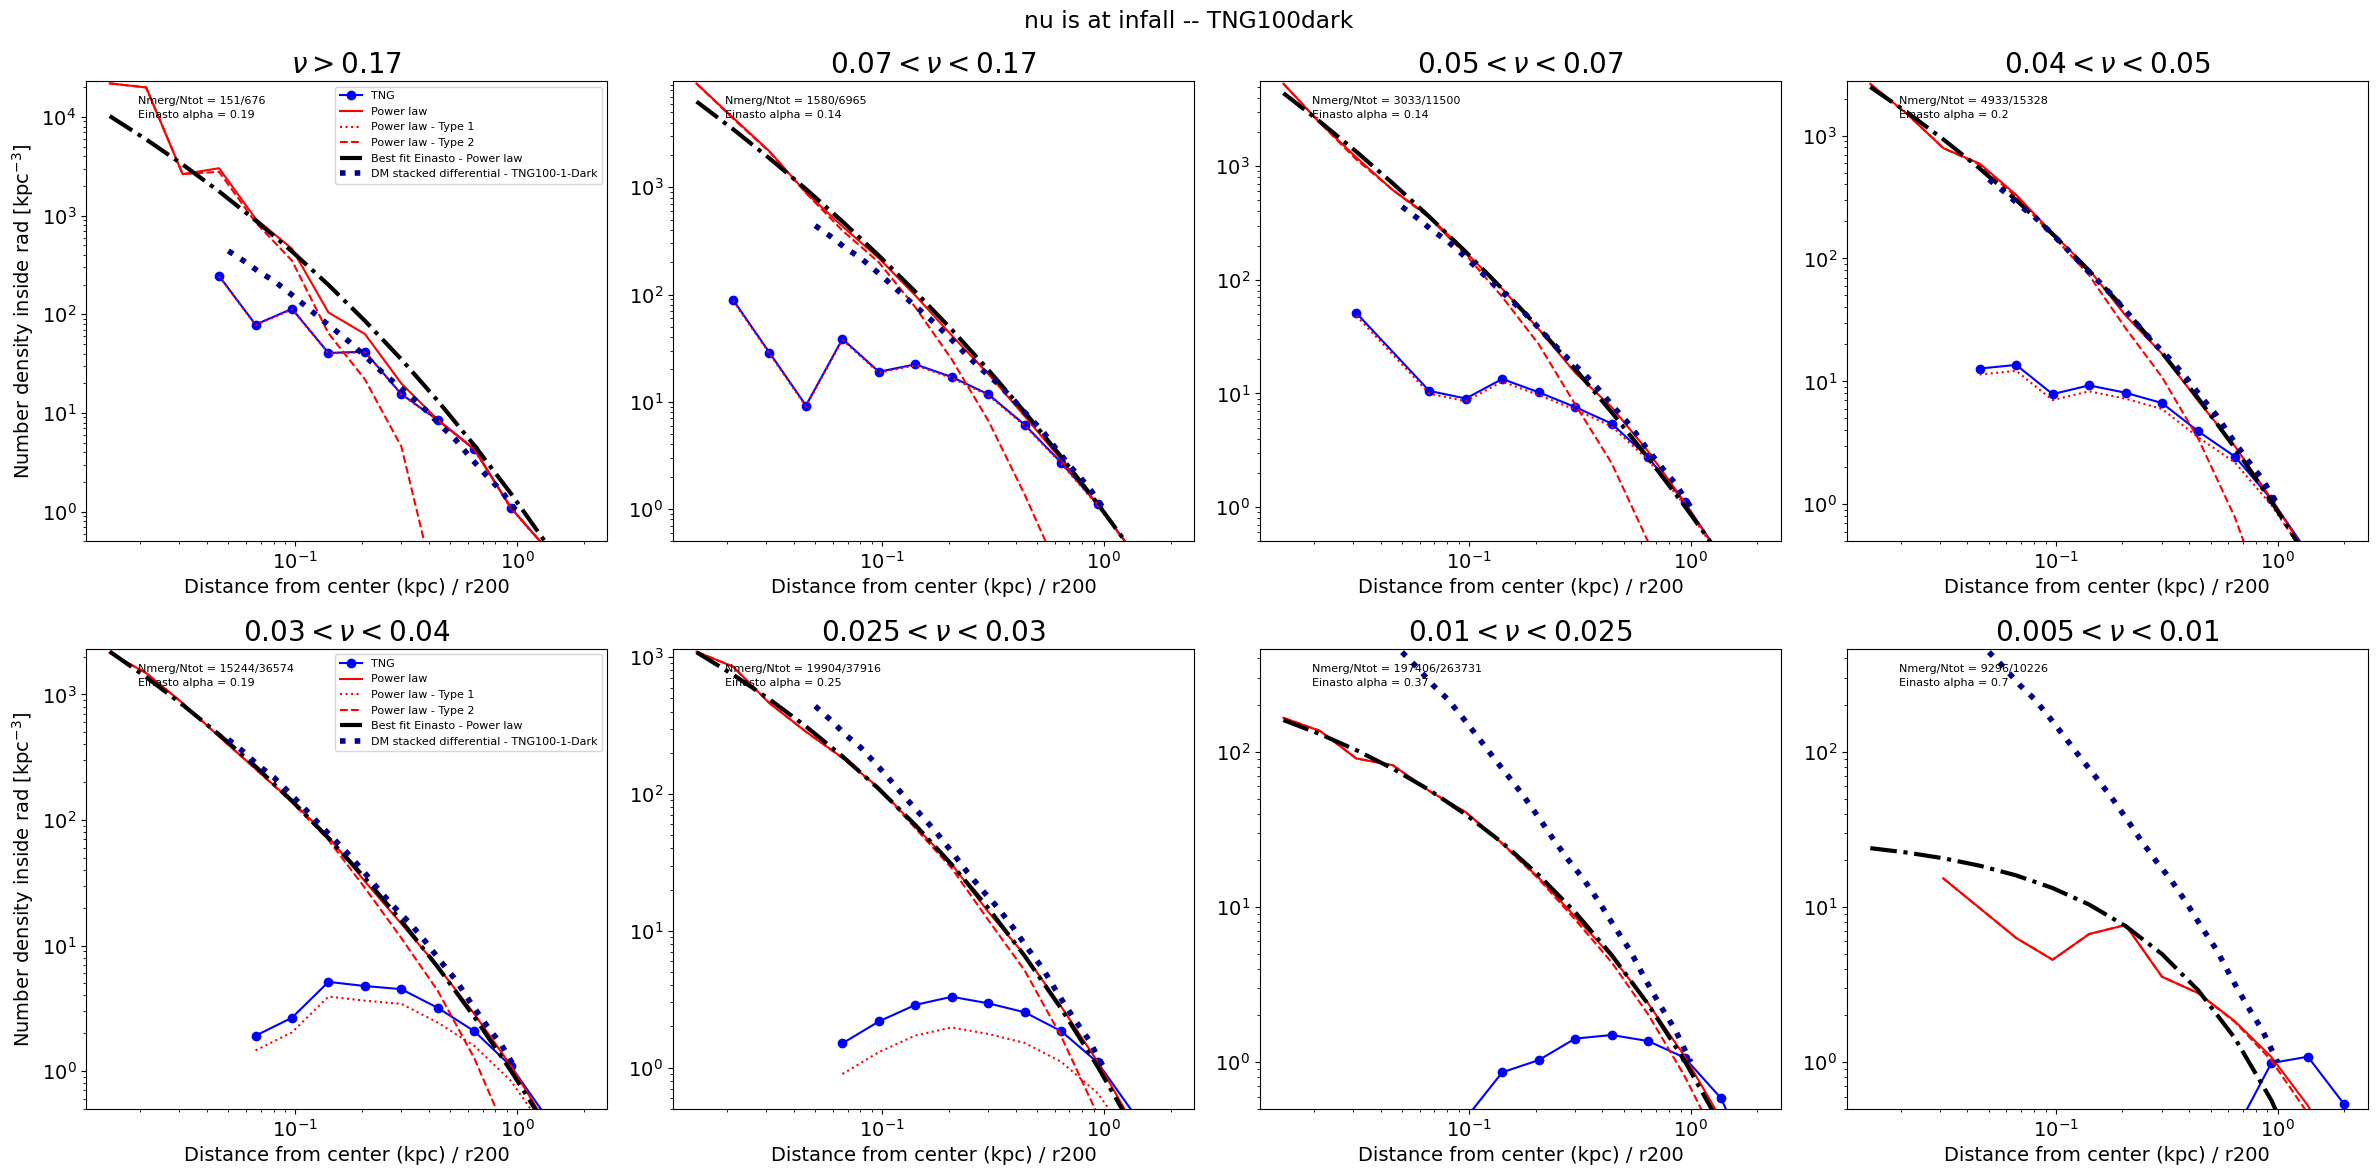

In [99]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately
fig, axs = plt.subplots(2, 4, figsize = (24, 12))


psvrel = np.zeros(len(vmax_ifd1_ar))
t1t2_vrel = np.zeros(len(t1t2_vmax_if))
psrrel = np.zeros(len(vmax_ifd1_ar))
t1t2_rrel = np.zeros(len(t1t2_vmax_if))

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd1_rvir)

    psvrel[fofno1_ar == fofno] = vmax_ifd1_ar[fofno1_ar == fofno] / v200
    t1t2_vrel[t1t2_fof == fofno] = t1t2_vmax_if[t1t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    psrrel = distd1_ar / fofd1_rvir
    t1t2_rrel = t1t2_dist / fofd1_rvir

    

for jx in range(8):
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos

    N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
    Ntng_ar = np.zeros(0)
            
    i = int(jx/4)
    j = jx % 4

    if jx == 0:
        nucutoff = 0.17
        numaxcutoff = np.inf
        axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
    elif jx == 1:
        nucutoff = 0.07
        numaxcutoff = 0.17
        axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
    elif jx ==2:
        nucutoff = 0.05
        numaxcutoff = 0.07
        axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
    elif jx ==3:
        nucutoff = 0.04
        numaxcutoff = 0.05
        axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
    elif jx ==4:
        nucutoff = 0.03
        numaxcutoff = 0.04
        axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
    elif jx ==5:
        nucutoff = 0.025
        numaxcutoff = 0.03
        axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
    elif jx ==6:
        nucutoff = 0.01
        numaxcutoff = 0.025
        axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
    elif jx ==7:
        nucutoff = 0.005
        numaxcutoff = 0.01
        axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
    rpl2 = np.logspace(-2, np.log10(2), 15)
    norm_rad = 1
    for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
        pNm_ar = np.append(pNm_ar, len(t1t2_vmax_if[(t1t2_vrel > nucutoff) & (t1t2_vrel < numaxcutoff) & (t1t2_rrel < rs) & (t1t2_rrel > rpl2[ix])]))
        pNs_ar = np.append(pNs_ar, len(vmax_ifd1_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))
        Ntng_ar = np.append(Ntng_ar, len(vmax_ifd1_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))

    
    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    
    pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    
    rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)

    axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
    axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 1.5)
    axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
    axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')

    lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
    axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Power law', lw = 3)
    axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
    axs[i][j].plot(rbr200_ar, ndm_stacked /  np.interp(1, rbr200_ar, ndm_stacked  ) , color = 'darkblue', ls = ':', label = 'DM stacked differential - TNG100-1-Dark', lw = 4)
    
    # norm_rad = 1
    # rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    # axs[i][j].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) +  nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
    #                         nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)
    if jx == 0 or jx == 4:
        axs[i][j].legend(fontsize = 8)
        axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
    axs[i][j].set_xlabel('Distance from center (kpc) / r200')
    axs[i][j].set_ylim(bottom = 0.5)
    
    axs[i][j].set_xscale('log')
    axs[i][j].set_yscale('log')
plt.suptitle('nu is at infall -- TNG100dark')
plt.tight_layout()
plt.show()

This is to combine the plots for TNG100dark and TNG50hydro
/tmp/ipykernel_3355332/1474091460.py:65: RuntimeWarning: divide by zero encountered in log10
  ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))

/tmp/ipykernel_3355332/1474091460.py:66: RuntimeWarning: divide by zero encountered in log10
  ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))

/tmp/ipykernel_3355332/1474091460.py:67: RuntimeWarning: divide by zero encountered in log10
  ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))

/tmp/ipykernel_3355332/1474091460.py:68: RuntimeWarning: divide by zero encountered in log10
  ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))

/tmp/ipykernel_3355332/1474091460.py:69: RuntimeWarning: divide by zero encountered in log10
  ndm_st5 = np.append(ndm_st5, np.interp

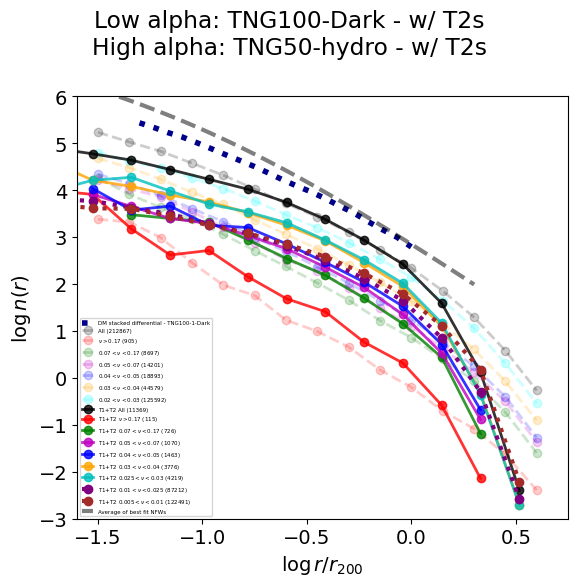

In [72]:
print('This is to combine the plots for TNG100dark and TNG50hydro')
fig, ax = plt.subplots(figsize = (6, 6), ncols = 1)


ax.plot(np.log10(rbr200_ar), np.log10(ndm_stacked * np.interp(1 , 10**np.array(dm_dist_ldf[0]), 10**np.array(dm_dist_ldf[1])) /  np.interp(1, rbr200_ar, ndm_stacked)  ) , color = 'darkblue', ls = ':', label = 'DM stacked differential - TNG100-1-Dark', lw = 4)
alpha = 0
# ax.plot(np.array(dm_dist_ldf[0]), np.array(dm_dist_ldf[1]), 'k-', alpha = alpha)
# ax.plot(np.array(dm_einasto_ldf[0]), np.array(dm_einasto_ldf[1]), 'k-.', alpha = alpha)
# ax.plot(np.array(v1_ldf[0]), np.array(v1_ldf[1]), 'k--', alpha = alpha)
# ax.plot(np.array(v2_ldf[0]), np.array(v2_ldf[1]), 'r--', alpha = alpha)
# ax.plot(np.array(v3_ldf[0]), np.array(v3_ldf[1]), 'g--', alpha = alpha)
# ax.plot(np.array(v4_ldf[0]), np.array(v4_ldf[1]), 'm--', alpha = alpha)
# ax.plot(np.array(v5_ldf[0]), np.array(v5_ldf[1]), 'b--', alpha = alpha)

#That was just the plotting of digitized data. Let us now plot the stacked of TNG
rpl_stack = np.linspace(-1.5, 0.6, 15)
ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)
ndm_st7 = np.zeros(0)

psvrel = np.zeros(len(vmax_ifd1_ar))
t1t2_vrel = np.zeros(len(t1t2_vmax_if))

for fofno in range(16):
    this_fof = il.groupcat.loadSingle(t100dbasePath, 99, haloID = fofno)
    fofd1_pos = this_fof['GroupPos']/h
    fofd1_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd1_rvir)

    psvrel[fofno1_ar == fofno] = vmax_ifd1_ar[fofno1_ar == fofno] / v200
    t1t2_vrel[t1t2_fof == fofno] = t1t2_vmax_if[t1t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    psrrel = distd1_ar / fofd1_rvir
    t1t2_rrel = t1t2_dist / fofd1_rvir

rpl2d1 = np.logspace(-2, np.log10(5), 50) # rpl2 for TNG100-1-Dark FoF11
rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])
d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.02)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n2_ar = np.append(d1n2_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.02)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])

# print(norm_d1Ns2)
ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))
ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))
ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))
ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))
ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n5_ar)))
ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n6_ar)))
ndm_st7 = np.append(ndm_st7, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n7_ar)))
    # / len(lend1_ar[(vmax_ifd1_ar > 45) & (distd1_ar <  fofd1_rvir) & (lend1_ar > 100) & (fofno1_ar == fofno)])

alpha = 0
# ax.plot(rpl_stack , ndm_st1, 'ko:',  label = r'T1All (' + str(len(lend1_ar[(psvrel > 0.02)])) + ')', lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st2, 'ro:',  label = r'T1$\nu > 0.17$ (' + str(len(lend1_ar[(psvrel > 0.17)]) ) + ')', lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st3, 'go:',  label = r'T1$0.07 < \nu < 0.17$ (' + str(len(lend1_ar[(psvrel < 0.17) & (psvrel > 0.07)]))  + ')', lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st4, 'mo:',  label = r'T1$0.05 < \nu < 0.07$ ('+ str(len(lend1_ar[(psvrel < 0.07) & (psvrel > 0.05)])) + ')', lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st5, 'bo:',  label = r'T1$0.04 < \nu < 0.05$ ('+ str(len(lend1_ar[(psvrel < 0.05) & (psvrel > 0.04)])) + ')', lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st6, 'o:', color = 'orange',  label = r'T1$0.03 < \nu < 0.04$ (' + str(len(lend1_ar[(psvrel < 0.04) & (psvrel > 0.03)])) + ')' , lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , ndm_st7, 'o:', color = 'cyan',  label = r'$T10.02 < \nu < 0.03$ (' + str(len(lend1_ar[(psvrel < 0.03) & (psvrel > 0.02)])) + ')' , lw  = 2, alpha = alpha)
# ax.plot(rpl_stack , get_med_values(ndm_st7, 16), 'o-', color = 'orange',  label = r'$0.03 < \nu < 0.04$', lw  = 2)

# The following is for including Type-2s in the simulation

ndm_st1 = np.zeros(0)
ndm_st2 = np.zeros(0)
ndm_st3 = np.zeros(0)
ndm_st4 = np.zeros(0)
ndm_st5 = np.zeros(0)
ndm_st6 = np.zeros(0)
ndm_st7 = np.zeros(0)

d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.02)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.02)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))

    d1n2_ar = np.append(d1n2_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.17)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))

    d1n3_ar = np.append(d1n3_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.07) & (t1t2_vrel < 0.17)]) ) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.05) & (t1t2_vrel < 0.07)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.04) & (t1t2_vrel < 0.05)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.03) & (t1t2_vrel < 0.04)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, (len(lend1_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.02)]) + len(t1t2_dist[(t1t2_rrel > rpl2d1[ix]) & (t1t2_rrel < rpl2d1[ix + 1]) & (t1t2_vrel > 0.02) & (t1t2_vrel < 0.03)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])

# print(norm_d1Ns2)
ndm_st1 = np.append(ndm_st1, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n1_ar)))
ndm_st2 = np.append(ndm_st2, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n2_ar)))
ndm_st3 = np.append(ndm_st3, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n3_ar)))
ndm_st4 = np.append(ndm_st4, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n4_ar)))
ndm_st5 = np.append(ndm_st5, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n5_ar)))
ndm_st6 = np.append(ndm_st6, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n6_ar)))
ndm_st7 = np.append(ndm_st7, np.interp(rpl_stack, np.log10(rpl_interp), np.log10(norm_d1Ns2 *  d1n7_ar)))
# / len(lend1_ar[(vmax_ifd1_ar > 45) & (distd1_ar <  fofd1_rvir) & (lend1_ar > 100) & (fofno1_ar == fofno)])

alpha = 0.2
ls2 = '--'
ax.plot(rpl_stack , ndm_st1, 'ko-',  label = r'All (' + str(len(lend1_ar[(psvrel > 0.02)]) + len(t1t2_vrel[(t1t2_vrel > 0.02)])) + ')', lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st2, 'ro-',  label = r'$\nu > 0.17$ (' + str(len(lend1_ar[(psvrel > 0.17)]) + len(t1t2_vrel[(t1t2_vrel > 0.17)]) ) + ')', lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st3, 'go-',  label = r'$0.07 < \nu < 0.17$ (' + str(len(lend1_ar[(psvrel < 0.17) & (psvrel > 0.07)]) + len(t1t2_vrel[(t1t2_vrel < 0.17) & (t1t2_vrel > 0.07)]))  + ')', lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st4, 'mo-',  label = r'$0.05 < \nu < 0.07$ ('+ str(len(lend1_ar[(psvrel < 0.07) & (psvrel > 0.05)]) + len(t1t2_vrel[(t1t2_vrel < 0.07) & (t1t2_vrel > 0.05)])) + ')', lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st5, 'bo-',  label = r'$0.04 < \nu < 0.05$ ('+ str(len(lend1_ar[(psvrel < 0.05) & (psvrel > 0.04)]) + len(t1t2_vrel[(t1t2_vrel < 0.05) & (t1t2_vrel > 0.04)])) + ')', lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st6, 'o-', color = 'orange',  label = r'$0.03 < \nu < 0.04$ (' + str(len(lend1_ar[(psvrel < 0.04) & (psvrel > 0.03)]) + len(t1t2_vrel[(t1t2_vrel < 0.04) & (t1t2_vrel > 0.03)])) + ')' , lw  = 2, alpha = alpha, ls = ls2)
ax.plot(rpl_stack , ndm_st7, 'o-', color = 'cyan',  label = r'$0.02 < \nu < 0.03$ (' + str(len(lend1_ar[(psvrel < 0.03) & (psvrel > 0.02)]) + len(t1t2_vrel[(t1t2_vrel < 0.03) & (t1t2_vrel > 0.02)])) + ')' , lw  = 2, alpha = alpha, ls = ls2)











psvrel = np.zeros(len(psvmx_if_ar))
psrrel = np.zeros(len(psvmx_if_ar))
pmvrel = np.zeros(len(pmvmx_if_ar))
pmrrel = np.zeros(len(pmvmx_if_ar))

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    fofd_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd_rvir)
    print(v200)

    psvrel[psfof == fofno] = psvmx_if_ar[psfof == fofno] / v200
    psrrel[psfof == fofno] = psdist_f_ar[psfof == fofno] / fofd_rvir
    pmvrel[pmfof == fofno] = pmvmx_if_ar[pmfof == fofno] / v200
    pmrrel[pmfof == fofno] = pmdist_f_ar[pmfof == fofno] / fofd_rvir

rpl2d1 = np.logspace(-2, 0.6, 15) # rpl2 for TNG100-1-Dark FoF11
rpl_interp = np.array([(rpl2d1[i + 1] + rpl2d1[i])/2. for i in range(len(rpl2d1) - 1)])

d1n1_ar = np.zeros(0) # These are the arrays which store the densities in each bin
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    print(rpl2d1[ix + 1])
    d1n1_ar = np.append(d1n1_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1])  & (psvrel > 0.025)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n2_ar = np.append(d1n2_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1])  & (psvrel > 0.17)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # print(rpl2d1[ix], rpl2d1[ix + 1])
    # print(len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]))
    d1n6_ar = np.append(d1n6_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.025)]) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))


norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])


d1n1_ar = np.log10(norm_d1Ns2 * d1n1_ar)
d1n2_ar = np.log10(norm_d1Ns2 * d1n2_ar)
d1n3_ar = np.log10(norm_d1Ns2 * d1n3_ar)
d1n4_ar = np.log10(norm_d1Ns2 * d1n4_ar)
d1n5_ar = np.log10(norm_d1Ns2 * d1n5_ar)
d1n6_ar = np.log10(norm_d1Ns2 * d1n6_ar)
d1n7_ar = np.log10(norm_d1Ns2 * d1n7_ar)
lrpl_interp = np.log10(rpl_interp)

alpha1 = 0
# ax.plot(lrpl_interp , d1n1_ar, 'ko:',  label = r'T1 All (' + str(len(psdist_f_ar[(psvrel > 0.025)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n2_ar, 'ro:',  label = r'T1 $\nu > 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.17)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n3_ar, 'go:',  label = r'T1 $0.07 < \nu < 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.07) & (psvrel < 0.17)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n4_ar, 'mo:',  label = r'T1 $0.05 < \nu < 0.07$ (' + str(len(psdist_f_ar[(psvrel > 0.05) & (psvrel < 0.07)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n5_ar, 'bo:',  label = r'T1 $0.04 < \nu < 0.05$ (' + str(len(psdist_f_ar[(psvrel > 0.04) & (psvrel < 0.05)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n6_ar, 'o:', color = 'orange',  label = r'T1 $0.03 < \nu < 0.04$ (' + str(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)])) + ')', lw  = 2, alpha = alpha1)
# ax.plot(lrpl_interp , d1n7_ar, 'co:',  label = r'T1 $0.025 < \nu < 0.03$ (' + str(len(psdist_f_ar[(psvrel > 0.025) & (psvrel < 0.03)])) + ')', lw  = 2, alpha = alpha1)



# The following part will now be to include the Type-2s as well

d1n1_ar = np.zeros(0)
d1n2_ar = np.zeros(0)
d1n3_ar = np.zeros(0)
d1n4_ar = np.zeros(0)
d1n5_ar = np.zeros(0)
d1n6_ar = np.zeros(0)
d1n7_ar = np.zeros(0)
d1n8_ar = np.zeros(0)
d1n9_ar = np.zeros(0)


for ix in range(len(rpl2d1) - 1):
    d1n1_ar = np.append(d1n1_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.025)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel > 0.025)])) 
                        / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # print(len(psdist_f_ar[(psdist_f_ar > rpl2d1[ix]) & (psdist_f_ar < rpl2d1[ix + 1]) & (psfof == fofno) & (psvrel > 0.04) ]))
    d1n2_ar = np.append(d1n2_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel > 0.17)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel > 0.17)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n3_ar = np.append(d1n3_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.17) & (psvrel > 0.07)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.17) & (pmvrel > 0.07)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n4_ar = np.append(d1n4_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.07) & (psvrel > 0.05)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.07) & (pmvrel > 0.05)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n5_ar = np.append(d1n5_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.05) & (psvrel > 0.04)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.05) & (pmvrel > 0.04)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n6_ar = np.append(d1n6_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.04) & (psvrel > 0.03)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.04) & (pmvrel > 0.03)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    d1n7_ar = np.append(d1n7_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.03) & (psvrel > 0.025)]) + 
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.03) & (pmvrel > 0.025)])) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    
    d1n8_ar = np.append(d1n8_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.025) & (psvrel > 0.01)]) +
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.025) & (pmvrel > 0.01)]) ) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    
    d1n9_ar = np.append(d1n9_ar, (len(psdist_f_ar[(psrrel > rpl2d1[ix]) & (psrrel < rpl2d1[ix + 1]) & (psvrel < 0.01) & (psvrel > 0.005)]) +
                                    len(pmdist_f_ar[(pmrrel > rpl2d1[ix]) & (pmrrel < rpl2d1[ix + 1]) & (pmvrel < 0.01) & (pmvrel > 0.005)]) ) / (4 * np.pi * (rpl2d1[ix + 1] ** 3 - rpl2d1[ix] ** 3) / 3.))
    # d1Ns_all_ar = np.append(d1Ns_all_ar, len(lend1_ar[(distd1_ar < rpl2d1[ix]) & (lend1_ar > 100) & (fofno1_ar == fofno)]))
# print( rpl_interp[np.where(d1n1_ar != 0)[0]])
# print(len(psdist_f_ar[(psfof == fofno)]))

norm_d1Ns2 = (10 ** np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))  / np.interp(1, rpl_interp[np.where(d1n1_ar != 0)[0]], d1n1_ar[np.where(d1n1_ar != 0)[0]])


d1n1_ar = np.log10(norm_d1Ns2 * d1n1_ar)
d1n2_ar = np.log10(norm_d1Ns2 * d1n2_ar)
d1n3_ar = np.log10(norm_d1Ns2 * d1n3_ar)
d1n4_ar = np.log10(norm_d1Ns2 * d1n4_ar)
d1n5_ar = np.log10(norm_d1Ns2 * d1n5_ar)
d1n6_ar = np.log10(norm_d1Ns2 * d1n6_ar)
d1n7_ar = np.log10(norm_d1Ns2 * d1n7_ar)
d1n8_ar = np.log10(norm_d1Ns2 * d1n8_ar / 50)
d1n9_ar = np.log10(norm_d1Ns2 * d1n9_ar / 50)

alpha2 = 0.8
ax.plot(lrpl_interp , d1n1_ar, 'ko-',  label = r'T1+T2 All (' + str(len(psdist_f_ar[(psvrel > 0.025)]) + len(pmdist_f_ar[(pmvrel > 0.025)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n2_ar, 'ro-',  label = r'T1+T2 $\nu > 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.17)]) + len(pmdist_f_ar[(pmvrel > 0.17)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n3_ar, 'go-',  label = r'T1+T2 $0.07 < \nu < 0.17$ (' + str(len(psdist_f_ar[(psvrel > 0.07) & (psvrel < 0.17)]) + len(pmdist_f_ar[(pmvrel > 0.07) & (pmvrel < 0.17)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n4_ar, 'mo-',  label = r'T1+T2 $0.05 < \nu < 0.07$ (' + str(len(psdist_f_ar[(psvrel > 0.05) & (psvrel < 0.07)]) + len(pmdist_f_ar[(pmvrel > 0.05) & (pmvrel < 0.07)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n5_ar, 'bo-',  label = r'T1+T2 $0.04 < \nu < 0.05$ (' + str(len(psdist_f_ar[(psvrel > 0.04) & (psvrel < 0.05)]) + len(pmdist_f_ar[(pmvrel > 0.04) & (pmvrel < 0.05)])) + ')', lw  = 2, alpha = alpha2)
ax.plot(lrpl_interp , d1n6_ar, 'o-', color = 'orange',  label = r'T1+T2 $0.03 < \nu < 0.04$ (' + str(len(psdist_f_ar[(psvrel > 0.03) & (psvrel < 0.04)]) + len(pmdist_f_ar[(pmvrel > 0.03) & (pmvrel < 0.04)])) + ')', lw  = 2, alpha = alpha2)

cond_cut = (d1n6_ar != 0) & (d1n6_ar != -np.inf)
print('alpha for nu in (0.03, 0.04)', fit_einasto(10**(lrpl_interp[cond_cut]), 10**(d1n6_ar[cond_cut]))[0][2])
lrho, lrs, alpha = fit_einasto(10**(lrpl_interp[cond_cut]), 10**(d1n6_ar[cond_cut]))[0]
# ax.plot(lrpl_interp[cond_cut], einasto_density(lrpl_interp[cond_cut], lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto with alpha = ' + str(round(alpha, 2)), lw = 3)


ax.plot(lrpl_interp , d1n7_ar, 'co-',  label = r'T1+T2 $0.025 < \nu < 0.03$ (' + str(len(psdist_f_ar[(psvrel > 0.025) & (psvrel < 0.03)]) + len(pmdist_f_ar[(pmvrel > 0.025) & (pmvrel < 0.03)])) + ')', lw  = 2, alpha = alpha2)

ax.plot(lrpl_interp , d1n8_ar, 'o-', color = 'purple',  label = r'T1+T2 $0.01 < \nu < 0.025$ (' + str(len(psdist_f_ar[(psvrel > 0.01) & (psvrel < 0.025)]) + len(pmdist_f_ar[(pmvrel > 0.01) & (pmvrel < 0.025)])) + ')', lw  = 3, alpha = 1, ls = ':')

ax.plot(lrpl_interp , d1n9_ar, 'o-', color = 'brown',  label = r'T1+T2 $0.005 < \nu < 0.01$ (' + str(len(psdist_f_ar[(psvrel > 0.005) & (psvrel < 0.01)]) + len(pmdist_f_ar[(pmvrel > 0.005) & (pmvrel < 0.01)])) + ')', lw  = 3, alpha = 1, ls = ':')



norm_rad = 1
rdm_pl = np.logspace(-1.7, np.log10(2), 100)
ax.plot(np.log10(rdm_pl) , np.log10(700*(nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) + 
                           nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                           nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.)
                 ,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)












    
ax.legend(fontsize = 4)
# ax.axhline( np.interp(0, np.array(m1_ldf[0]), np.array(m1_ldf[1])))
ax.set_xlabel(r'$\log r/r_{200}$')
ax.set_ylabel(r'$\log n(r)$')
ax.set_ylim(-3, 6)
ax.set_xlim(-1.6, 0.75)



plt.suptitle('Low alpha: TNG100-Dark - w/ T2s\nHigh alpha: TNG50-hydro - w/ T2s')
plt.tight_layout()
plt.show()

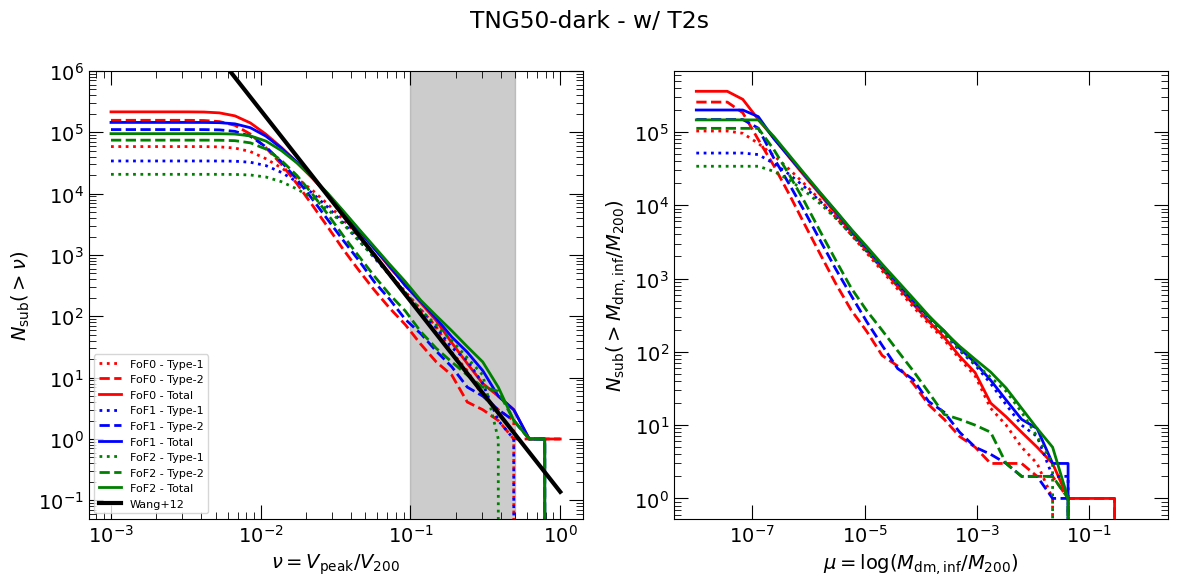

In [99]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize = (12, 6))
G = 4.3e-6

psvrel = np.zeros(len(vmax_ifd5_ar))
t5t2_vrel = np.zeros(len(t5t2_vmax_if))
psrrel = np.zeros(len(vmax_ifd5_ar))
t5t2_rrel = np.zeros(len(t5t2_vmax_if))

nu_pl = np.logspace(-3, 0, 30)
col_ar = ['red', 'blue', 'green']

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(t50dbasePath, 99, haloID = fofno)
    fofd5_pos = this_fof['GroupPos']/h
    fofd5_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd5_rvir)

    # psvrel[fofno5_ar == fofno] = vmax_ifd5_ar[fofno5_ar == fofno] / v200
    # t5t2_vrel[t5t2_fof == fofno] = t5t2_vmax_if[t5t2_fof == fofno] / v200 # These are the nu values for the Type-2s
    psvrel[fofno5_ar == fofno] = vpeakd5_ar[fofno5_ar == fofno] / v200
    t5t2_vrel[t5t2_fof == fofno] = t5t2_vpeak[t5t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    psrrel = distd5_ar / fofd5_rvir
    t5t2_rrel = t5t2_dist / fofd5_rvir

    Ns_nu_ar = np.zeros(0)
    Nm_nu_ar = np.zeros(0)
    for nu in nu_pl:
        Ns_nu_ar = np.append(Ns_nu_ar, len(distd5_ar[(psrrel < 1) & (psvrel > nu) & (fofno5_ar == fofno)]))
        Nm_nu_ar = np.append(Nm_nu_ar, len(t5t2_dist[(t5t2_rrel < 1) & (t5t2_vrel > nu) & (t5t2_fof == fofno)]))
    
    ax.plot(nu_pl, Ns_nu_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Type-1', lw = 2, ls = ':')
    ax.plot(nu_pl, Nm_nu_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Type-2', lw = 2, ls = '--')
    ax.plot(nu_pl, Ns_nu_ar + Nm_nu_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Total', lw = 2, ls = '-')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\nu = V_{\rm{peak}} / V_{200}$')
ax.set_ylabel(r'$N_{\rm{sub}}( > \nu)$')
ax.plot(nu_pl, 50.2 * (nu_pl/0.15)**(-3.11), color = 'black', label = 'Wang+12')
ax.fill_betweenx([1e-2, 1e8], 0.1, 0.5, color = 'gray', alpha = 0.4)
ax.set_ylim(0.05, 1e6)
ax.legend(fontsize = 8)

mpl = np.linspace(-8, 0, 30)
for fofno in range(3):
    this_fof = il.groupcat.loadSingle(t50dbasePath, 99, haloID = fofno)
    fofd5_pos = this_fof['GroupPos']/h
    fofd5_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd5_rvir)

    lmrel = np.log10(mass_ifd5_ar / m200)
    lmrel2 = np.log10(t5t2_mdm_if / m200)
    Ns_m_ar = np.zeros(0)
    Nm_m_ar = np.zeros(0)

    for mt in mpl:
        Ns_m_ar = np.append(Ns_m_ar, len(distd5_ar[(lmrel > mt) & (fofno5_ar == fofno)]))
        Nm_m_ar = np.append(Nm_m_ar, len(t5t2_dist[(lmrel2 > mt) & (t5t2_fof == fofno)]))
    
    ax2.plot(10**mpl, Ns_m_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Type-1', lw = 2, ls = ':')
    ax2.plot(10**mpl, Nm_m_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Type-2', lw = 2, ls = '--')
    ax2.plot(10**mpl, Ns_m_ar + Nm_m_ar, color = col_ar[fofno], label = 'FoF' + str(fofno) + ' - Total', lw = 2, ls = '-')

ax2.set_ylabel(r'$N_{\rm{sub}}( > M_{\rm{dm, inf}} / M_{200})$')
ax2.set_xlabel(r'$\mu = \log(M_{\rm{dm, inf}} / M_{200})$')
ax2.set_xscale('log')
ax2.set_yscale('log')
# ax2.legend(fontsize = 8)


plt.suptitle('TNG50-dark - w/ T2s')
plt.tight_layout()
plt.show()

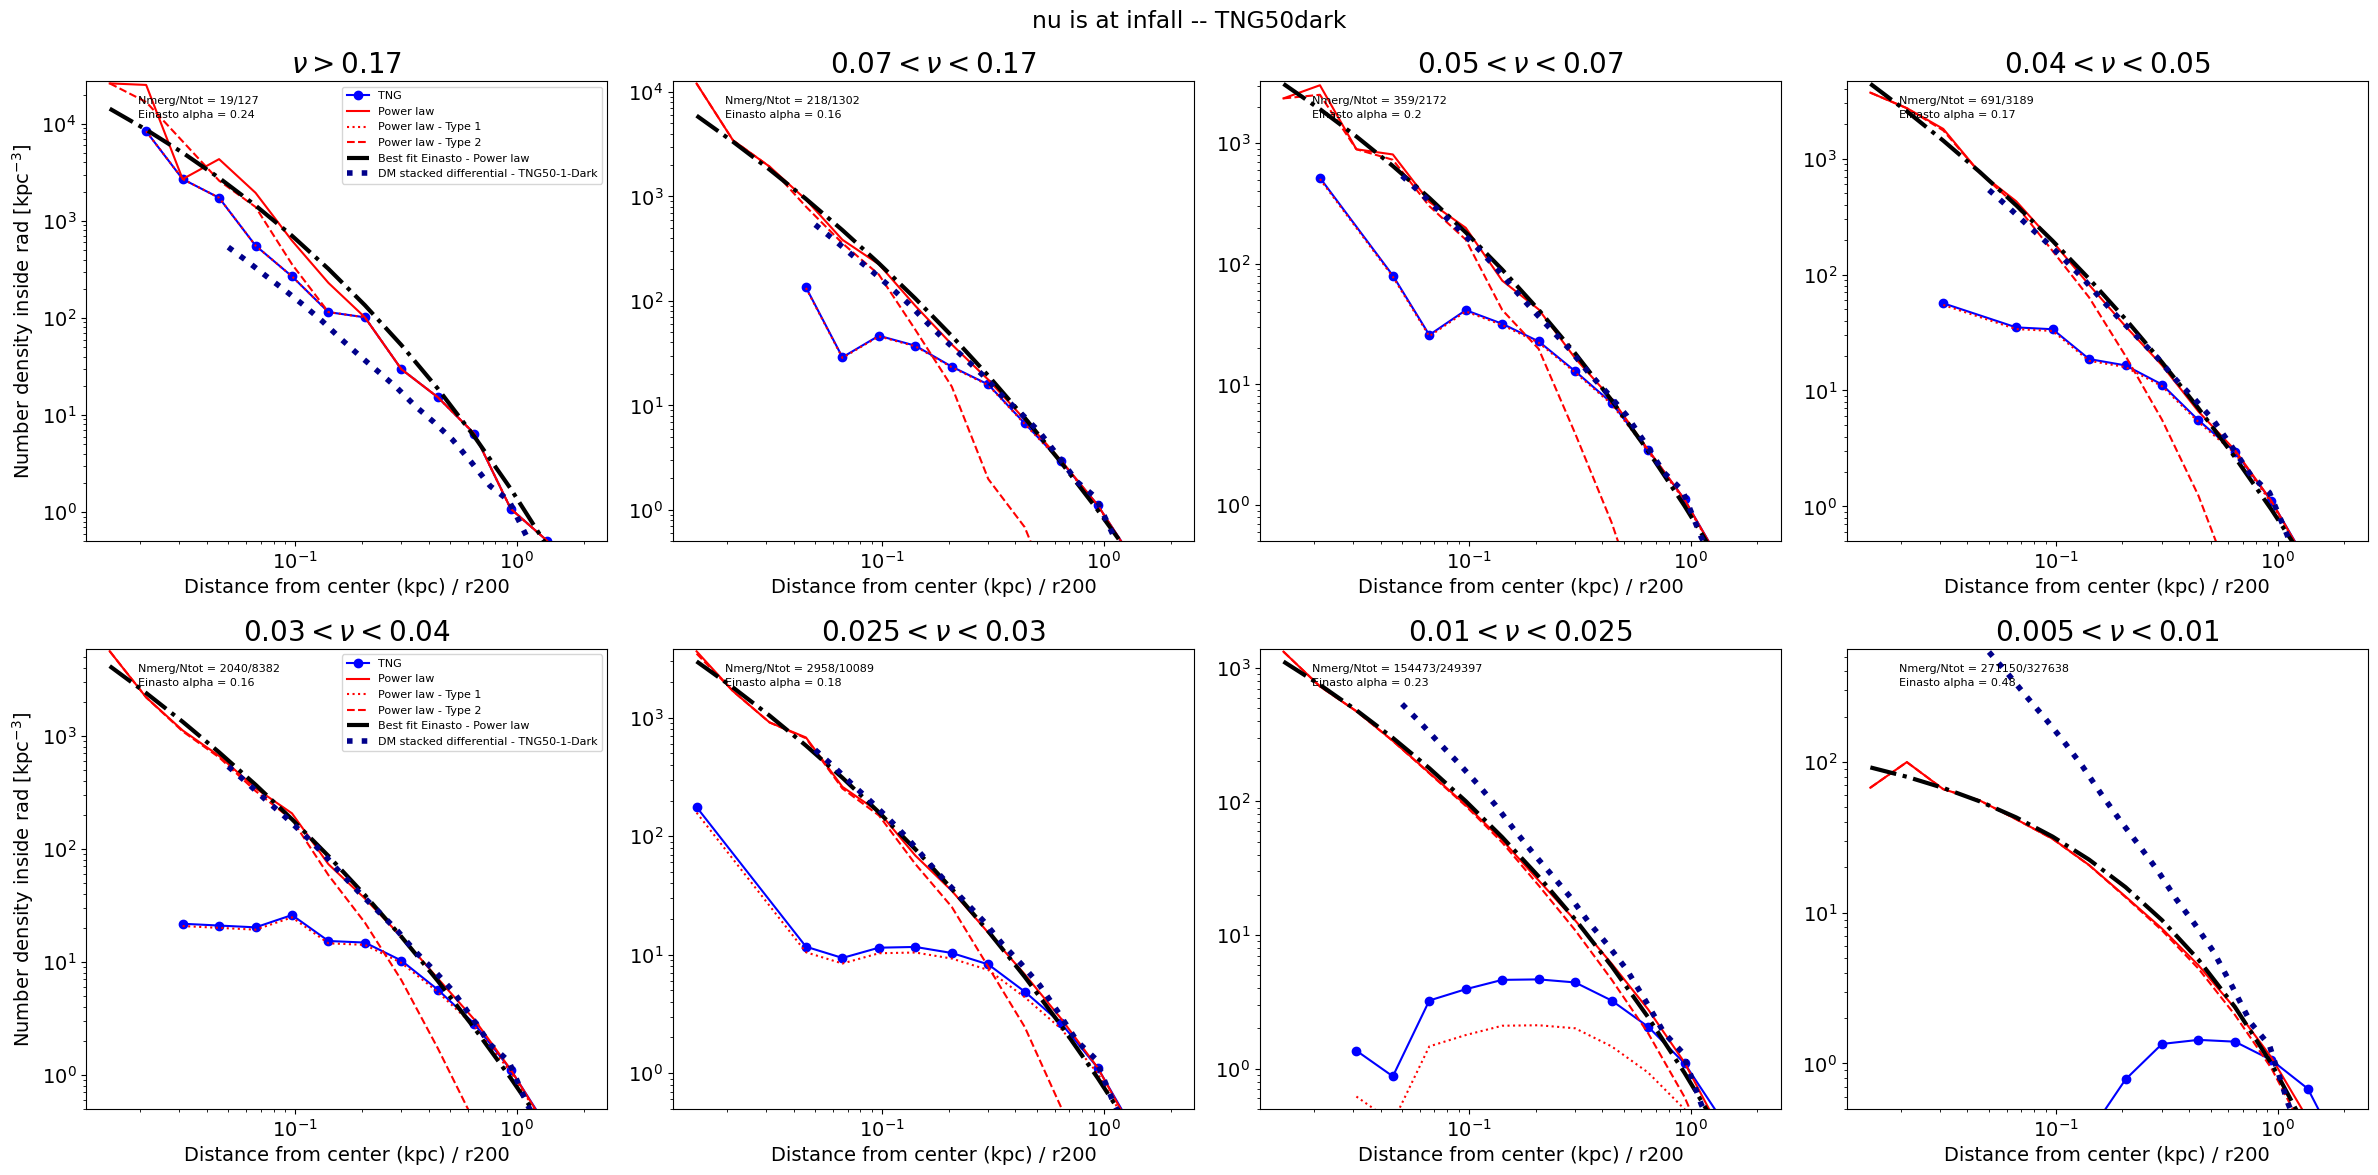

In [119]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately
fig, axs = plt.subplots(2, 4, figsize = (24, 12))


psvrel = np.zeros(len(vmax_ifd5_ar))
t5t2_vrel = np.zeros(len(t5t2_vmax_if))
psrrel = np.zeros(len(vmax_ifd5_ar))
t5t2_rrel = np.zeros(len(t5t2_vmax_if))

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(t50dbasePath, 99, haloID = fofno)
    fofd5_pos = this_fof['GroupPos']/h
    fofd5_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd5_rvir)

    psvrel[fofno5_ar == fofno] = vmax_ifd5_ar[fofno5_ar == fofno] / v200
    t5t2_vrel[t5t2_fof == fofno] = t5t2_vmax_if[t5t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    psrrel = distd5_ar / fofd5_rvir
    t5t2_rrel = t5t2_dist / fofd5_rvir

    

for jx in range(8):
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos

    N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
    Ntng_ar = np.zeros(0)
            
    i = int(jx/4)
    j = jx % 4

    if jx == 0:
        nucutoff = 0.17
        numaxcutoff = np.inf
        axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
    elif jx == 1:
        nucutoff = 0.07
        numaxcutoff = 0.17
        axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
    elif jx ==2:
        nucutoff = 0.05
        numaxcutoff = 0.07
        axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
    elif jx ==3:
        nucutoff = 0.04
        numaxcutoff = 0.05
        axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
    elif jx ==4:
        nucutoff = 0.03
        numaxcutoff = 0.04
        axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
    elif jx ==5:
        nucutoff = 0.025
        numaxcutoff = 0.03
        axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
    elif jx ==6:
        nucutoff = 0.01
        numaxcutoff = 0.025
        axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
    elif jx ==7:
        nucutoff = 0.005
        numaxcutoff = 0.01
        axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
    rpl2 = np.logspace(-2, np.log10(2), 15)
    norm_rad = 1
    for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
        pNm_ar = np.append(pNm_ar, len(t5t2_vmax_if[(t5t2_vrel > nucutoff) & (t5t2_vrel < numaxcutoff) & (t5t2_rrel < rs) & (t5t2_rrel > rpl2[ix])]))
        pNs_ar = np.append(pNs_ar, len(vmax_ifd1_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))
        Ntng_ar = np.append(Ntng_ar, len(vmax_ifd1_ar[(psvrel > nucutoff) & (psvrel < numaxcutoff) & (psrrel < rs) & (psrrel > rpl2[ix])]))

    
    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    
    pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    
    rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)
    
    axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)

    axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
    axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 1.5)
    axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Power law - Type 1', lw  = 1.5, ls = ':')
    axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Power law - Type 2', lw  = 1.5, ls = '--')

    lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
    axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - Power law', lw = 3)
    axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
    axs[i][j].plot(rbr200_ar, ndm_stacked5 /  np.interp(1, rbr200_ar, ndm_stacked5  ) , color = 'darkblue', ls = ':', label = 'DM stacked differential - TNG50-1-Dark', lw = 4)
    
    # norm_rad = 1
    # rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    # axs[i][j].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) +  nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
    #                         nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)
    if jx == 0 or jx == 4:
        axs[i][j].legend(fontsize = 8)
        axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
    axs[i][j].set_xlabel('Distance from center (kpc) / r200')
    axs[i][j].set_ylim(bottom = 0.5)
    
    axs[i][j].set_xscale('log')
    axs[i][j].set_yscale('log')
plt.suptitle('nu is at infall -- TNG50dark')
plt.tight_layout()
plt.show()

In [153]:
# This cell is to import the data for TNG50hydro -- new run without nu cuts

t50dbasePath = '/rhome/psadh003/bigdata/TNG50-1-Dark/output'
t50dfilepath = '/rhome/psadh003/bigdata/tng50dark/tng_files/'

t5hdf = pd.read_csv(t50dfilepath + 'hydromaster_tng50d.csv')
t5hdf = t5hdf.applymap(convert_to_float)

t5hposx = t5hdf['posx_ar'].values
t5hposy = t5hdf['posy_ar'].values
t5hposz = t5hdf['posz_ar'].values
t5hvelx_ar = t5hdf['velx_ar'].values
t5hvely_ar = t5hdf['vely_ar'].values
t5hvelz_ar = t5hdf['velz_ar'].values
t5hvmax_if_ar = t5hdf['vmax_if_ar'].values
t5hsnap_if_ar = t5hdf['snap_if_ar'].values
t5hdist_ar = np.sqrt(t5hposx ** 2 + t5hposy ** 2 + t5hposz ** 2)
t5hfof = t5hdf['fof'].values




In [154]:
# This cell is to import the data for TNG50hydro Type-2 satellites -- new run without nu cuts

t5h_t2_df = pd.read_csv(t50dfilepath + 'hydromaster_t2_tng50d.csv')
t5h_t2_df = t5h_t2_df.applymap(convert_to_float)

t5h_t2_posx = t5h_t2_df['posx_ar'].values
t5h_t2_posy = t5h_t2_df['posy_ar'].values
t5h_t2_posz = t5h_t2_df['posz_ar'].values

t5h_t2_velx_ar = t5h_t2_df['velx_ar'].values
t5h_t2_vely_ar = t5h_t2_df['vely_ar'].values
t5h_t2_velz_ar = t5h_t2_df['velz_ar'].values

t5h_t2_vmax_if_ar = t5h_t2_df['vmax_if_ar'].values
t5h_t2_snap_if_ar = t5h_t2_df['snap_if_ar'].values
t5h_t2_dist_ar = np.sqrt(t5h_t2_posx ** 2 + t5h_t2_posy ** 2 + t5h_t2_posz ** 2)
t5h_t2_fof = t5h_t2_df['fof'].values

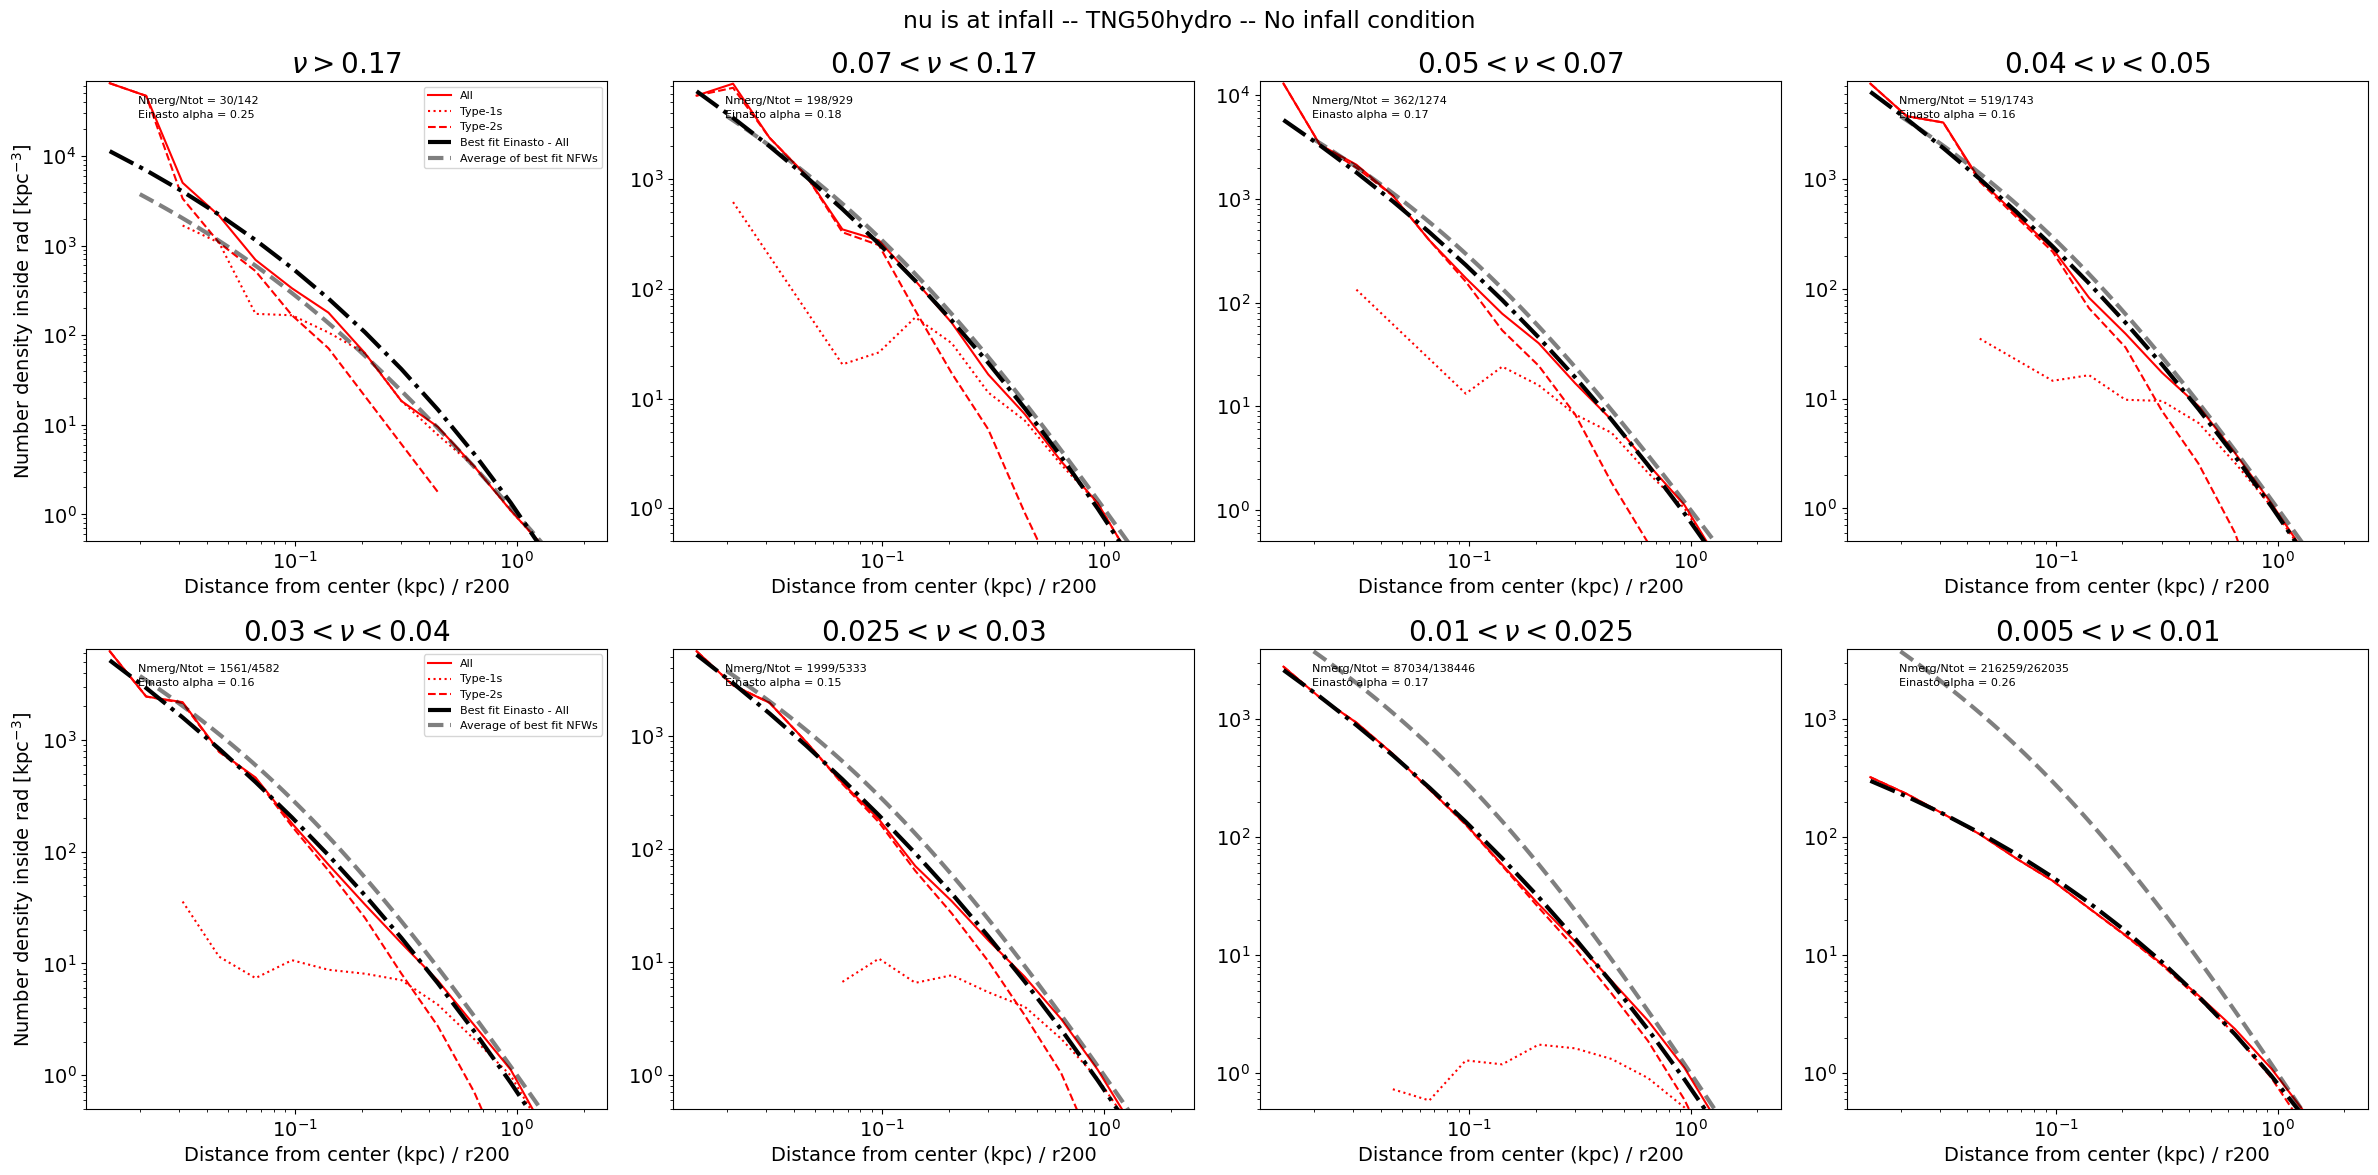

In [157]:
#  This is again for nu at infall but now we are calculating the density in each bin seaprately
fig, axs = plt.subplots(2, 4, figsize = (24, 12))


t5h_inf_cond = (t5hsnap_if_ar > -1)
t5h_t2_inf_cond = (t5h_t2_snap_if_ar > -1)


t5hvrel = np.zeros(len(t5hvmax_if_ar))
t5hrrel = np.zeros(len(t5hvmax_if_ar))
t5h_t2_vrel = np.zeros(len(t5h_t2_vmax_if_ar))
t5h_t2_rrel = np.zeros(len(t5h_t2_vmax_if_ar))

for fofno in range(3): # Going over all the FoFs
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    fofh5_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofh5_rvir)

    t5hvrel[t5hfof == fofno] = t5hvmax_if_ar[t5hfof == fofno] / v200
    t5h_t2_vrel[t5h_t2_fof == fofno] = t5h_t2_vmax_if_ar[t5h_t2_fof == fofno] / v200 # These are the nu values for the Type-2s

    t5hrrel = t5hdist_ar / fofh5_rvir
    t5h_t2_rrel = t5h_t2_dist_ar / fofh5_rvir


for jx in range(8):
    pNm_ar = np.zeros(0) #shmf for merged subhalos
    pNs_ar = np.zeros(0) #shmf for surviving subhalos 
    cNm_ar = np.zeros(0) #shmf for merged subhalos
    cNs_ar = np.zeros(0) #shmf for surviving subhalos

    N_all_ar = np.zeros(0) #This is for all the subhalos inside virial radius
    Ntng_ar = np.zeros(0)
            
    i = int(jx/4)
    j = jx % 4

    if jx == 0:
        nucutoff = 0.17
        numaxcutoff = np.inf
        axs[i][j].set_title(r'$ \nu >  0.17$', fontsize = label_font)
    elif jx == 1:
        nucutoff = 0.07
        numaxcutoff = 0.17
        axs[i][j].set_title(r'$0.07 < \nu  < 0.17$', fontsize = label_font)
    elif jx ==2:
        nucutoff = 0.05
        numaxcutoff = 0.07
        axs[i][j].set_title(r'$0.05 < \nu  < 0.07$', fontsize = label_font)
    elif jx ==3:
        nucutoff = 0.04
        numaxcutoff = 0.05
        axs[i][j].set_title(r'$0.04 < \nu  < 0.05$', fontsize = label_font)
    elif jx ==4:
        nucutoff = 0.03
        numaxcutoff = 0.04
        axs[i][j].set_title(r'$0.03 < \nu  < 0.04$', fontsize = label_font)
    elif jx ==5:
        nucutoff = 0.025
        numaxcutoff = 0.03
        axs[i][j].set_title(r'$0.025 < \nu  < 0.03$', fontsize = label_font)
    elif jx ==6:
        nucutoff = 0.01
        numaxcutoff = 0.025
        axs[i][j].set_title(r'$0.01 < \nu  < 0.025$', fontsize = label_font)
    elif jx ==7:
        nucutoff = 0.005
        numaxcutoff = 0.01
        axs[i][j].set_title(r'$0.005 < \nu  < 0.01$', fontsize = label_font)
    rpl2 = np.logspace(-2, np.log10(2), 15)
    norm_rad = 1
    for (ix, rs) in enumerate(rpl2[1:]): #rs is still radius, has nothing to do with rs of NFW profile
        pNm_ar = np.append(pNm_ar, len(t5h_t2_vmax_if_ar[(t5h_t2_vrel > nucutoff) & (t5h_t2_vrel < numaxcutoff) & (t5h_t2_rrel < rs) & (t5h_t2_rrel > rpl2[ix]) & t5h_t2_inf_cond]) )
        pNs_ar = np.append(pNs_ar, len(t5hvmax_if_ar[(t5hvrel > nucutoff) & (t5hvrel < numaxcutoff) & (t5hrrel < rs) & (t5hrrel > rpl2[ix]) & t5h_inf_cond]))
        Ntng_ar = np.append(Ntng_ar, len(t5hvmax_if_ar[(t5hvrel > nucutoff) & (t5hvrel < numaxcutoff) & (t5hrrel < rs) & (t5hrrel > rpl2[ix]) & t5h_inf_cond]))
    
    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)

    pN_ar = (pNs_ar + pNm_ar) / (rpl2[1:]**3 - rpl2[:-1]**3)

    rhos_ar = pNs_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhos_ar = rhos_ar / np.interp(norm_rad, rpl2[1:], pN_ar)

    rhom_ar = pNm_ar / (rpl2[1:]**3 - rpl2[:-1]**3)
    rhom_ar = rhom_ar / np.interp(norm_rad, rpl2[1:], pN_ar)

    pN_ar = pN_ar / np.interp(norm_rad, rpl2[1:], pN_ar)

    axs[i][j].text(0.1, 0.95, 'Nmerg/Ntot = ' + str(int(np.sum(pNm_ar))) + '/' + str(int(np.sum(pNs_ar) + np.sum(pNm_ar))), transform=axs[i][j].transAxes, fontsize = 8)

    # axs[i][j].plot(rpl2[1:][Ntng_ar!=0], Ntng_ar[Ntng_ar!=0], 'bo-', label = r'TNG')
    axs[i][j].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'All', lw  = 1.5)
    axs[i][j].plot(rpl2[1:][pNs_ar != 0], rhos_ar[pNs_ar != 0], color = 'red', label = r'Type-1s', lw  = 1.5, ls = ':')
    axs[i][j].plot(rpl2[1:][pNm_ar != 0], rhom_ar[pNm_ar != 0], color = 'red', label = r'Type-2s', lw  = 1.5, ls = '--')

    lrho, lrs, alpha = fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0]
    axs[i][j].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', label = 'Best fit Einasto - All', lw = 3)
    axs[i][j].text(0.1, 0.92, 'Einasto alpha = ' + str(round(fit_einasto(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0])[0][2], 2)), transform=axs[i][j].transAxes, fontsize = 8)
    norm_rad = 1
    rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    axs[i][j].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) +  nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                            nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.,  color = 'black', ls = '--', label = 'Average of best fit NFWs', alpha = 0.5, lw = 3)
    if jx == 0 or jx == 4:
        axs[i][j].legend(fontsize = 8)
        axs[i][j].set_ylabel(r'Number density inside rad $[\rm{kpc^{-3}}]$')
    axs[i][j].set_xlabel('Distance from center (kpc) / r200')
    axs[i][j].set_ylim(bottom = 0.5)

    axs[i][j].set_xscale('log')
    axs[i][j].set_yscale('log')
plt.suptitle('nu is at infall -- TNG50hydro -- No infall condition')
plt.tight_layout()
plt.show()


811.4848897634926
649.5195962176479
573.0785028184382


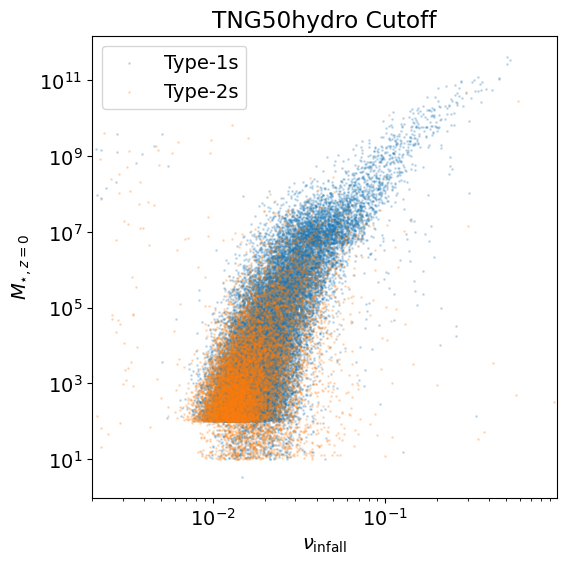

In [75]:
fig, ax = plt.subplots(1, 1, figsize = (6, 6))
csvrel = np.zeros(len(csvmx_if_ar))
csrrel = np.zeros(len(csvmx_if_ar))
cmvrel = np.zeros(len(cmvmx_if_ar))
cmrrel = np.zeros(len(cmvmx_if_ar))

for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    fofd_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd_rvir)
    print(v200)

    csvrel[csfof == fofno] = csvmx_if_ar[csfof == fofno] / v200
    csrrel[csfof == fofno] = csdist_f_ar[csfof == fofno] / fofd_rvir
    cmvrel[cmfof == fofno] = cmvmx_if_ar[cmfof == fofno] / v200
    cmrrel[cmfof == fofno] = cmdist_f_ar[cmfof == fofno] / fofd_rvir

ax.scatter(csvrel, csmstar_all, s = 1, alpha = 0.2, label = 'Type-1s')
ax.scatter(cmvrel, cmmstar_all, s = 1, alpha = 0.2, label = 'Type-2s')
ax.set_xlabel(r'$\nu_{\rm{infall}}$')
ax.set_ylabel(r'$M_{\star, z = 0}$')
ax.set_yscale('log')
ax.legend()
ax.set_xlim(left = 2e-3)
ax.set_xscale('log')
ax.set_title('TNG50hydro Cutoff')
plt.show()

This is to make the Figure 3 from Wang et al 2012 -- The distribution of Vmx for all three FoFs


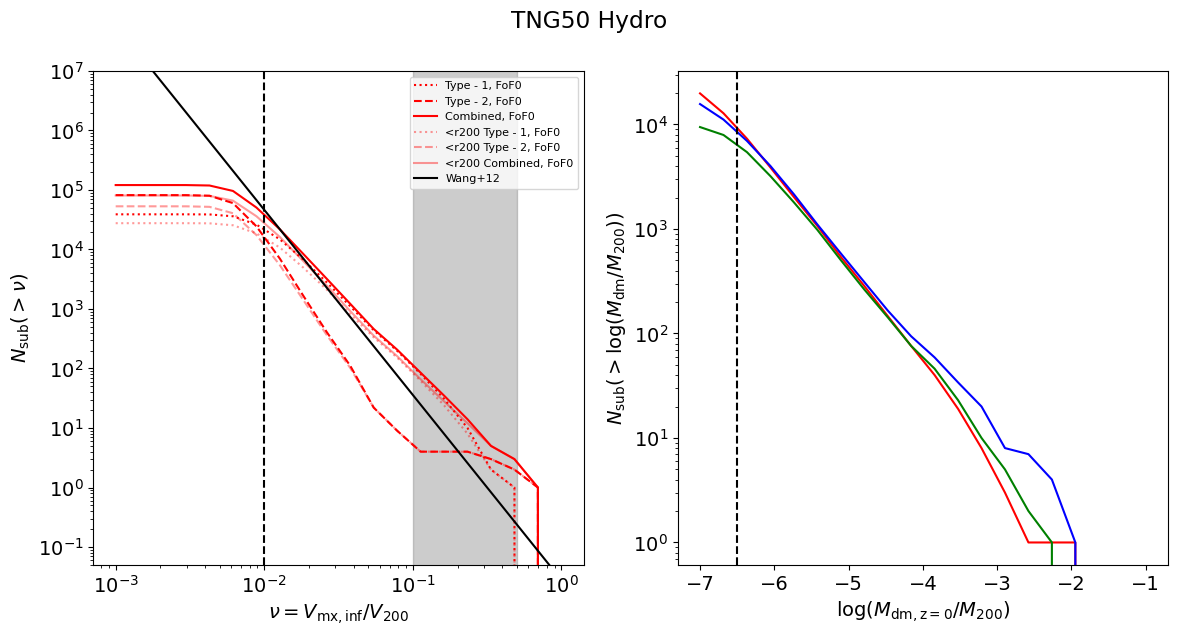

In [76]:
print('This is to make the Figure 3 from Wang et al 2012 -- The distribution of Vmx for all three FoFs')
colors = ['red', 'blue', 'green']   

fig, (ax, ax2) = plt.subplots(figsize = (12, 6.5), ncols = 2)
nu_pl = np.logspace(-3, 0, 20)
for fofno in [0]:
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)

    central_sfid_99 = this_fof['GroupFirstSub']
    cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    r200 = this_fof['Group_R_Crit200'] / h
    v200 = np.sqrt(G * m200 / r200)
    
    psvrel = psvmx_if_ar / v200
    pmvrel = pmvmx_if_ar / v200
    
    Ns_nu_ar = np.zeros(0)
    Nm_nu_ar = np.zeros(0)
    for (ix, nu) in enumerate(nu_pl):
        psrcond = (psdist_f_ar < 100*r200)
        pmrcond = (pmdist_f_ar < 100*r200)
        Ns_nu_ar = np.append(Ns_nu_ar, len(psvmx_f_ar[(psvrel > nu) & (psfof == fofno) & psrcond]))
        Nm_nu_ar = np.append(Nm_nu_ar, len(pmvmx_f_ar[(pmvrel > nu) & (pmfof == fofno) & pmrcond]))
    ax.plot(nu_pl, Ns_nu_ar, color = colors[fofno], ls = ':', label = 'Type - 1, FoF'+str(fofno))
    ax.plot(nu_pl, Nm_nu_ar, color = colors[fofno], ls = '--', label = 'Type - 2, FoF'+str(fofno))
    ax.plot(nu_pl, Nm_nu_ar + Ns_nu_ar, color = colors[fofno], ls = '-', label = 'Combined, FoF'+str(fofno))


    Ns_nu_ar = np.zeros(0)
    Nm_nu_ar = np.zeros(0)
    for (ix, nu) in enumerate(nu_pl):
        psrcond = (psdist_f_ar < r200)
        pmrcond = (pmdist_f_ar < r200)
        Ns_nu_ar = np.append(Ns_nu_ar, len(psvmx_f_ar[(psvrel > nu) & (psfof == fofno) & psrcond]))
        Nm_nu_ar = np.append(Nm_nu_ar, len(pmvmx_f_ar[(pmvrel > nu) & (pmfof == fofno) & pmrcond]))
    alphah = 0.4
    ax.plot(nu_pl, Ns_nu_ar, color = colors[fofno], ls = ':', label = '<r200 Type - 1, FoF'+str(fofno), alpha = alphah)
    ax.plot(nu_pl, Nm_nu_ar, color = colors[fofno], ls = '--', label = '<r200 Type - 2, FoF'+str(fofno), alpha = alphah)
    ax.plot(nu_pl, Nm_nu_ar + Ns_nu_ar, color = colors[fofno], ls = '-', label = '<r200 Combined, FoF'+str(fofno), alpha = alphah)

ax.plot(nu_pl, 10.2 * (nu_pl/0.15)**(-3.11), color = 'black', label = 'Wang+12')
ax.fill_betweenx([1e-2, 1e8], 0.1, 0.5, color = 'gray', alpha = 0.4)
ax.axvline(0.01, ls = '--', color = 'k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$N_{\rm{sub}} (> \nu)$')
ax.set_xlabel(r'$ \nu  = V_{\rm{mx, inf}}/V_{\rm{200}} $')
ax.set_ylim(0.05, 1e7)
ax.legend(fontsize = 8)


mpl = np.linspace(-7, -1, 20)
for fofno in range(3):
    this_fof = il.groupcat.loadSingle(basePath, 99, haloID = fofno)
    fofd_pos = this_fof['GroupPos']/h
    fofd_rvir = this_fof['Group_R_Crit200']/h
    m200 = this_fof['Group_M_Crit200'] * 1e10 / h
    v200 = np.sqrt(G * m200/fofd_rvir)
    # distd1_ar = np.sqrt(posxd1_ar**2 + posyd1_ar**2 + poszd1_ar**2)
    lmrel = np.log10(psmdm_f_ar / m200)
    # lmrel = np.log10(massd1_ar / m200)
    Ns_m_ar = np.zeros(0)

    for (ix, mt) in enumerate(mpl):
        Ns_m_ar = np.append(Ns_m_ar, len(lmrel[(lmrel > mt) & (psfof == fofno) & (psdist_f_ar < fofd_rvir)]))
    ax2.plot(mpl, Ns_m_ar, color = colors[fofno],ls = '-', label = 'Type - 1, FoF'+str(fofno))
    
ax2.set_yscale('log')
ax2.set_ylabel(r'$N_{\rm{sub}} (> \log (M_{\rm{dm}} / M_{200}))$')
ax2.set_xlabel(r'$ \log (M_{\rm{dm, z = 0}} / M_{\rm{200}}) $')
ax2.axvline(-6.5, ls = '--', color = 'k')

plt.suptitle('TNG50 Hydro')
plt.tight_layout()
plt.show()